In [2]:
# ===========================================================================
# TRAINING CYCLE CONTROL — set this once per session, before anything else
# runs. Read by the RUN_DIR override (after Section 1.6), the patch-size
# lock (after Section 9.1), and Section 18.7 — all three must agree, so
# this is the only place it's ever set.
# ===========================================================================
TRAINING_CYCLE = 2   # 1 = fresh run this session, 2/3 = resuming an earlier cycle


In [ ]:
# Medical Image Segmentation & Tumor Detection — ML Notebook
## Stage A: Environment · Configuration · Dataset Discovery · Dataset Integrity

**Repository:** https://github.com/JAGADISHSUNILPEDNEKAR/Medical_Tumor_Segmentation-Tumor_Detection
**PRD:** `docs/Complete_PRD.md` (same repo)
**Dataset:** BraTS 2021 Task 1 (Kaggle: `dschettler8845/brats-2021-task1`)
**Environment:** Kaggle Notebook — dataset auto-detected under `/kaggle/input/brats-2021-task1`; all outputs (experiments, checkpoints, logs, predictions, splits, cache) live under `/kaggle/working/BraTS2021_3D_UNet/`. No Google Drive, no Colab authentication, no manual upload.

> **Positioning (per the PRD):** This is a research / decision-support prototype.
> **It is not a diagnostic device and is not clinically validated.**

---

### What this notebook is grounded in

This pipeline is **conceptually grounded in nnU-Net** (Isensee et al., *Nature
Methods*, 2021) — dataset fingerprinting, resampling to a fingerprinted target
spacing, foreground-only z-score normalization, patch-based training with
foreground oversampling, compound Dice+CE loss, sliding-window inference with
Gaussian-weighted stitching, and connected-component post-processing are all
adopted as *ideas*. Per the project's own ADR-001, the **official nnU-Net
framework, its automatic architecture search, and full 5-fold ensembling are
explicitly not used** — the 3D U-Net, loss, and training loop below are
implemented from scratch so the architecture is fully owned and debuggable.

### Label semantics (fixed by BraTS — not a design choice)

| Raw BraTS label | Meaning | Internal (contiguous) ID used by the network |
|---|---|---|
| 0 | background | 0 |
| 1 | NCR (necrotic tumor core) | 1 |
| 2 | ED (peritumoral edema) | 2 |
| 4 | ET (enhancing tumor) | 3 |

The network is trained and predicts using the **internal** contiguous IDs
`{0,1,2,3}`. Any exported/saved prediction mask **must** be converted back to
raw BraTS IDs (`3 → 4`) before being written to disk — this is enforced with
explicit assertions later in the pipeline, not left as an implicit convention.

### Notebook structure and how this maps to the eventual `ml/` package

This notebook will eventually be decomposed into `ml/data/`, `ml/preprocessing/`,
`ml/model/`, `ml/training/`, `ml/inference/`, `ml/evaluation/`, and
`ml/postprocessing/` per the repo's LLD. Each section below is written as a
set of standalone functions/classes (not one giant cell) specifically so that
lift-and-shift into those modules is mechanical later.

**This file covers Stage A only** (Sections 0–4 of the full 26-section plan):
Project Context, Environment & Imports, Configuration, Dataset Discovery, and
Dataset Integrity Checks. Stages B–H (fingerprinting through checkpoint
export) follow in the same style once Stage A is verified against your actual
local copy of the dataset.

## Section 1 — Environment & Imports

**Kaggle dataset:** this section first verifies the `brats-2021-task1` dataset is attached (`/kaggle/input/brats-2021-task1`), extracts `BraTS2021_Training_Data.tar` into `/kaggle/working` (skipped automatically if already extracted earlier in this session), and robustly resolves the real dataset root — no manual path editing, no Google Drive, no manual upload.

**Expected result:** a printed environment report (Python/PyTorch/CUDA
versions, GPU name + VRAM if available, optional-dependency status), global
seeds set, matplotlib/logging configured, and a fresh
`experiments/run_<timestamp>/` directory tree created on disk.

**Validation:** the assertions at the end of this section must all print
`PASS`. If CUDA is not detected, the notebook will still run (CPU fallback)
but later training stages will warn loudly — 3D volumetric training on CPU is
not practical beyond smoke-testing individual cells.

In [3]:
# # ---------------------------------------------------------------------------
# # KAGGLE DISK CLEANUP — remove incomplete preprocessing cache
# # ---------------------------------------------------------------------------

# from pathlib import Path
# import shutil

# CACHE_DIR = KAGGLE_PROJECT_ROOT / "preprocessed_cache"

# print("=" * 70)
# print("CLEANING FAILED PREPROCESSING CACHE")
# print("=" * 70)

# if CACHE_DIR.exists():
#     shutil.rmtree(CACHE_DIR)
#     print(f"Deleted cache directory: {CACHE_DIR}")
# else:
#     print("No preprocessing cache found.")

# print("Raw BraTS dataset is NOT deleted.")
# print(f"Raw data remains at: {EXTRACT_DIR}")
# print("=" * 70)

In [4]:
import torch

print("=" * 60)
print("GPU TEST")
print("=" * 60)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("CUDA version    :", torch.version.cuda)
print("GPU count       :", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
else:
    print("NO GPU DETECTED")

print("=" * 60)

GPU TEST
PyTorch version : 2.10.0+cu128
CUDA available  : True
CUDA version    : 12.8
GPU count       : 2
GPU name        : Tesla T4


In [5]:
# ---------------------------------------------------------------------------
# 0.1 Kaggle dataset preflight check
# ---------------------------------------------------------------------------

import os
from pathlib import Path

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
TRAINING_TAR_FILENAME = "BraTS2021_Training_Data.tar"

print("=" * 70)
print("KAGGLE DATASET PREFLIGHT")
print("=" * 70)

# ---------------------------------------------------------------------------
# 1. Verify Kaggle input directory
# ---------------------------------------------------------------------------

if not KAGGLE_INPUT_ROOT.exists():
    raise RuntimeError(
        "/kaggle/input does not exist. "
        "This notebook must be run on Kaggle."
    )

# ---------------------------------------------------------------------------
# 2. Show mounted inputs
# ---------------------------------------------------------------------------

available_inputs = sorted(KAGGLE_INPUT_ROOT.iterdir())

print("Mounted Kaggle inputs:")
for p in available_inputs:
    print(f"  - {p}")

# ---------------------------------------------------------------------------
# 3. Locate BraTS training archive automatically
# ---------------------------------------------------------------------------

print()
print("Searching for BraTS training archive...")

archive_candidates = []

for input_dir in available_inputs:
    if input_dir.is_dir():
        matches = list(input_dir.rglob(TRAINING_TAR_FILENAME))
        archive_candidates.extend(matches)

# ---------------------------------------------------------------------------
# 4. Validate result
# ---------------------------------------------------------------------------

if not archive_candidates:
    raise FileNotFoundError(
        f"Could not find '{TRAINING_TAR_FILENAME}' anywhere under "
        f"{KAGGLE_INPUT_ROOT}.\n\n"
        f"Mounted inputs:\n"
        + "\n".join(f"  - {p}" for p in available_inputs)
        + "\n\n"
        "Please expand the BraTS dataset in the right-hand Input panel "
        "and verify that the training archive is present."
    )

if len(archive_candidates) > 1:
    print(f"WARNING: Found {len(archive_candidates)} matching archives.")
    print("Using the first one.")

TRAINING_TAR_PATH = archive_candidates[0]

# The dataset directory is the directory containing the archive.
KAGGLE_DATASET_DIR = TRAINING_TAR_PATH.parent

# Keep the dataset slug variable for compatibility with later code.
KAGGLE_DATASET_SLUG = KAGGLE_DATASET_DIR.name

# ---------------------------------------------------------------------------
# 5. Print final resolved paths
# ---------------------------------------------------------------------------

print()
print("BraTS dataset successfully located.")
print()
print(f"Dataset directory         : {KAGGLE_DATASET_DIR}")
print(f"Training archive          : {TRAINING_TAR_PATH}")
print(f"Directory exists          : {KAGGLE_DATASET_DIR.exists()}")
print(f"Archive exists            : {TRAINING_TAR_PATH.exists()}")

tar_size_gb = TRAINING_TAR_PATH.stat().st_size / (1024 ** 3)

print(f"Archive size              : {tar_size_gb:.2f} GB")

print("=" * 70)
print("PASS — Kaggle dataset attached and training archive located.")
print("=" * 70)

KAGGLE DATASET PREFLIGHT
Mounted Kaggle inputs:
  - /kaggle/input/datasets

Searching for BraTS training archive...

BraTS dataset successfully located.

Dataset directory         : /kaggle/input/datasets/dschettler8845/brats-2021-task1
Training archive          : /kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar
Directory exists          : True
Archive exists            : True
Archive size              : 12.48 GB
PASS — Kaggle dataset attached and training archive located.


In [6]:
!df -h /kaggle/working

Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   14G  5.9G  70% /kaggle/working


In [7]:
# ---------------------------------------------------------------------------
# 0.2 Extract BraTS2021_Training_Data.tar into /kaggle/working (idempotent)
# ---------------------------------------------------------------------------
# /kaggle/input is read-only and is the SOURCE dataset. /kaggle/working is
# where extraction, experiments, checkpoints, logs, predictions, splits, and
# the preprocessing cache all live going forward — it persists for the
# life of this Kaggle session/commit, unlike Colab's ephemeral /content.

import tarfile
import time

KAGGLE_PROJECT_ROOT = Path("/kaggle/working/BraTS2021_3D_UNet")
EXTRACT_DIR = KAGGLE_PROJECT_ROOT / "data" / "BraTS2021_Training_Data"
_EXTRACTION_MARKER = EXTRACT_DIR / ".extraction_complete"
_NIFTI_SUFFIXES = (".nii.gz", ".nii")


def _looks_already_extracted(extract_dir: Path, marker: Path) -> bool:
    """Idempotency check: only trust the marker if the directory still
    actually contains NIfTI files, so a half-finished or externally-cleared
    extraction is never mistaken for a complete one. This avoids
    unnecessarily re-extracting the 13+ GB archive multiple times in the
    same Kaggle session."""
    if not (marker.exists() and extract_dir.exists()):
        return False
    return any(
        p.is_file() and p.name.lower().endswith(_NIFTI_SUFFIXES)
        for p in extract_dir.rglob("*")
    )


EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

if _looks_already_extracted(EXTRACT_DIR, _EXTRACTION_MARKER):
    print("=" * 70)
    print("EXTRACTION SKIPPED — already extracted earlier in this session")
    print("=" * 70)
    print(f"Destination: {EXTRACT_DIR}")
else:
    print("=" * 70)
    print("EXTRACTING BRATS TRAINING DATA")
    print("=" * 70)
    print(f"Source      : {TRAINING_TAR_PATH}")
    print(f"Destination : {EXTRACT_DIR}")

    start_time = time.time()
    with tarfile.open(TRAINING_TAR_PATH, "r") as tar:
        tar.extractall(EXTRACT_DIR)
    elapsed = (time.time() - start_time) / 60

    _EXTRACTION_MARKER.touch()
    print(f"\nExtraction completed in {elapsed:.1f} minutes.")
    print("=" * 70)


EXTRACTION SKIPPED — already extracted earlier in this session
Destination: /kaggle/working/BraTS2021_3D_UNet/data/BraTS2021_Training_Data


In [8]:
# ---------------------------------------------------------------------------
# 0.3 Resolve the real dataset root and verify extraction (robust to nesting)
# ---------------------------------------------------------------------------
# Handles both possible tar layouts without assuming which one applies:
#   (a) case folders extracted directly into EXTRACT_DIR, or
#   (b) case folders nested one or more levels under a wrapper directory.
# This is deliberately independent of Section 3's own dataset-discovery
# functions below — it only has to find the right root to hand them.
import re
from collections import deque

_CASE_DIR_PATTERN = re.compile(r"^BraTS2021_\d+$", re.IGNORECASE)


def resolve_dataset_root(extract_dir: Path) -> Path:
    queue = deque([extract_dir])
    seen = set()
    fallback = None

    while queue:
        current = queue.popleft()
        if current in seen or not current.exists():
            continue
        seen.add(current)

        try:
            children = list(current.iterdir())
        except (PermissionError, FileNotFoundError):
            continue

        subdirs = [c for c in children if c.is_dir()]
        case_like_dirs = [d for d in subdirs if _CASE_DIR_PATTERN.match(d.name)]
        if case_like_dirs:
            return current

        if fallback is None:
            has_nifti = any(
                c.is_file() and c.name.lower().endswith(_NIFTI_SUFFIXES)
                for c in children
            )
            if has_nifti:
                fallback = current

        queue.extend(subdirs)

    if fallback is not None:
        return fallback

    raise FileNotFoundError(
        f"Could not locate any BraTS case directories under {extract_dir}. "
        f"Extraction may have failed or the archive layout has changed — "
        f"delete {extract_dir} and re-run the extraction cell above."
    )


DATASET_ROOT_RESOLVED = resolve_dataset_root(EXTRACT_DIR)
_example_case_dirs = sorted(p for p in DATASET_ROOT_RESOLVED.iterdir() if p.is_dir())
_n_nifti_found = sum(
    1 for p in DATASET_ROOT_RESOLVED.rglob("*")
    if p.is_file() and p.name.lower().endswith(_NIFTI_SUFFIXES)
)

print("=" * 70)
print("DATASET ROOT RESOLUTION")
print("=" * 70)
print(f"Resolved dataset root         : {DATASET_ROOT_RESOLVED}")
print(f"Case-like directories found   : {len(_example_case_dirs)}")
print(f"Example case directory        : {_example_case_dirs[0] if _example_case_dirs else '(none found)'}")
print(f"NIfTI files found under root  : {_n_nifti_found}")

if _n_nifti_found == 0:
    raise RuntimeError(
        f"No NIfTI (.nii / .nii.gz) files found under {DATASET_ROOT_RESOLVED} "
        f"after extraction. Extraction may be incomplete or corrupted — "
        f"consider deleting {EXTRACT_DIR} and re-running the extraction cell."
    )

print("=" * 70)
print("PASS — dataset extracted and root resolved. Continuing into Section "
      "3's existing discovery pipeline.")
print("=" * 70)


DATASET ROOT RESOLUTION
Resolved dataset root         : /kaggle/working/BraTS2021_3D_UNet/data/BraTS2021_Training_Data
Case-like directories found   : 1251
Example case directory        : /kaggle/working/BraTS2021_3D_UNet/data/BraTS2021_Training_Data/BraTS2021_00000
NIfTI files found under root  : 6255
PASS — dataset extracted and root resolved. Continuing into Section 3's existing discovery pipeline.


In [9]:
# ---------------------------------------------------------------------------
# 1.1 Imports
# ---------------------------------------------------------------------------
import os
import sys
import re
import json
import random
import logging
import platform
import warnings
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, field, asdict
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

# Required medical-imaging I/O
import nibabel as nib

# Optional dependencies — never silently substituted if missing; reported below.
OPTIONAL_DEPENDENCIES: Dict[str, Optional[str]] = {}

try:
    import SimpleITK as sitk
    OPTIONAL_DEPENDENCIES["SimpleITK"] = sitk.Version_VersionString()
except ImportError:
    sitk = None
    OPTIONAL_DEPENDENCIES["SimpleITK"] = None

try:
    import scipy
    from scipy import ndimage as ndi
    OPTIONAL_DEPENDENCIES["SciPy"] = scipy.__version__
except ImportError:
    ndi = None
    OPTIONAL_DEPENDENCIES["SciPy"] = None

try:
    import skimage
    from skimage import measure as skimage_measure
    OPTIONAL_DEPENDENCIES["scikit-image"] = skimage.__version__
except ImportError:
    skimage_measure = None
    OPTIONAL_DEPENDENCIES["scikit-image"] = None

try:
    import monai
    OPTIONAL_DEPENDENCIES["MONAI"] = monai.__version__
except ImportError:
    monai = None
    OPTIONAL_DEPENDENCIES["MONAI"] = None
    # MONAI is optional. Per the master prompt, it may later be used narrowly
    # (e.g. a sliding-window inference utility) but MUST NOT replace the
    # custom 3D U-Net or the custom training loop.

warnings.filterwarnings("default")  # never silently swallow warnings

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
# ---------------------------------------------------------------------------
# 1.2 Environment report
# ---------------------------------------------------------------------------
print("=" * 70)
print("ENVIRONMENT REPORT")
print("=" * 70)
print(f"Python version      : {sys.version.split()[0]}  ({platform.python_implementation()})")
print(f"Platform            : {platform.platform()}")
print(f"PyTorch version     : {torch.__version__}")
print(f"NumPy version       : {np.__version__}")
print(f"Pandas version      : {pd.__version__}")
print(f"NiBabel version     : {nib.__version__}")

CUDA_AVAILABLE = torch.cuda.is_available()
print(f"CUDA available      : {CUDA_AVAILABLE}")

if CUDA_AVAILABLE:
    DEVICE = torch.device("cuda:0")
    gpu_name = torch.cuda.get_device_name(0)
    cuda_version = torch.version.cuda
    props = torch.cuda.get_device_properties(0)
    TOTAL_VRAM_GB = props.total_memory / (1024 ** 3)
    free_bytes, total_bytes = torch.cuda.mem_get_info(0)
    FREE_VRAM_GB = free_bytes / (1024 ** 3)
    print(f"GPU name            : {gpu_name}")
    print(f"CUDA version        : {cuda_version}")
    print(f"cuDNN version       : {torch.backends.cudnn.version()}")
    print(f"Total VRAM          : {TOTAL_VRAM_GB:.2f} GB")
    print(f"Free VRAM (now)     : {FREE_VRAM_GB:.2f} GB")
else:
    DEVICE = torch.device("cpu")
    TOTAL_VRAM_GB = 0.0
    FREE_VRAM_GB = 0.0
    print("No CUDA device detected. Training 3D volumes on CPU will be "
          "extremely slow and is NOT recommended beyond smoke-testing "
          "individual cells in this notebook.")

print("-" * 70)
print("Optional dependency check (never silently substituted if missing):")
for name, version in OPTIONAL_DEPENDENCIES.items():
    status = version if version else "NOT INSTALLED"
    print(f"  {name:15s}: {status}")
print("=" * 70)

ENVIRONMENT REPORT
Python version      : 3.12.13  (CPython)
Platform            : Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch version     : 2.10.0+cu128
NumPy version       : 2.0.2
Pandas version      : 2.3.3
NiBabel version     : 5.4.2
CUDA available      : True
GPU name            : Tesla T4
CUDA version        : 12.8
cuDNN version       : 91002
Total VRAM          : 14.56 GB
Free VRAM (now)     : 14.46 GB
----------------------------------------------------------------------
Optional dependency check (never silently substituted if missing):
  SimpleITK      : 2.5.5
  SciPy          : 1.16.3
  scikit-image   : 0.25.2
  MONAI          : NOT INSTALLED


In [11]:
# ---------------------------------------------------------------------------
# 1.3 Reproducibility seeding
# ---------------------------------------------------------------------------
def set_global_seed(seed: int = 42, full_determinism: bool = False) -> None:
    """Set global random seeds for Python, NumPy, and PyTorch.

    Parameters
    ----------
    seed : int
        Seed value applied to all RNGs.
    full_determinism : bool
        If True, forces cuDNN into deterministic mode
        (torch.backends.cudnn.deterministic=True, benchmark=False). This
        trades meaningful training throughput for bit-level reproducibility
        of individual conv kernels, and is OFF by default.

        IMPORTANT: this is a different guarantee from the PRD's stated
        determinism requirement (TRD Sec. 3), which is about deterministic
        *inference* — same checkpoint + same input + fixed seed -> identical
        output mask, with no test-time-augmentation randomness. That
        guarantee comes from the inference code path containing no
        randomness (built in a later stage), not from this flag. This flag
        instead controls *training*-time reproducibility (patch sampling
        order, augmentation draws), which is a stronger and more expensive
        guarantee than the PRD actually requires.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = bool(full_determinism)
    torch.backends.cudnn.benchmark = not bool(full_determinism)


GLOBAL_SEED = 42
set_global_seed(GLOBAL_SEED, full_determinism=False)
print(f"Global seed set to {GLOBAL_SEED} (full_determinism=False).")

Global seed set to 42 (full_determinism=False).


In [12]:
# ---------------------------------------------------------------------------
# 1.4 Matplotlib configuration
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (8, 5),
    "axes.grid": False,
    "image.cmap": "gray",
    "font.size": 10,
})
matplotlib.rcParams["savefig.bbox"] = "tight"
print("Matplotlib configured (dpi=110, default cmap='gray' for MRI slices).")

Matplotlib configured (dpi=110, default cmap='gray' for MRI slices).


In [13]:
# ---------------------------------------------------------------------------
# 1.5 Logging configuration
# ---------------------------------------------------------------------------
def configure_logging(log_dir: Path, level: int = logging.INFO) -> logging.Logger:
    """Configure a notebook-wide logger writing to stdout and a timestamped file.

    Note: this is training/notebook observability logging, distinct from the
    production FastAPI service's structured JSON request logging described
    in the PRD (TRD Sec. 13.2). The two loggers are not meant to unify at
    this layer.
    """
    log_dir.mkdir(parents=True, exist_ok=True)
    log_path = log_dir / f"notebook_{datetime.now():%Y%m%d_%H%M%S}.log"

    logger = logging.getLogger("brats_notebook")
    logger.setLevel(level)
    logger.handlers.clear()

    formatter = logging.Formatter(
        fmt="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    stream_handler = logging.StreamHandler(sys.stdout)
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

    file_handler = logging.FileHandler(log_path)
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)

    logger.propagate = False
    logger.info(f"Logging initialized. Writing to {log_path}")
    return logger

In [14]:
# ---------------------------------------------------------------------------
# 1.6 Experiment / output directory tree
# ---------------------------------------------------------------------------
# Persistent Kaggle working-directory project root (KAGGLE_PROJECT_ROOT was
# already defined in Section 1's Kaggle extraction step, 0.2). /kaggle/working
# persists for the life of this session/commit, so checkpoints, logs,
# predictions, and experiment metadata are kept here instead of on Google
# Drive.

EXPERIMENT_ROOT = KAGGLE_PROJECT_ROOT / "experiments"

RUN_ID = f"run_{datetime.now():%Y%m%d_%H%M%S}"
RUN_DIR = EXPERIMENT_ROOT / RUN_ID

REQUIRED_SUBDIRS = [
    "figures",
    "predictions",
    "logs",
    "checkpoints",
]

RUN_DIR.mkdir(parents=True, exist_ok=True)

for subdir in REQUIRED_SUBDIRS:
    (RUN_DIR / subdir).mkdir(parents=True, exist_ok=True)

# Safety check: all experiment artifacts must live under /kaggle/working.
assert str(RUN_DIR).startswith("/kaggle/working/"), (
    f"RUN_DIR is not under /kaggle/working: {RUN_DIR}"
)

LOGGER = configure_logging(RUN_DIR / "logs")

LOGGER.info(
    f"Persistent experiment run directory created at: {RUN_DIR}"
)

print(f"\nPersistent experiment run directory: {RUN_DIR}")
print(f"Kaggle project root: {KAGGLE_PROJECT_ROOT}")
print("Subdirectories created:", ", ".join(REQUIRED_SUBDIRS))


2026-09-16 00:23:46 | INFO     | brats_notebook | Logging initialized. Writing to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260916_002346/logs/notebook_20260916_002346.log
2026-09-16 00:23:46 | INFO     | brats_notebook | Persistent experiment run directory created at: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260916_002346

Persistent experiment run directory: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260916_002346
Kaggle project root: /kaggle/working/BraTS2021_3D_UNet
Subdirectories created: figures, predictions, logs, checkpoints


In [15]:
if TRAINING_CYCLE > 1:
    RUN_DIR = EXPERIMENT_ROOT / "run_20260915_061656"

    assert RUN_DIR.exists() and (RUN_DIR / "last_model.pth").exists(), \
        "Wrong folder name — checkpoints won't be found here."

    print(f"Resuming existing run: {RUN_DIR}")
else:
    print(f"Cycle 1 — using freshly created RUN_DIR: {RUN_DIR}")

Resuming existing run: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656


In [16]:
# ---------------------------------------------------------------------------
# 1.7 Validation
# ---------------------------------------------------------------------------
assert RUN_DIR.exists(), "Experiment run directory was not created."
for subdir in REQUIRED_SUBDIRS:
    assert (RUN_DIR / subdir).exists(), f"Missing subdirectory: {subdir}"
assert isinstance(DEVICE, torch.device)
assert isinstance(GLOBAL_SEED, int)
print("PASS — environment initialized, seeds set, experiment directory ready.")

PASS — environment initialized, seeds set, experiment directory ready.


In [ ]:
## Section 2 — Configuration

A single set of dataclasses is the **one source of truth** for every
downstream stage — dataset paths, label mapping, model shape, patch/sliding-
window parameters, augmentation ranges, and training hyperparameters. This
mirrors the PRD's own viva answer about `configs/dataset_fingerprint.yaml`:
one versioned config computed/set once and reused identically at training
and inference time, so there is no train/inference preprocessing mismatch.

Fingerprint-derived fields (target spacing, whether resampling is required)
are left as `None` here — they are **measured empirically in Stage B**, not
guessed now. Per the master prompt's rules, this notebook does not invent
dataset properties.

**Expected result:** a printed label-mapping table, a fully constructed
`CONFIG` object, and a `config.json` written to the run directory.

**Validation:** assertions confirming the label map is bijective onto
`{0,1,2,3}`, `base_channels <= max_channels`, and that `config.json` exists
on disk.

In [17]:
# ---------------------------------------------------------------------------
# 2.1 Label semantics (fixed by BraTS — not a tunable parameter)
# ---------------------------------------------------------------------------
RAW_LABELS = (0, 1, 2, 4)
CLASS_NAMES = ("background", "NCR", "ED", "ET")  # index-aligned with internal IDs
LABEL_MAP_RAW_TO_INTERNAL = {0: 0, 1: 1, 2: 2, 4: 3}
LABEL_MAP_INTERNAL_TO_RAW = {v: k for k, v in LABEL_MAP_RAW_TO_INTERNAL.items()}
FOREGROUND_CLASS_NAMES = CLASS_NAMES[1:]  # ("NCR", "ED", "ET")

assert set(LABEL_MAP_RAW_TO_INTERNAL.keys()) == set(RAW_LABELS)
assert set(LABEL_MAP_RAW_TO_INTERNAL.values()) == {0, 1, 2, 3}
assert LABEL_MAP_INTERNAL_TO_RAW[3] == 4, "Internal ET id 3 must restore to raw label 4."

print("Label mapping (raw BraTS -> internal contiguous IDs):")
for raw, internal in LABEL_MAP_RAW_TO_INTERNAL.items():
    print(f"  raw {raw:>2}  ->  internal {internal}  ({CLASS_NAMES[internal]})")

Label mapping (raw BraTS -> internal contiguous IDs):
  raw  0  ->  internal 0  (background)
  raw  1  ->  internal 1  (NCR)
  raw  2  ->  internal 2  (ED)
  raw  4  ->  internal 3  (ET)


In [18]:
# ---------------------------------------------------------------------------
# 2.2 Configuration dataclasses
# ---------------------------------------------------------------------------
@dataclass
class PathConfig:
    data_root: Optional[str] = None          # MUST be set below before Section 3
    experiment_root: str = "experiments"
    run_dir: str = str(RUN_DIR)


@dataclass
class SplitConfig:
    train_fraction: float = 0.80
    val_fraction: float = 0.20
    seed: int = GLOBAL_SEED
    split_dir: str = str(RUN_DIR)             # train_cases.csv / val_cases.csv (Stage B)


@dataclass
class FingerprintConfig:
    # Populated empirically in Stage B (Phase 3 dataset fingerprinting).
    # Left as None here rather than guessed, per "do not invent dataset properties."
    target_spacing_mm: Optional[Tuple[float, float, float]] = None
    resampling_required: Optional[bool] = None
    intensity_stats: Optional[dict] = None


@dataclass
class ModelConfig:
    in_channels: int = 4                      # T1, T1ce, T2, FLAIR
    num_classes: int = 4                      # background, NCR, ED, ET
    num_stages: int = 5                       # PRD: 4-5 encoder stages
    base_channels: int = 32                   # PRD: starting width 16-32
    max_channels: int = 320                   # PRD: hard cap
    norm: str = "instance"                    # PRD: InstanceNorm3d
    activation: str = "leaky_relu"
    negative_slope: float = 0.01
    downsample_mode: str = "strided_conv"     # PRD LLD: strided-conv downsampling
    upsample_mode: str = "transposed_conv"    # alternative: "trilinear"


@dataclass
class PatchConfig:
    candidate_sizes: Tuple[Tuple[int, int, int], ...] = (
        (128, 128, 128), (96, 96, 96), (80, 80, 80), (64, 64, 64)
    )
    selected_size: Optional[Tuple[int, int, int]] = None   # chosen in Stage C from VRAM
    sliding_window_overlap: float = 0.5
    # Engineering choice (not an nnU-Net or PRD requirement): fraction of
    # sampled training patches guaranteed to contain at least one foreground
    # voxel. See Assumptions/Decisions.
    foreground_oversample_fraction: float = 0.66


@dataclass
class AugConfig:
    # Anatomically constrained: sagittal-axis flip only. The PRD explicitly
    # forbids anterior-posterior / superior-inferior flips.
    allowed_flip_axes: Tuple[str, ...] = ("sagittal",)
    rotation_deg_range: Tuple[float, float] = (-15.0, 15.0)
    scale_range: Tuple[float, float] = (0.9, 1.1)
    intensity_shift_std: float = 0.10
    gamma_range: Tuple[float, float] = (0.7, 1.5)
    gaussian_noise_std: float = 0.05


@dataclass
class TrainConfig:
    optimizer: str = "adamw"                  # PRD alt: "sgd_nesterov" (see Assumptions/Decisions)
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    sgd_momentum: float = 0.99                 # used only if optimizer == "sgd_nesterov"
    lr_schedule: str = "polynomial"
    poly_lr_exponent: float = 0.9
    epochs: int = 200
    batch_size: int = 1
    grad_accum_steps: int = 4
    num_workers: int = 4
    amp: bool = True
    grad_clip_norm: Optional[float] = 12.0
    early_stopping_patience: Optional[int] = 50


@dataclass
class ExperimentConfig:
    paths: PathConfig = field(default_factory=PathConfig)
    split: SplitConfig = field(default_factory=SplitConfig)
    fingerprint: FingerprintConfig = field(default_factory=FingerprintConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    patch: PatchConfig = field(default_factory=PatchConfig)
    aug: AugConfig = field(default_factory=AugConfig)
    train: TrainConfig = field(default_factory=TrainConfig)
    seed: int = GLOBAL_SEED
    dataset_version: str = "brats-2021-task1"
    trained_on_split: str = "official_train"


CONFIG = ExperimentConfig()
print("ExperimentConfig constructed with defaults.")

ExperimentConfig constructed with defaults.


In [19]:
# ---------------------------------------------------------------------------
# 2.3 Dataset path — resolved automatically from the attached Kaggle dataset
# ---------------------------------------------------------------------------
# No manual edit required: DATASET_ROOT_RESOLVED was determined in Section 1
# (0.3) by extracting the Kaggle-attached BraTS2021_Training_Data.tar and
# robustly locating the directory that actually contains the per-case
# BraTS2021_##### folders.

CONFIG.paths.data_root = str(DATASET_ROOT_RESOLVED)

DATA_ROOT = Path(CONFIG.paths.data_root)
print(f"CONFIG.paths.data_root = {CONFIG.paths.data_root}")
assert DATA_ROOT.exists(), (
    f"Resolved dataset root does not exist: {DATA_ROOT}. This should not "
    f"happen if Section 1's Kaggle extraction cells ran successfully above."
)
print("Dataset path resolved automatically from the attached Kaggle "
      "dataset — no manual edit required.")


CONFIG.paths.data_root = /kaggle/working/BraTS2021_3D_UNet/data/BraTS2021_Training_Data
Dataset path resolved automatically from the attached Kaggle dataset — no manual edit required.


In [20]:
# ---------------------------------------------------------------------------
# 2.4 Persist configuration to disk
# ---------------------------------------------------------------------------
# Keep the path configuration synchronized with the persistent Kaggle working-directory layout.

CONFIG.paths.experiment_root = str(EXPERIMENT_ROOT)
CONFIG.paths.run_dir = str(RUN_DIR)

def save_config(config: ExperimentConfig, path: Path) -> None:
    """Serialize the experiment configuration to JSON.

    dataclasses.asdict recursively converts nested dataclasses to plain
    dictionaries; default=str is a safety net for non-JSON-native values.
    """
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w") as f:
        json.dump(asdict(config), f, indent=2, default=str)

    LOGGER.info(f"Config saved to {path}")


CONFIG_PATH = RUN_DIR / "config.json"

save_config(CONFIG, CONFIG_PATH)

print(f"Configuration saved to: {CONFIG_PATH}")
print(json.dumps(asdict(CONFIG), indent=2, default=str))

# ---------------------------------------------------------------------------
# 2.5 Validation
# ---------------------------------------------------------------------------
assert CONFIG.paths.data_root is not None, (
    "DATA_ROOT must be set before Section 3."
)

assert CONFIG.model.num_classes == len(CLASS_NAMES) == 4

assert CONFIG.model.base_channels <= CONFIG.model.max_channels

assert CONFIG.split.train_fraction + CONFIG.split.val_fraction == 1.0

assert CONFIG_PATH.exists()

assert str(CONFIG.paths.experiment_root).startswith(
    "/kaggle/working/"
)

assert str(CONFIG.paths.run_dir).startswith(
    "/kaggle/working/"
)

print("PASS — configuration constructed, validated, and persisted under /kaggle/working.")

2026-09-16 00:23:46 | INFO     | brats_notebook | Config saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json
Configuration saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json
{
  "paths": {
    "data_root": "/kaggle/working/BraTS2021_3D_UNet/data/BraTS2021_Training_Data",
    "experiment_root": "/kaggle/working/BraTS2021_3D_UNet/experiments",
    "run_dir": "/kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656"
  },
  "split": {
    "train_fraction": 0.8,
    "val_fraction": 0.2,
    "seed": 42,
    "split_dir": "/kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656"
  },
  "fingerprint": {
    "target_spacing_mm": null,
    "resampling_required": null,
    "intensity_stats": null
  },
  "model": {
    "in_channels": 4,
    "num_classes": 4,
    "num_stages": 5,
    "base_channels": 32,
    "max_channels": 320,
    "norm": "instance",
    "activation": "leaky_relu",
    "negative_slope": 0.0

In [21]:
# ---------------------------------------------------------------------------
# REAL TRAINING CONFIGURATION — FIRST GPU EXPERIMENT
# ---------------------------------------------------------------------------
# This is the first genuine full-dataset training run.
#
# 30 epochs is intentional for the first real experiment.
# Early stopping provides an additional safety net.
#
# Architecture remains unchanged:
#   base_channels = 32
#   max_channels  = 320
#
# The GPU/patch-size selector in Section 9.1 will determine the safest
# patch size for the available VRAM.

CONFIG.train.epochs = 30
CONFIG.train.early_stopping_patience = 10

# Keep the existing training configuration otherwise.
CONFIG.train.learning_rate = 1e-4
CONFIG.train.weight_decay = 1e-5
CONFIG.train.batch_size = 1
CONFIG.train.grad_accum_steps = 4
CONFIG.train.amp = True
CONFIG.train.grad_clip_norm = 12.0

# Ensure the configuration points to persistent storage.
CONFIG.paths.experiment_root = str(EXPERIMENT_ROOT)
CONFIG.paths.run_dir = str(RUN_DIR)

# Persist the modified configuration.
save_config(CONFIG, CONFIG_PATH)

print("=" * 70)
print("REAL TRAINING CONFIGURATION")
print("=" * 70)

print(f"Epochs                    : {CONFIG.train.epochs}")
print(f"Early stopping patience  : {CONFIG.train.early_stopping_patience}")
print(f"Learning rate             : {CONFIG.train.learning_rate}")
print(f"Weight decay              : {CONFIG.train.weight_decay}")
print(f"Batch size                : {CONFIG.train.batch_size}")
print(f"Gradient accumulation     : {CONFIG.train.grad_accum_steps}")
print(f"AMP enabled               : {CONFIG.train.amp}")
print(f"Gradient clip norm        : {CONFIG.train.grad_clip_norm}")
print(f"Base channels             : {CONFIG.model.base_channels}")
print(f"Max channels              : {CONFIG.model.max_channels}")
print(f"Run directory             : {RUN_DIR}")

print("=" * 70)
print("Configuration saved successfully.")

2026-09-16 00:23:47 | INFO     | brats_notebook | Config saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json
REAL TRAINING CONFIGURATION
Epochs                    : 30
Early stopping patience  : 10
Learning rate             : 0.0001
Weight decay              : 1e-05
Batch size                : 1
Gradient accumulation     : 4
AMP enabled               : True
Gradient clip norm        : 12.0
Base channels             : 32
Max channels              : 320
Run directory             : /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656
Configuration saved successfully.


In [ ]:
## Section 3 — Dataset Discovery

Recursively scans `CONFIG.paths.data_root` for candidate BraTS case
directories, matches files within each to T1 / T1ce / T2 / FLAIR / seg using
**token-based regex patterns** (robust to naming variants — nothing here
assumes one exact filename template), and reads NIfTI **headers only**
(`nib.load(...).shape` / `.affine` — lazy, no voxel data loaded) to populate
shape/spacing/affine-consistency columns.

Every candidate case is reported with a `status`-style set of flags —
missing modality, duplicate/ambiguous match, shape mismatch, affine
mismatch — rather than being silently dropped or silently repaired. A full
discovery manifest is written to disk.

**Expected result:** a discovery dataframe and a printed summary: total
candidate cases, how many are usable for training vs. inference-only, and a
breakdown of every issue category found.

**Validation:** at least one training-valid case is found and the manifest
CSV exists on disk. If this fails, the Kaggle dataset extraction/resolution in Section 1
likely did not complete successfully — re-run those cells before Section 3.

In [22]:
# ---------------------------------------------------------------------------
# 3.1 Modality file matching
# ---------------------------------------------------------------------------
# Heuristic, token-based matching for the common BraTS 2021 naming convention
# (e.g. BraTS2021_00000_t1.nii.gz / _t1ce.nii.gz / _t2.nii.gz / _flair.nii.gz
# / _seg.nii.gz), written to tolerate reasonable naming variants (t1c, T1Gd,
# "segmentation", etc.) rather than one exact template. If your local copy
# uses a materially different convention, adjust these patterns — the
# discovery report below will make any mismatch obvious rather than hiding it.
MODALITY_PATTERNS: Dict[str, re.Pattern] = {
    "t1":    re.compile(r"(?<![a-z])t1(?!ce)(?!c)(?!gd)", re.IGNORECASE),
    "t1ce":  re.compile(r"t1(ce|c|gd)", re.IGNORECASE),
    "t2":    re.compile(r"(?<![a-z])t2(?!f)", re.IGNORECASE),
    "flair": re.compile(r"flair", re.IGNORECASE),
    "seg":   re.compile(r"(seg|segmentation|label)", re.IGNORECASE),
}
NIFTI_SUFFIXES = (".nii.gz", ".nii")


def find_case_directories(data_root: Path) -> List[Path]:
    """Recursively find candidate case directories.

    A directory is a candidate case if it directly contains at least one
    NIfTI file. A stricter validity judgement happens per-case in
    `discover_case()`, so malformed cases are reported rather than silently
    skipped at this stage.
    """
    if not data_root.exists():
        raise FileNotFoundError(
            f"DATA_ROOT does not exist: {data_root}. "
            f"Set CONFIG.paths.data_root (Section 2.3) to your local BraTS "
            f"folder before running discovery."
        )
    candidates = set()
    for path in data_root.rglob("*"):
        if path.is_file() and any(str(path).lower().endswith(s) for s in NIFTI_SUFFIXES):
            candidates.add(path.parent)
    return sorted(candidates)


def match_modality_files(case_dir: Path):
    """Match every NIfTI file in `case_dir` against modality patterns.

    Returns dict: modality -> list[Path]. A list (not a single path) so
    duplicate/ambiguous matches are detected and reported rather than
    silently resolved by taking the first match.
    """
    nifti_files = [
        p for p in case_dir.iterdir()
        if p.is_file() and any(p.name.lower().endswith(s) for s in NIFTI_SUFFIXES)
    ]
    matches = {mod: [] for mod in MODALITY_PATTERNS}
    for f in nifti_files:
        for mod, pattern in MODALITY_PATTERNS.items():
            if pattern.search(f.name):
                matches[mod].append(f)
    return matches, nifti_files


def read_nifti_header_info(path: Path):
    """Read shape/affine/spacing from a NIfTI header without loading voxel data."""
    img = nib.load(str(path))
    shape = img.shape
    affine = img.affine
    spacing = tuple(float(z) for z in img.header.get_zooms()[:3])
    return shape, affine, spacing

In [23]:
# ---------------------------------------------------------------------------
# 3.2 Per-case discovery record
# ---------------------------------------------------------------------------
def discover_case(case_dir: Path) -> dict:
    """Validate and characterize a single candidate case directory.

    Never raises on a malformed case: exceptions during header reads are
    caught and SURFACED into the record's `issues` field (visible in the
    summary report and the saved manifest), rather than either crashing the
    full scan or being silently swallowed.
    """
    case_id = case_dir.name
    matches, all_nifti = match_modality_files(case_dir)
    issues: List[str] = []

    for mod in ("t1", "t1ce", "t2", "flair"):
        n = len(matches[mod])
        if n == 0:
            issues.append(f"missing:{mod}")
        elif n > 1:
            issues.append(f"duplicate:{mod}({n} files)")

    has_seg = len(matches["seg"]) == 1
    if len(matches["seg"]) > 1:
        issues.append(f"duplicate:seg({len(matches['seg'])} files)")

    record = {
        "case_id": case_id,
        "case_dir": str(case_dir),
        "t1_path": str(matches["t1"][0]) if len(matches["t1"]) == 1 else None,
        "t1ce_path": str(matches["t1ce"][0]) if len(matches["t1ce"]) == 1 else None,
        "t2_path": str(matches["t2"][0]) if len(matches["t2"]) == 1 else None,
        "flair_path": str(matches["flair"][0]) if len(matches["flair"]) == 1 else None,
        "seg_path": str(matches["seg"][0]) if has_seg else None,
        "has_seg": has_seg,
        "num_nifti_files_found": len(all_nifti),
        "shape": None,
        "spacing": None,
        "affine_consistent": None,
    }

    required_paths = [record["t1_path"], record["t1ce_path"], record["t2_path"], record["flair_path"]]
    record["is_valid_for_training"] = all(p is not None for p in required_paths) and has_seg and len(issues) == 0
    record["is_valid_for_inference"] = all(p is not None for p in required_paths) and len(issues) == 0

    if record["is_valid_for_inference"]:
        try:
            paths_to_check = required_paths + ([record["seg_path"]] if has_seg else [])
            shapes, affines, spacings = [], [], []
            for p in paths_to_check:
                shape, affine, spacing = read_nifti_header_info(Path(p))
                shapes.append(shape)
                affines.append(affine)
                spacings.append(spacing)

            record["shape"] = shapes[0] if len(set(shapes)) == 1 else f"INCONSISTENT:{shapes}"
            record["spacing"] = spacings[0] if len(set(spacings)) == 1 else f"INCONSISTENT:{spacings}"
            affine_consistent = all(np.allclose(affines[0], a, atol=1e-3) for a in affines[1:])
            record["affine_consistent"] = bool(affine_consistent)

            if len(set(shapes)) != 1:
                issues.append("shape_mismatch_across_modalities")
                record["is_valid_for_training"] = False
                record["is_valid_for_inference"] = False
            if not affine_consistent:
                issues.append("affine_mismatch_across_modalities")
                record["is_valid_for_training"] = False
                record["is_valid_for_inference"] = False
        except Exception as e:  # deliberately caught AND surfaced, never silent
            issues.append(f"header_read_error:{e}")
            record["is_valid_for_training"] = False
            record["is_valid_for_inference"] = False

    record["issues"] = ";".join(issues) if issues else None
    return record


def build_discovery_dataframe(data_root: Path) -> pd.DataFrame:
    case_dirs = find_case_directories(data_root)
    LOGGER.info(f"Found {len(case_dirs)} candidate case directories under {data_root}")
    records = [discover_case(d) for d in tqdm(case_dirs, desc="Scanning cases")]
    return pd.DataFrame.from_records(records)


discovery_df = build_discovery_dataframe(DATA_ROOT)
discovery_df.head(10)

2026-09-16 00:23:47 | INFO     | brats_notebook | Found 1251 candidate case directories under /kaggle/working/BraTS2021_3D_UNet/data/BraTS2021_Training_Data


Scanning cases:   0%|          | 0/1251 [00:00<?, ?it/s]

,case_id,case_dir,t1_path,t1ce_path,t2_path,flair_path,seg_path,has_seg,num_nifti_files_found,shape,spacing,affine_consistent,is_valid_for_training,is_valid_for_inference,issues
0,BraTS2021_00000,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
1,BraTS2021_00002,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
2,BraTS2021_00003,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
3,BraTS2021_00005,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
4,BraTS2021_00006,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
5,BraTS2021_00008,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
6,BraTS2021_00009,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
7,BraTS2021_00011,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
8,BraTS2021_00012,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None
9,BraTS2021_00014,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,/kaggle/working/BraTS2021_3D_UNet/data/BraTS20...,True,5,"(240, 240, 155)","(1.0, 1.0, 1.0)",True,True,True,None


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
# ---------------------------------------------------------------------------
# 3.3 Discovery summary report
# ---------------------------------------------------------------------------
n_total = len(discovery_df)
n_valid_train = int(discovery_df["is_valid_for_training"].sum())
n_valid_infer = int(discovery_df["is_valid_for_inference"].sum())
n_with_issues = int(discovery_df["issues"].notna().sum())
n_missing_modality = int(discovery_df["issues"].str.contains("missing:", na=False).sum())
n_duplicate = int(discovery_df["issues"].str.contains("duplicate:", na=False).sum())
n_shape_mismatch = int(discovery_df["issues"].str.contains("shape_mismatch", na=False).sum())
n_affine_mismatch = int(discovery_df["issues"].str.contains("affine_mismatch", na=False).sum())

print("=" * 70)
print("DATASET DISCOVERY SUMMARY")
print("=" * 70)
print(f"Candidate case directories scanned                  : {n_total}")
print(f"Valid for training (4 modalities + seg, no issues)  : {n_valid_train}")
print(f"Valid for inference (4 modalities, no issues)       : {n_valid_infer}")
print(f"Cases with at least one flagged issue               : {n_with_issues}")
print(f"  - missing modality                                : {n_missing_modality}")
print(f"  - duplicate/ambiguous modality match               : {n_duplicate}")
print(f"  - shape mismatch across modalities                 : {n_shape_mismatch}")
print(f"  - affine mismatch across modalities                : {n_affine_mismatch}")
print("=" * 70)
print(
    "\nNote: this notebook does not assert an expected total case count "
    "(e.g. a specific number for 'the' BraTS 2021 Task 1 training set) "
    "because that number depends on exactly which release/split you "
    "downloaded. Compare `n_total` above against what you expect from your "
    "own download."
)

if n_with_issues > 0:
    print("\nFlagged cases (first 20):")
    print(discovery_df.loc[discovery_df["issues"].notna(), ["case_id", "issues"]]
          .head(20).to_string(index=False))

DATASET DISCOVERY SUMMARY
Candidate case directories scanned                  : 1251
Valid for training (4 modalities + seg, no issues)  : 1251
Valid for inference (4 modalities, no issues)       : 1251
Cases with at least one flagged issue               : 0
  - missing modality                                : 0
  - duplicate/ambiguous modality match               : 0
  - shape mismatch across modalities                 : 0
  - affine mismatch across modalities                : 0

Note: this notebook does not assert an expected total case count (e.g. a specific number for 'the' BraTS 2021 Task 1 training set) because that number depends on exactly which release/split you downloaded. Compare `n_total` above against what you expect from your own download.


In [25]:
# ---------------------------------------------------------------------------
# 3.4 Persist discovery manifest
# ---------------------------------------------------------------------------
DISCOVERY_MANIFEST_PATH = RUN_DIR / "dataset_discovery_manifest.csv"
discovery_df.to_csv(DISCOVERY_MANIFEST_PATH, index=False)
LOGGER.info(f"Discovery manifest saved to {DISCOVERY_MANIFEST_PATH}")
print(f"Full manifest saved to: {DISCOVERY_MANIFEST_PATH}")

2026-09-16 00:23:53 | INFO     | brats_notebook | Discovery manifest saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/dataset_discovery_manifest.csv
Full manifest saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/dataset_discovery_manifest.csv


In [26]:
# ---------------------------------------------------------------------------
# 3.5 Validation
# ---------------------------------------------------------------------------
assert n_total > 0, "No candidate case directories found — check CONFIG.paths.data_root."
assert n_valid_train > 0, "No cases are valid for training — inspect the issues column above."
assert DISCOVERY_MANIFEST_PATH.exists()
print(f"PASS — discovered {n_total} candidate cases, {n_valid_train} usable for training.")

PASS — discovered 1251 candidate cases, 1251 usable for training.


In [ ]:
## Section 4 — Dataset Integrity Checks

Two checks that Section 3 cannot do from headers alone:

1. **Segmentation label-set validation** — every training-valid case's `seg`
   volume is loaded (small integer array, cheap) and its unique voxel values
   are checked against the documented raw BraTS label set `{0, 1, 2, 4}`.
   Any unexpected value is treated as a hard failure, never silently remapped.
2. **`case_id` uniqueness** — guards against a data layout that produces the
   same case identifier from two different directories.

The output is a filtered `VALID_CASES_DF` — the set of cases that are
actually safe to use for supervised training — persisted to disk for Stage B
(fingerprinting, exploration, and the train/validation split) to consume.

**Expected result:** a per-case label-check table, zero unexpected labels,
zero duplicate `case_id`s, and `validated_cases.csv` written to the run
directory.

**Validation:** a PASS/FAIL checklist mirroring the master prompt's Phase 19
sanity-test style — every line must read PASS.

In [27]:
# ---------------------------------------------------------------------------
# 4.1 Segmentation label-set check
# ---------------------------------------------------------------------------
def check_segmentation_labels(seg_path: str, expected_labels: Tuple[int, ...] = RAW_LABELS):
    seg_img = nib.load(seg_path)
    seg_data = np.asanyarray(seg_img.dataobj)  # small integer volume; safe to load fully
    observed = set(int(v) for v in np.unique(seg_data))
    unexpected = observed - set(expected_labels)
    return observed, unexpected


train_valid_df = discovery_df[discovery_df["is_valid_for_training"]].copy().reset_index(drop=True)

label_check_rows = []
for _, row in tqdm(train_valid_df.iterrows(), total=len(train_valid_df), desc="Checking segmentation labels"):
    observed, unexpected = check_segmentation_labels(row["seg_path"])
    label_check_rows.append({
        "case_id": row["case_id"],
        "observed_labels": sorted(observed),
        "unexpected_labels": sorted(unexpected),
    })

label_check_df = pd.DataFrame(label_check_rows)
n_unexpected = int((label_check_df["unexpected_labels"].apply(len) > 0).sum())

print(f"Checked segmentation labels for {len(label_check_df)} cases.")
print(f"Cases with unexpected label values (outside {RAW_LABELS}): {n_unexpected}")
if n_unexpected > 0:
    print(label_check_df[label_check_df["unexpected_labels"].apply(len) > 0].to_string(index=False))

Checking segmentation labels:   0%|          | 0/1251 [00:00<?, ?it/s]

Checked segmentation labels for 1251 cases.
Cases with unexpected label values (outside (0, 1, 2, 4)): 0


In [28]:
# ---------------------------------------------------------------------------
# 4.2 case_id uniqueness check
# ---------------------------------------------------------------------------
duplicate_case_ids = discovery_df["case_id"][discovery_df["case_id"].duplicated()].unique().tolist()
print(f"Duplicate case_id values found: {len(duplicate_case_ids)}")
if duplicate_case_ids:
    print(duplicate_case_ids)

Duplicate case_id values found: 0


In [29]:
# ---------------------------------------------------------------------------
# 4.3 Persist validated cases
# ---------------------------------------------------------------------------
VALID_CASES_DF = train_valid_df.reset_index(drop=True)
VALID_CASES_PATH = RUN_DIR / "validated_cases.csv"
VALID_CASES_DF.to_csv(VALID_CASES_PATH, index=False)
print(f"{len(VALID_CASES_DF)} validated, training-ready cases saved to: {VALID_CASES_PATH}")

1251 validated, training-ready cases saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/validated_cases.csv


In [30]:
# ---------------------------------------------------------------------------
# 4.4 Section 4 validation summary
# ---------------------------------------------------------------------------
checks = {
    "Case directories discovered": n_total > 0,
    "At least one training-valid case": len(VALID_CASES_DF) > 0,
    "No duplicate case_id values": len(duplicate_case_ids) == 0,
    "All checked segmentations use only documented BraTS labels": n_unexpected == 0,
    "Discovery manifest persisted to disk": DISCOVERY_MANIFEST_PATH.exists(),
    "Validated-cases manifest persisted to disk": VALID_CASES_PATH.exists(),
}

print("=" * 70)
print("SECTION 4 VALIDATION SUMMARY")
print("=" * 70)
for name, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")

assert all(checks.values()), "One or more Stage A integrity checks failed — see above."
print("=" * 70)
print("STAGE A COMPLETE.")

SECTION 4 VALIDATION SUMMARY
[PASS] Case directories discovered
[PASS] At least one training-valid case
[PASS] No duplicate case_id values
[PASS] All checked segmentations use only documented BraTS labels
[PASS] Discovery manifest persisted to disk
[PASS] Validated-cases manifest persisted to disk
STAGE A COMPLETE.


In [ ]:
## Before moving to Stage B

Stage B will add dataset fingerprinting (Phase 3), visual exploration
(Phase 4), and the patient-level train/validation split (Phase 5) on top of
`VALID_CASES_DF`. Before that, please confirm on your own machine:

1. **`CONFIG.paths.data_root`** (Section 2.3) resolved automatically to the
   extracted Kaggle dataset root — confirm the printed path looks like
   `/kaggle/working/BraTS2021_3D_UNet/data/BraTS2021_Training_Data` (or a
   case-containing subdirectory of it).
2. **`n_total` / `n_valid_train`** (Section 3.3) roughly match what you
   expect from your own download. This notebook deliberately does not
   assert a specific expected case count, since that depends on exactly
   which release/split you have.
3. **The issues breakdown** (Section 3.3) is either zero, or every flagged
   case is one you already understand (e.g. a known corrupt download).
4. **VRAM report** (Section 1.2) — note your `TOTAL_VRAM_GB` /
   `FREE_VRAM_GB`. Stage C (patch sampling) will use this to select a patch
   size from `CONFIG.patch.candidate_sizes` and may recommend lowering
   `CONFIG.model.base_channels` from 32 to 16 if VRAM is limited, per the
   master prompt's computational-safety requirements (Phase 21).
5. Two of the Phase 19 sanity checks (**TEST 2**: matching shape across
   modalities; **TEST 3**: affine/spacing consistency) are already
   exercised empirically here across your whole dataset, not just one case
   — Stage E's sanity-check suite will re-assert them formally against a
   single loaded example alongside the remaining thirteen tests.

Once you've confirmed these, let me know and I'll build Stage B
(fingerprinting + visual exploration + train/val split).

In [ ]:

Medical Image Segmentation & Tumor Detection — ML Notebook
Stage B: Dataset Fingerprinting · Visual Exploration · Train/Validation Split
Continues directly from Stage A in the same kernel/session. This stage assumes CONFIG, DEVICE, LOGGER, RUN_DIR, DATA_ROOT, discovery_df, VALID_CASES_DF, RAW_LABELS, CLASS_NAMES, LABEL_MAP_RAW_TO_INTERNAL already exist from running Stage A's cells in this notebook. The first cell below checks for this explicitly and fails with a clear message — not a raw NameError — if Stage A hasn't been run yet in this session.

Your last confirmed Stage A run: 1251 candidate cases, 1251 valid for training, 0 discovery/integrity issues — this matches the publicly known size of the full BraTS 2021 Task 1 training release, which is a good sign your extraction is clean and complete.

Note on compute: your last environment report showed no CUDA device (CUDA available: False, CPU-only PyTorch build). That's fine for this stage — fingerprinting and visualization are CPU-friendly by design here — but you'll want a GPU runtime (Runtime → Change runtime type → GPU) before Stage F (full training); 3D patch training on CPU is not practical.

In [31]:
# ---------------------------------------------------------------------------
# 5.0 Continuity check
# ---------------------------------------------------------------------------
_REQUIRED_STAGE_A_VARS = [
    "CONFIG", "DEVICE", "LOGGER", "RUN_DIR", "DATA_ROOT",
    "discovery_df", "VALID_CASES_DF",
    "RAW_LABELS", "CLASS_NAMES", "LABEL_MAP_RAW_TO_INTERNAL", "LABEL_MAP_INTERNAL_TO_RAW",
]
_missing = [v for v in _REQUIRED_STAGE_A_VARS if v not in globals()]
if _missing:
    raise RuntimeError(
        "Stage B requires Stage A's cells to have already run in this kernel "
        f"session. Missing: {_missing}. Re-run the Stage A notebook's cells "
        "(Sections 0-4) first, then run Stage B from the top."
    )

import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import json

print(f"Continuity check passed. Working from {len(VALID_CASES_DF)} validated cases "
      f"(RUN_DIR = {RUN_DIR}).")

Continuity check passed. Working from 1251 validated cases (RUN_DIR = /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656).


In [ ]:
Section 5 — Dataset Fingerprinting
Three empirical checks, each explicit about what it measures and why:

Geometry fingerprint — are shape/spacing uniform across the whole dataset (not just within each case, which Section 4 already confirmed)? This reuses the shape/spacing columns already read from NIfTI headers during discovery — no files are re-read. The resampling decision (CONFIG.fingerprint.resampling_required) is set from this measurement, never assumed.
Tumor / label statistics — computed for all validated cases (segmentation volumes are small uint8 arrays, cheap to load fully): per- class voxel counts, per-class volume in mm³ using each case's own voxel spacing, and how many cases are missing each foreground class entirely (absent-class counts — this foreshadows the Dice/HD95 edge-case handling in Stage G).
Intensity fingerprint — foreground-only (nonzero) intensity mean/std/ min/max per modality, computed on a seeded random sample rather than all 1251 cases, since this requires loading full float32 image volumes (more expensive than the tiny integer seg masks) and you're currently on CPU. The sample size is one line to change if you want to scale it up.
Expected result: a printed geometry-uniformity verdict, a tumor-volume summary table/histogram, and a per-modality intensity summary table — all persisted to dataset_fingerprint.json alongside the CSVs backing them.

Validation: all three fingerprint components computed and persisted; CONFIG.fingerprint.resampling_required is no longer None.

In [32]:
# ---------------------------------------------------------------------------
# 5.1 Whole-dataset geometry fingerprint (header data already in memory)
# ---------------------------------------------------------------------------
shape_counts = Counter(VALID_CASES_DF["shape"])
spacing_counts = Counter(VALID_CASES_DF["spacing"])

print(f"Distinct shape values across {len(VALID_CASES_DF)} validated cases: {len(shape_counts)}")
for shape, count in shape_counts.most_common():
    print(f"  {shape}: {count} cases")

print(f"\nDistinct spacing (mm) values across {len(VALID_CASES_DF)} validated cases: {len(spacing_counts)}")
for spacing, count in spacing_counts.most_common():
    print(f"  {spacing}: {count} cases")

DATASET_IS_GEOMETRICALLY_UNIFORM = (len(shape_counts) == 1) and (len(spacing_counts) == 1)

if DATASET_IS_GEOMETRICALLY_UNIFORM:
    uniform_shape = next(iter(shape_counts))
    uniform_spacing = next(iter(spacing_counts))
    print(f"\nEvery validated case shares one shape {uniform_shape} and one spacing "
          f"{uniform_spacing} mm.")
    print("CONCLUSION: resampling is NOT required for this release — the data already "
          "ships in a single shared physical space. This is measured from your actual "
          "downloaded files, not assumed from general BraTS knowledge.")
    CONFIG.fingerprint.resampling_required = False
    CONFIG.fingerprint.target_spacing_mm = tuple(float(x) for x in uniform_spacing)
else:
    print("\nCONCLUSION: the dataset is NOT geometrically uniform across cases — "
          "resampling to one fingerprinted target spacing IS required before patching.")
    target_spacing = spacing_counts.most_common(1)[0][0]
    CONFIG.fingerprint.resampling_required = True
    CONFIG.fingerprint.target_spacing_mm = tuple(float(x) for x in target_spacing)
    print(f"Selected target spacing (most frequently observed): {target_spacing} mm "
          f"— an engineering choice (mode, not mean/median), documented here rather "
          f"than silently picked.")

Distinct shape values across 1251 validated cases: 1
  (240, 240, 155): 1251 cases

Distinct spacing (mm) values across 1251 validated cases: 1
  (1.0, 1.0, 1.0): 1251 cases

Every validated case shares one shape (240, 240, 155) and one spacing (1.0, 1.0, 1.0) mm.
CONCLUSION: resampling is NOT required for this release — the data already ships in a single shared physical space. This is measured from your actual downloaded files, not assumed from general BraTS knowledge.


In [33]:
# ---------------------------------------------------------------------------
# 5.2 Tumor / label statistics (ALL validated cases — seg volumes are cheap)
# ---------------------------------------------------------------------------
def compute_case_label_stats(seg_path: str, spacing) -> dict:
    """Per-case voxel counts and physical volumes (mm^3) for every raw BraTS label.

    Loads the full segmentation array (small uint8 volume — cheap even at
    dataset scale) but never the 4 float32 image modalities.
    """
    seg_data = np.asanyarray(nib.load(seg_path).dataobj).astype(np.uint8)
    voxel_volume_mm3 = float(np.prod(spacing))
    counts = {int(l): int((seg_data == l).sum()) for l in RAW_LABELS}
    volumes_mm3 = {l: c * voxel_volume_mm3 for l, c in counts.items()}
    total_tumor_voxels = sum(c for l, c in counts.items() if l != 0)
    return {
        "counts": counts,
        "volumes_mm3": volumes_mm3,
        "total_tumor_voxels": total_tumor_voxels,
        "total_tumor_volume_mm3": total_tumor_voxels * voxel_volume_mm3,
    }


label_stats_rows = []
for _, row in tqdm(VALID_CASES_DF.iterrows(), total=len(VALID_CASES_DF),
                    desc="Computing tumor/label statistics (all cases)"):
    stats = compute_case_label_stats(row["seg_path"], row["spacing"])
    record = {"case_id": row["case_id"]}
    for raw_label in RAW_LABELS:
        cname = CLASS_NAMES[LABEL_MAP_RAW_TO_INTERNAL[raw_label]]
        record[f"voxels_{cname}"] = stats["counts"][raw_label]
        record[f"volume_mm3_{cname}"] = stats["volumes_mm3"][raw_label]
    record["total_tumor_voxels"] = stats["total_tumor_voxels"]
    record["total_tumor_volume_mm3"] = stats["total_tumor_volume_mm3"]
    label_stats_rows.append(record)

LABEL_STATS_DF = pd.DataFrame(label_stats_rows)
LABEL_STATS_DF["total_tumor_volume_cm3"] = LABEL_STATS_DF["total_tumor_volume_mm3"] / 1000.0

print(LABEL_STATS_DF[["total_tumor_voxels", "total_tumor_volume_cm3"]].describe())

Computing tumor/label statistics (all cases):   0%|          | 0/1251 [00:00<?, ?it/s]

       total_tumor_voxels  total_tumor_volume_cm3
count         1251.000000             1251.000000
mean         95967.622702               95.967623
std          57318.182481               57.318182
min           2808.000000                2.808000
25%          48262.000000               48.262000
50%          89335.000000               89.335000
75%         136700.500000              136.700500
max         361783.000000              361.783000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Cases where a foreground class has ZERO voxels (relevant to Dice/HD95 empty-mask edge cases in Stage G):
  NCR  : absent in 43 / 1251 cases
  ED   : absent in 1 / 1251 cases
  ET   : absent in 33 / 1251 cases


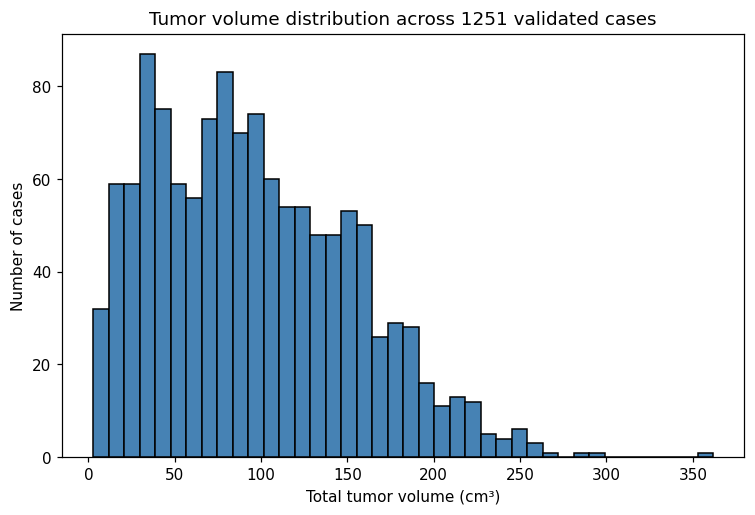

Figure saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/tumor_volume_distribution.png
Per-case label statistics saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/label_stats.csv


In [34]:
# ---------------------------------------------------------------------------
# 5.2b Absent-class counts and tumor-volume distribution plot
# ---------------------------------------------------------------------------
print("Cases where a foreground class has ZERO voxels (relevant to Dice/HD95 "
      "empty-mask edge cases in Stage G):")
ABSENT_CLASS_COUNTS = {}
for cname in FOREGROUND_CLASS_NAMES:
    n_absent = int((LABEL_STATS_DF[f"voxels_{cname}"] == 0).sum())
    ABSENT_CLASS_COUNTS[cname] = n_absent
    print(f"  {cname:5s}: absent in {n_absent} / {len(LABEL_STATS_DF)} cases")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(LABEL_STATS_DF["total_tumor_volume_cm3"], bins=40, color="steelblue", edgecolor="black")
ax.set_xlabel("Total tumor volume (cm\u00b3)")
ax.set_ylabel("Number of cases")
ax.set_title(f"Tumor volume distribution across {len(LABEL_STATS_DF)} validated cases")
fig_path = RUN_DIR / "figures" / "tumor_volume_distribution.png"
fig.savefig(fig_path)
plt.show()
print(f"Figure saved to: {fig_path}")

LABEL_STATS_PATH = RUN_DIR / "label_stats.csv"
LABEL_STATS_DF.to_csv(LABEL_STATS_PATH, index=False)
print(f"Per-case label statistics saved to: {LABEL_STATS_PATH}")

In [35]:
# ---------------------------------------------------------------------------
# 5.3 Intensity fingerprint (seeded sample — CPU-friendly by default)
# ---------------------------------------------------------------------------
FINGERPRINT_SAMPLE_SIZE = min(100, len(VALID_CASES_DF))  # raise this (up to len(VALID_CASES_DF)) if you have time/GPU to spare

rng = np.random.RandomState(CONFIG.seed)
sample_positions = rng.choice(len(VALID_CASES_DF), size=FINGERPRINT_SAMPLE_SIZE, replace=False)
intensity_sample_df = VALID_CASES_DF.iloc[sample_positions].reset_index(drop=True)

print(f"Computing intensity fingerprint on a seeded random sample of "
      f"{FINGERPRINT_SAMPLE_SIZE}/{len(VALID_CASES_DF)} cases. This is a CPU-friendly "
      f"default (loading full float32 volumes is far more expensive than the tiny "
      f"integer seg masks above) — not a hard limit. Raise FINGERPRINT_SAMPLE_SIZE "
      f"above if you have time or a GPU-backed runtime to spare.")

MODALITY_COLUMNS = {"T1": "t1_path", "T1ce": "t1ce_path", "T2": "t2_path", "FLAIR": "flair_path"}


def compute_foreground_intensity_stats(path: str) -> dict:
    """Foreground-only (nonzero) intensity stats for one modality volume.

    BraTS volumes are skull-stripped: exact-zero voxels are background, so a
    nonzero mask is a reasonable proxy for "foreground" at the fingerprinting
    stage (the actual normalization step in Stage C may refine this).
    """
    data = np.asanyarray(nib.load(path).dataobj, dtype=np.float32)
    foreground = data[data != 0.0]
    if foreground.size == 0:
        return {"mean": np.nan, "std": np.nan, "min": np.nan, "max": np.nan, "foreground_fraction": 0.0}
    return {
        "mean": float(foreground.mean()),
        "std": float(foreground.std()),
        "min": float(foreground.min()),
        "max": float(foreground.max()),
        "foreground_fraction": float(foreground.size / data.size),
    }


intensity_rows = []
for _, row in tqdm(intensity_sample_df.iterrows(), total=len(intensity_sample_df),
                    desc="Computing intensity fingerprint (sample)"):
    record = {"case_id": row["case_id"]}
    for mod_name, col in MODALITY_COLUMNS.items():
        for k, v in compute_foreground_intensity_stats(row[col]).items():
            record[f"{mod_name}_{k}"] = v
    intensity_rows.append(record)

INTENSITY_FINGERPRINT_DF = pd.DataFrame(intensity_rows)
INTENSITY_FINGERPRINT_PATH = RUN_DIR / "intensity_fingerprint_sample.csv"
INTENSITY_FINGERPRINT_DF.to_csv(INTENSITY_FINGERPRINT_PATH, index=False)

intensity_stats_summary = {}
print("\nPer-modality foreground intensity summary (mean across sampled cases):")
for mod_name in MODALITY_COLUMNS:
    mean_of_means = float(INTENSITY_FINGERPRINT_DF[f"{mod_name}_mean"].mean())
    mean_of_stds = float(INTENSITY_FINGERPRINT_DF[f"{mod_name}_std"].mean())
    global_min = float(INTENSITY_FINGERPRINT_DF[f"{mod_name}_min"].min())
    global_max = float(INTENSITY_FINGERPRINT_DF[f"{mod_name}_max"].max())
    intensity_stats_summary[mod_name] = {
        "mean_of_case_means": mean_of_means,
        "mean_of_case_stds": mean_of_stds,
        "observed_min": global_min,
        "observed_max": global_max,
    }
    print(f"  {mod_name:6s}: mean(mean)={mean_of_means:10.2f}  mean(std)={mean_of_stds:10.2f}  "
          f"range=[{global_min:.1f}, {global_max:.1f}]")

CONFIG.fingerprint.intensity_stats = intensity_stats_summary
print(f"\nSample-level intensity fingerprint saved to: {INTENSITY_FINGERPRINT_PATH}")

Computing intensity fingerprint on a seeded random sample of 100/1251 cases. This is a CPU-friendly default (loading full float32 volumes is far more expensive than the tiny integer seg masks above) — not a hard limit. Raise FINGERPRINT_SAMPLE_SIZE above if you have time or a GPU-backed runtime to spare.


Computing intensity fingerprint (sample):   0%|          | 0/100 [00:00<?, ?it/s]


Per-modality foreground intensity summary (mean across sampled cases):
  T1    : mean(mean)=    817.54  mean(std)=    218.46  range=[-5.0, 9256.0]
  T1ce  : mean(mean)=   1148.73  mean(std)=    356.87  range=[1.0, 19066.0]
  T2    : mean(mean)=    629.02  mean(std)=    276.74  range=[0.0, 10276.0]
  FLAIR : mean(mean)=    515.00  mean(std)=    180.23  range=[0.0, 5147.0]

Sample-level intensity fingerprint saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/intensity_fingerprint_sample.csv


In [36]:
# ---------------------------------------------------------------------------
# 5.4 Persist fingerprint + updated config
# ---------------------------------------------------------------------------
fingerprint_summary = {
    "n_cases_geometry_checked": len(VALID_CASES_DF),
    "geometrically_uniform": DATASET_IS_GEOMETRICALLY_UNIFORM,
    "target_spacing_mm": CONFIG.fingerprint.target_spacing_mm,
    "resampling_required": CONFIG.fingerprint.resampling_required,
    "tumor_volume_cm3": {
        "mean": float(LABEL_STATS_DF["total_tumor_volume_cm3"].mean()),
        "median": float(LABEL_STATS_DF["total_tumor_volume_cm3"].median()),
        "std": float(LABEL_STATS_DF["total_tumor_volume_cm3"].std()),
        "min": float(LABEL_STATS_DF["total_tumor_volume_cm3"].min()),
        "max": float(LABEL_STATS_DF["total_tumor_volume_cm3"].max()),
    },
    "absent_class_case_counts": ABSENT_CLASS_COUNTS,
    "intensity_fingerprint_sample_size": FINGERPRINT_SAMPLE_SIZE,
    "intensity_stats_per_modality": CONFIG.fingerprint.intensity_stats,
}

FINGERPRINT_PATH = RUN_DIR / "dataset_fingerprint.json"
with open(FINGERPRINT_PATH, "w") as f:
    json.dump(fingerprint_summary, f, indent=2, default=str)
LOGGER.info(f"Dataset fingerprint saved to {FINGERPRINT_PATH}")

# CONFIG.fingerprint fields were updated in-place above — re-save config.json
# so it stays the single source of truth (per the PRD's dataset_fingerprint.yaml pattern).
save_config(CONFIG, CONFIG_PATH)
print(f"Fingerprint saved to: {FINGERPRINT_PATH}")
print(f"Config re-saved (fingerprint fields updated) to: {CONFIG_PATH}")

2026-09-16 00:31:25 | INFO     | brats_notebook | Dataset fingerprint saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/dataset_fingerprint.json
2026-09-16 00:31:25 | INFO     | brats_notebook | Config saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json
Fingerprint saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/dataset_fingerprint.json
Config re-saved (fingerprint fields updated) to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json


In [37]:
# ---------------------------------------------------------------------------
# 5.5 Validation
# ---------------------------------------------------------------------------
checks_5 = {
    "Geometry fingerprint computed": len(shape_counts) > 0 and len(spacing_counts) > 0,
    "Resampling decision recorded (not None)": CONFIG.fingerprint.resampling_required is not None,
    "Target spacing recorded (not None)": CONFIG.fingerprint.target_spacing_mm is not None,
    "Label/tumor statistics computed for all validated cases": len(LABEL_STATS_DF) == len(VALID_CASES_DF),
    "Intensity fingerprint computed for the sample": len(INTENSITY_FINGERPRINT_DF) == FINGERPRINT_SAMPLE_SIZE,
    "Fingerprint file persisted to disk": FINGERPRINT_PATH.exists(),
}
print("=" * 70)
print("SECTION 5 VALIDATION SUMMARY")
print("=" * 70)
for name, passed in checks_5.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_5.values()), "One or more Section 5 checks failed — see above."
print("=" * 70)

SECTION 5 VALIDATION SUMMARY
[PASS] Geometry fingerprint computed
[PASS] Resampling decision recorded (not None)
[PASS] Target spacing recorded (not None)
[PASS] Label/tumor statistics computed for all validated cases
[PASS] Intensity fingerprint computed for the sample
[PASS] Fingerprint file persisted to disk


In [ ]:
## Section 6 — Visual Exploration

Picks representative cases **from the tumor-volume distribution** computed
in Section 5 (small / median / large), not randomly — and within each case,
displays the **axial slice with the largest tumor cross-section** rather
than a randomly chosen slice.

For each representative case: T1, T1ce, T2, FLAIR, the segmentation mask,
and FLAIR/T1ce overlays, all using one fixed color legend
(`CLASS_COLORS`, keyed by the internal `{0,1,2,3}` label IDs) that will be
reused later in Stage H's qualitative results section.

A best-effort 3D surface render of the largest-tumor case's mask is
attempted via `skimage.measure.marching_cubes` — wrapped so a failure here
(e.g. a degenerate mask) doesn't stop the notebook.

**A visualization note on slice axis:** these plots slice along the volume's
third array axis (`volume[:, :, z]`) as "axial," which matches the standard
BraTS convention — but this is a display convenience only. Rigorous
orientation canonicalization (via each case's affine) belongs to Stage C's
preprocessing step, not here.

**Expected result:** three multi-panel figures (one per representative
case) plus one 3D mesh render, all saved under `figures/`.

**Validation:** three distinct representative cases selected, spanning a
real range of tumor volumes; every 2D figure generated without error.

In [38]:
# ---------------------------------------------------------------------------
# 6.1 Shared color legend + overlay helper
# ---------------------------------------------------------------------------
# Internal contiguous IDs -> RGBA (background transparent)
CLASS_COLORS = {
    0: (0.0, 0.0, 0.0, 0.0),   # background - transparent
    1: (0.90, 0.10, 0.10, 0.55),  # NCR - red
    2: (0.95, 0.85, 0.10, 0.45),  # ED  - yellow
    3: (0.10, 0.45, 0.95, 0.60),  # ET  - blue
}


def load_internal_label_slice(seg_path: str, z: int) -> np.ndarray:
    """Load one axial slice of a seg volume, remapped to internal {0,1,2,3} IDs."""
    seg_data = np.asanyarray(nib.load(seg_path).dataobj).astype(np.uint8)
    slice_raw = seg_data[:, :, z]
    slice_internal = np.zeros_like(slice_raw)
    for raw, internal in LABEL_MAP_RAW_TO_INTERNAL.items():
        slice_internal[slice_raw == raw] = internal
    return slice_internal


def seg_slice_to_rgba(slice_internal: np.ndarray) -> np.ndarray:
    """Render an internal-ID label slice as an RGBA overlay image."""
    rgba = np.zeros((*slice_internal.shape, 4), dtype=np.float32)
    for internal_id, color in CLASS_COLORS.items():
        rgba[slice_internal == internal_id] = color
    return rgba


def find_max_tumor_slice(seg_path: str) -> int:
    """Return the z-index (third array axis) with the largest foreground area."""
    seg_data = np.asanyarray(nib.load(seg_path).dataobj)
    foreground_per_slice = (seg_data != 0).sum(axis=(0, 1))
    return int(np.argmax(foreground_per_slice))


print("Color legend (internal ID -> class -> RGBA):")
for internal_id, color in CLASS_COLORS.items():
    print(f"  {internal_id} ({CLASS_NAMES[internal_id]:10s}): {color}")

Color legend (internal ID -> class -> RGBA):
  0 (background): (0.0, 0.0, 0.0, 0.0)
  1 (NCR       ): (0.9, 0.1, 0.1, 0.55)
  2 (ED        ): (0.95, 0.85, 0.1, 0.45)
  3 (ET        ): (0.1, 0.45, 0.95, 0.6)


In [39]:
# ---------------------------------------------------------------------------
# 6.2 Select representative cases from the tumor-volume distribution
# ---------------------------------------------------------------------------
volume_sorted = LABEL_STATS_DF.sort_values("total_tumor_volume_cm3").reset_index(drop=True)
n = len(volume_sorted)

representative_rows = {
    "small":  volume_sorted.iloc[max(int(n * 0.10) - 1, 0)],
    "median": volume_sorted.iloc[n // 2],
    "large":  volume_sorted.iloc[min(int(n * 0.90), n - 1)],
}

REPRESENTATIVE_CASES = {}
for tag, stats_row in representative_rows.items():
    case_row = VALID_CASES_DF.loc[VALID_CASES_DF["case_id"] == stats_row["case_id"]].iloc[0]
    REPRESENTATIVE_CASES[tag] = case_row
    print(f"{tag:7s} tumor case: {case_row['case_id']}  "
          f"(total tumor volume = {stats_row['total_tumor_volume_cm3']:.2f} cm\u00b3)")

assert len({c["case_id"] for c in REPRESENTATIVE_CASES.values()}) >= 2, (
    "Representative cases collapsed onto too few unique cases — check dataset size."
)

small   tumor case: BraTS2021_01257  (total tumor volume = 24.95 cm³)
median  tumor case: BraTS2021_00383  (total tumor volume = 89.33 cm³)
large   tumor case: BraTS2021_00468  (total tumor volume = 174.31 cm³)


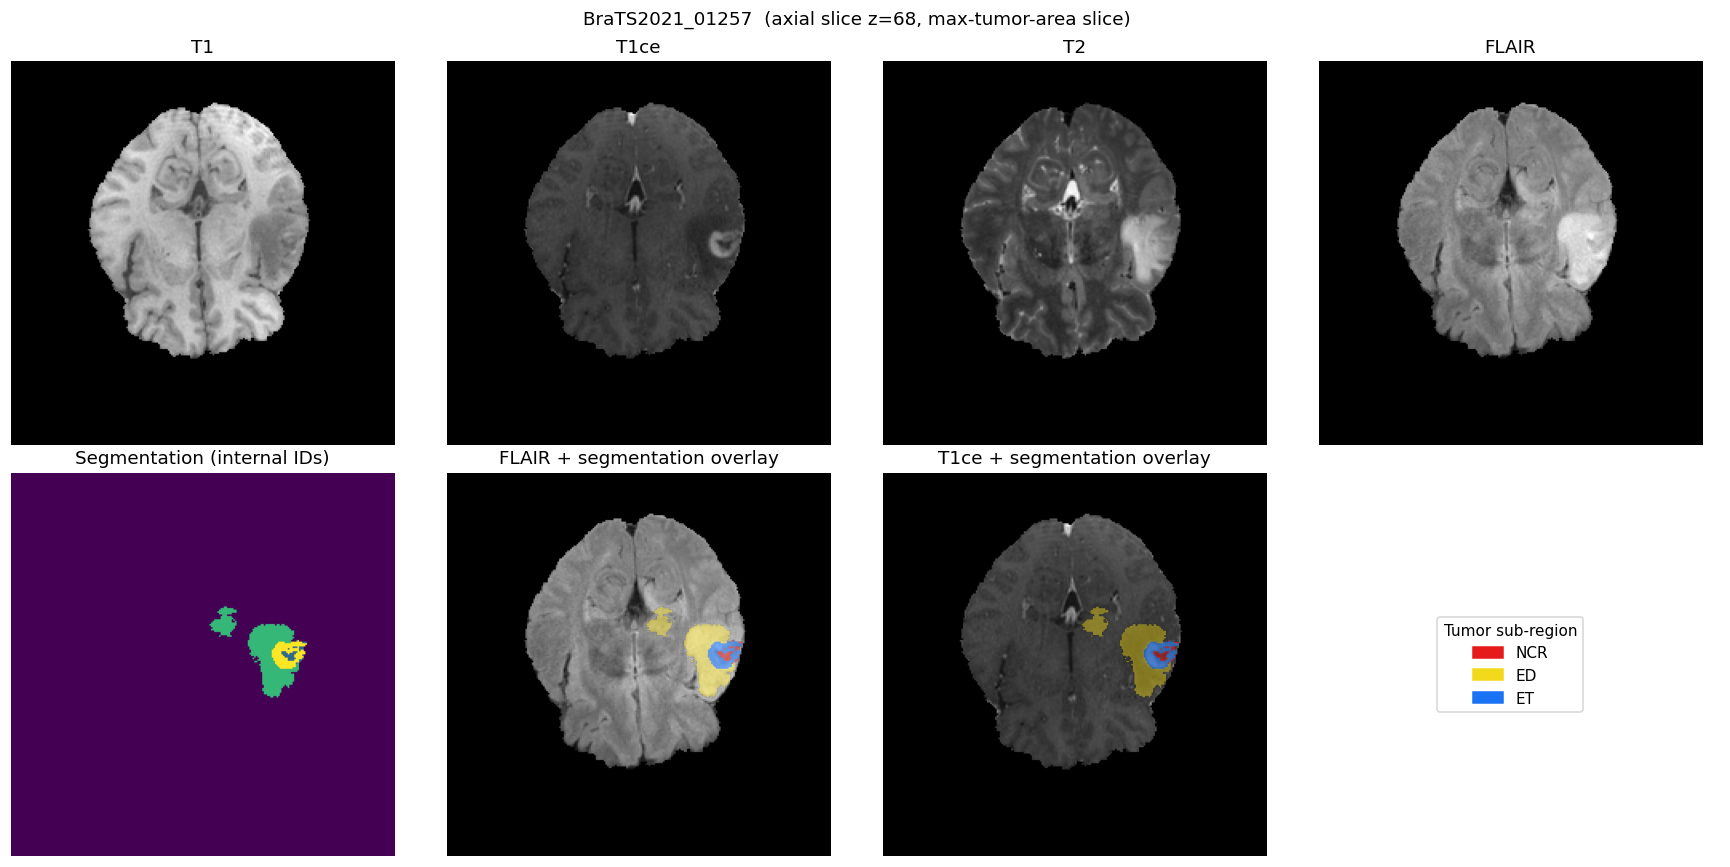

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/overview_small_BraTS2021_01257.png


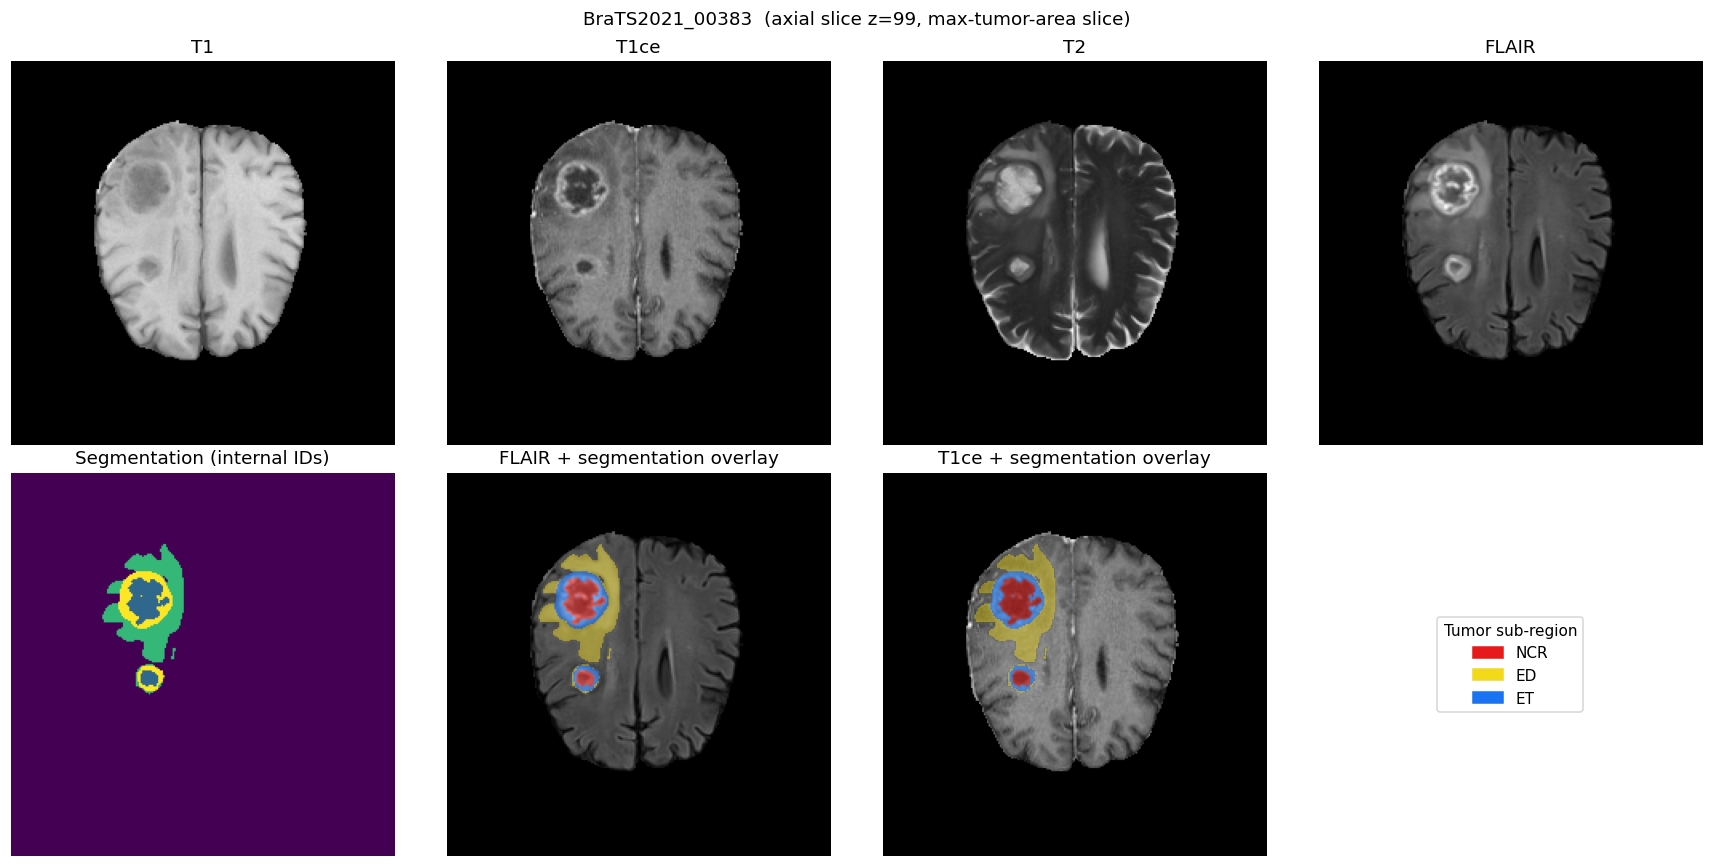

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/overview_median_BraTS2021_00383.png


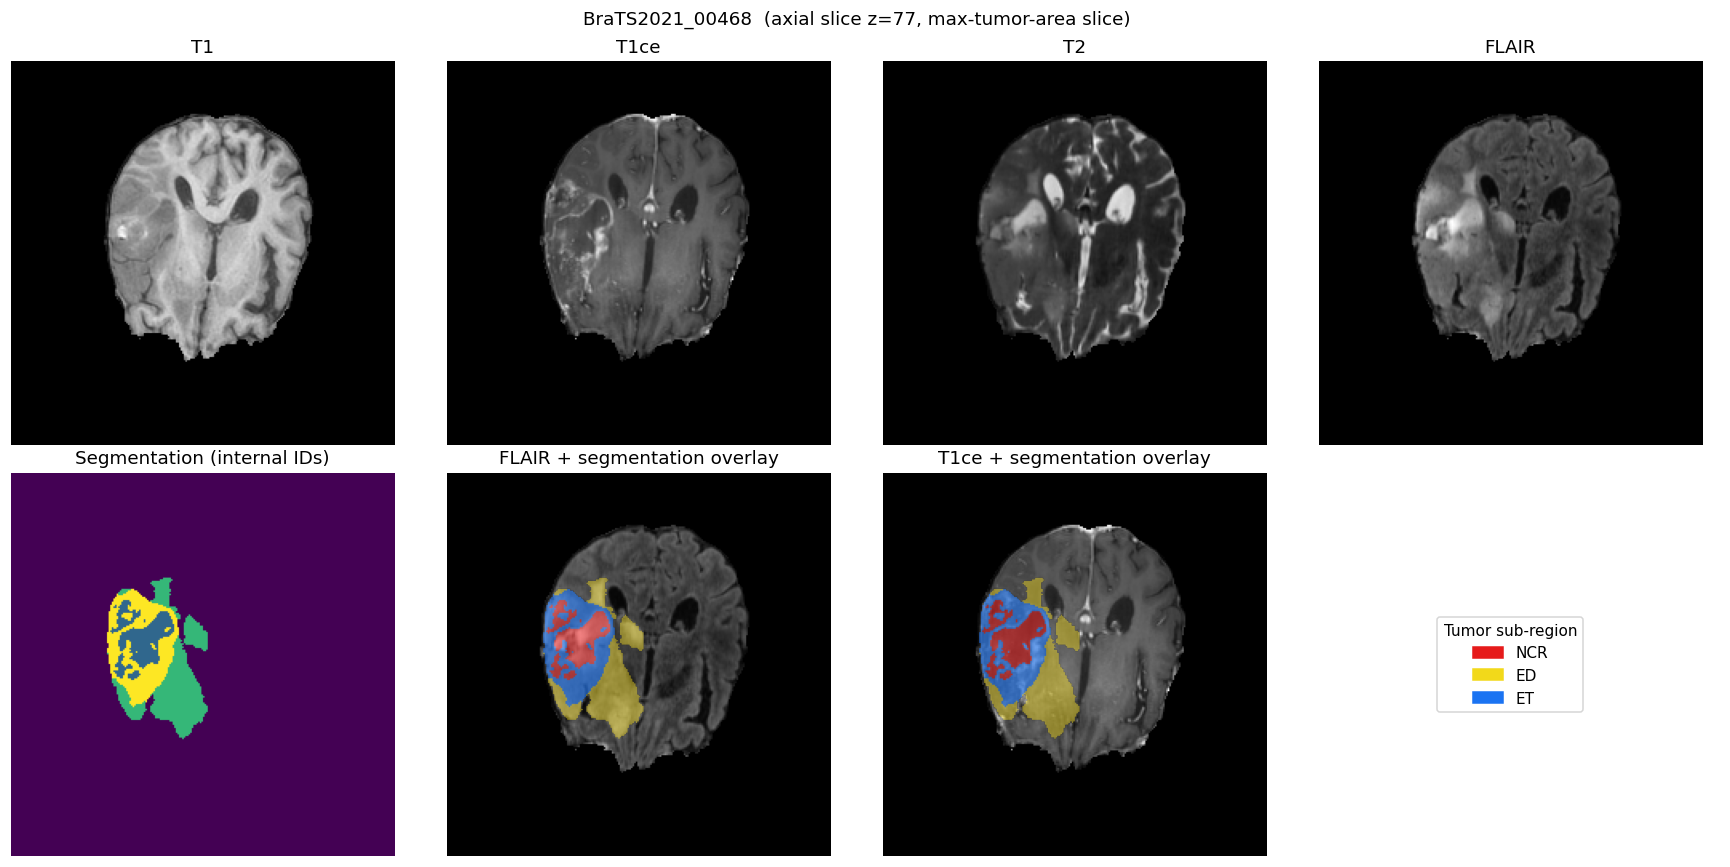

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/overview_large_BraTS2021_00468.png


In [40]:
# ---------------------------------------------------------------------------
# 6.3 Multi-panel figure per representative case
# ---------------------------------------------------------------------------
def plot_case_overview(case_row: pd.Series, save_path: Path) -> None:
    z = find_max_tumor_slice(case_row["seg_path"])
    seg_slice_internal = load_internal_label_slice(case_row["seg_path"], z)
    seg_rgba = seg_slice_to_rgba(seg_slice_internal)

    modality_paths = {
        "T1": case_row["t1_path"],
        "T1ce": case_row["t1ce_path"],
        "T2": case_row["t2_path"],
        "FLAIR": case_row["flair_path"],
    }
    modality_slices = {
        name: np.asanyarray(nib.load(p).dataobj)[:, :, z]
        for name, p in modality_paths.items()
    }

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f"{case_row['case_id']}  (axial slice z={z}, max-tumor-area slice)")

    for ax, (name, sl) in zip(axes[0], modality_slices.items()):
        ax.imshow(sl.T, cmap="gray", origin="lower")
        ax.set_title(name)
        ax.axis("off")

    axes[1, 0].imshow(seg_slice_internal.T, cmap="viridis", origin="lower", vmin=0, vmax=3)
    axes[1, 0].set_title("Segmentation (internal IDs)")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(modality_slices["FLAIR"].T, cmap="gray", origin="lower")
    axes[1, 1].imshow(seg_rgba.transpose(1, 0, 2), origin="lower")
    axes[1, 1].set_title("FLAIR + segmentation overlay")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(modality_slices["T1ce"].T, cmap="gray", origin="lower")
    axes[1, 2].imshow(seg_rgba.transpose(1, 0, 2), origin="lower")
    axes[1, 2].set_title("T1ce + segmentation overlay")
    axes[1, 2].axis("off")

    axes[1, 3].axis("off")
    legend_patches = [
        matplotlib.patches.Patch(color=CLASS_COLORS[i][:3], label=CLASS_NAMES[i])
        for i in range(1, 4)
    ]
    axes[1, 3].legend(handles=legend_patches, loc="center", title="Tumor sub-region")

    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()
    print(f"Saved: {save_path}")


import matplotlib.patches  # noqa: E402  (used only for the legend above)

for tag, case_row in REPRESENTATIVE_CASES.items():
    out_path = RUN_DIR / "figures" / f"overview_{tag}_{case_row['case_id']}.png"
    plot_case_overview(case_row, out_path)

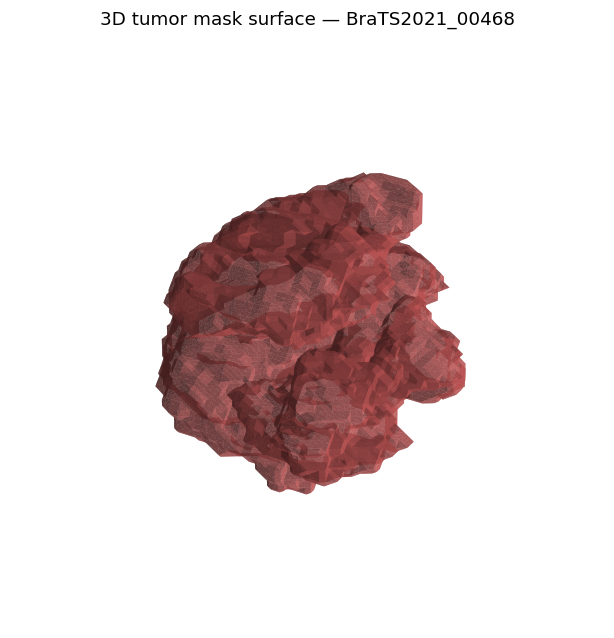

3D mesh saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/mesh3d_BraTS2021_00468.png (11705 vertices, 23474 faces)


In [41]:
# ---------------------------------------------------------------------------
# 6.4 Best-effort 3D mesh of the largest-tumor case
# ---------------------------------------------------------------------------
mesh_render_succeeded = False
if skimage_measure is not None:
    try:
        large_case = REPRESENTATIVE_CASES["large"]
        seg_data = np.asanyarray(nib.load(large_case["seg_path"]).dataobj)
        binary_tumor_mask = (seg_data != 0).astype(np.uint8)

        verts, faces, _, _ = skimage_measure.marching_cubes(binary_tumor_mask, level=0.5, step_size=2)

        from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111, projection="3d")
        ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                         color="indianred", alpha=0.7, linewidth=0)
        ax.set_title(f"3D tumor mask surface — {large_case['case_id']}")
        ax.set_axis_off()
        mesh_path = RUN_DIR / "figures" / f"mesh3d_{large_case['case_id']}.png"
        fig.savefig(mesh_path)
        plt.show()
        print(f"3D mesh saved to: {mesh_path} ({len(verts)} vertices, {len(faces)} faces)")
        mesh_render_succeeded = True
    except Exception as e:  # best-effort per the master prompt; surfaced, not swallowed
        print(f"3D mesh render skipped (non-fatal): {e}")
else:
    print("scikit-image not installed — skipping 3D mesh render (optional dependency).")

In [42]:
# ---------------------------------------------------------------------------
# 6.5 Validation
# ---------------------------------------------------------------------------
checks_6 = {
    "At least 2 distinct representative cases selected": len({c['case_id'] for c in REPRESENTATIVE_CASES.values()}) >= 2,
    "Overview figures saved for every representative case": all(
        (RUN_DIR / "figures" / f"overview_{tag}_{row['case_id']}.png").exists()
        for tag, row in REPRESENTATIVE_CASES.items()
    ),
}
print("=" * 70)
print("SECTION 6 VALIDATION SUMMARY")
print("=" * 70)
for name, passed in checks_6.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
print(f"[{'PASS' if mesh_render_succeeded else 'SKIPPED'}] 3D mesh render (best-effort, non-blocking)")
assert all(checks_6.values()), "One or more Section 6 checks failed — see above."
print("=" * 70)

SECTION 6 VALIDATION SUMMARY
[PASS] At least 2 distinct representative cases selected
[PASS] Overview figures saved for every representative case
[PASS] 3D mesh render (best-effort, non-blocking)


In [ ]:
Section 7 — Train / Validation Split
A correction to Stage A's default worth flagging explicitly: Stage A's CONFIG.split.split_dir defaulted to the per-run, timestamped RUN_DIR. A split saved there would not actually be reusable across runs — each new Stage A execution creates a fresh RUN_DIR, so a later run could never find it and would silently regenerate a different split. This section introduces a stable, non-timestamped splits/ directory as the split's real home, and updates CONFIG.split.split_dir to point there. RUN_DIR still gets a copy for this run's own provenance record.

Split logic: patient-level, fixed-seed, 80/20 by default (CONFIG.split.train_fraction / val_fraction — the PRD does not override this ratio, so the master prompt's default stands). If splits/train_cases.csv and splits/val_cases.csv already exist, they are loaded and checked for consistency against the current VALID_CASES_DF rather than silently regenerated.

Expected result: train_cases.csv / val_cases.csv in splits/, printed counts, and a set(train_ids).isdisjoint(set(val_ids)) assertion.

Validation: disjoint sets, full coverage of VALID_CASES_DF, and a sanity comparison of mean tumor volume between the two splits (a large imbalance here would be worth a second look before Stage C).

In [43]:
# ---------------------------------------------------------------------------
# 7.1 Stable, reusable split directory
# ---------------------------------------------------------------------------
# The train/validation split must survive Kaggle session restarts.
# Keep ONE canonical split under /kaggle/working and reuse it across experiments.

SPLIT_DIR = KAGGLE_PROJECT_ROOT / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG.split.split_dir = str(SPLIT_DIR)

TRAIN_SPLIT_PATH = SPLIT_DIR / "train_cases.csv"
VAL_SPLIT_PATH = SPLIT_DIR / "val_cases.csv"

assert str(SPLIT_DIR).startswith("/kaggle/working/"), (
    f"SPLIT_DIR is not under /kaggle/working: {SPLIT_DIR}"
)

print(f"Canonical, reusable split directory: {SPLIT_DIR}")
print(f"Train split path: {TRAIN_SPLIT_PATH}")
print(f"Val split path  : {VAL_SPLIT_PATH}")

# ---------------------------------------------------------------------------
# 7.2 Load-or-create patient-level split
# ---------------------------------------------------------------------------

def create_patient_level_split(
    case_ids: list,
    train_fraction: float,
    seed: int,
):
    rng = np.random.RandomState(seed)

    # Sort first so reproducibility does not depend on DataFrame ordering.
    shuffled = np.array(sorted(case_ids))

    rng.shuffle(shuffled)

    n_train = int(round(len(shuffled) * train_fraction))

    train_ids = sorted(shuffled[:n_train].tolist())
    val_ids = sorted(shuffled[n_train:].tolist())

    return train_ids, val_ids


# ---------------------------------------------------------------------------
# Load the canonical split if it already exists; otherwise create it.
# ---------------------------------------------------------------------------

if TRAIN_SPLIT_PATH.exists() and VAL_SPLIT_PATH.exists():

    print("Loading existing canonical train/validation split from /kaggle/working...")

    train_split_df = pd.read_csv(TRAIN_SPLIT_PATH)
    val_split_df = pd.read_csv(VAL_SPLIT_PATH)

    assert "case_id" in train_split_df.columns, \
        "train_cases.csv must contain a 'case_id' column."

    assert "case_id" in val_split_df.columns, \
        "val_cases.csv must contain a 'case_id' column."

    train_ids = sorted(train_split_df["case_id"].astype(str).tolist())
    val_ids = sorted(val_split_df["case_id"].astype(str).tolist())

else:

    print("No canonical split found — creating a new patient-level split...")

    all_case_ids = sorted(
        VALID_CASES_DF["case_id"].astype(str).tolist()
    )

    train_ids, val_ids = create_patient_level_split(
        all_case_ids,
        CONFIG.split.train_fraction,
        CONFIG.split.seed,
    )

    # Save the canonical split under /kaggle/working.
    pd.DataFrame({"case_id": train_ids}).to_csv(
        TRAIN_SPLIT_PATH,
        index=False
    )

    pd.DataFrame({"case_id": val_ids}).to_csv(
        VAL_SPLIT_PATH,
        index=False
    )

    print("New canonical split saved under /kaggle/working.")


# ---------------------------------------------------------------------------
# Validate the loaded/created split against the current validated dataset.
# ---------------------------------------------------------------------------

all_case_ids = set(
    VALID_CASES_DF["case_id"].astype(str).tolist()
)

assert set(train_ids).isdisjoint(set(val_ids)), \
    "Train/validation case_id sets overlap — patient leakage."

assert set(train_ids) | set(val_ids) == all_case_ids, \
    "Train/validation split does not cover the full validated dataset."

assert set(train_ids) <= all_case_ids, \
    "Train split contains case IDs not present in the validated dataset."

assert set(val_ids) <= all_case_ids, \
    "Validation split contains case IDs not present in the validated dataset."

print("=" * 70)
print("PATIENT-LEVEL SPLIT READY")
print("=" * 70)
print(f"Train cases : {len(train_ids)}")
print(f"Val cases   : {len(val_ids)}")
print(f"Train split : {TRAIN_SPLIT_PATH}")
print(f"Val split   : {VAL_SPLIT_PATH}")
print("=" * 70)

Canonical, reusable split directory: /kaggle/working/BraTS2021_3D_UNet/splits
Train split path: /kaggle/working/BraTS2021_3D_UNet/splits/train_cases.csv
Val split path  : /kaggle/working/BraTS2021_3D_UNet/splits/val_cases.csv
Loading existing canonical train/validation split from /kaggle/working...
PATIENT-LEVEL SPLIT READY
Train cases : 1001
Val cases   : 250
Train split : /kaggle/working/BraTS2021_3D_UNet/splits/train_cases.csv
Val split   : /kaggle/working/BraTS2021_3D_UNet/splits/val_cases.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [44]:
# ---------------------------------------------------------------------------
# 7.3 Report + disjointness assertion
# ---------------------------------------------------------------------------
print("=" * 70)
print("TRAIN / VALIDATION SPLIT SUMMARY")
print("=" * 70)
print(f"Train cases : {len(train_ids)}")
print(f"Val cases   : {len(val_ids)}")
print(f"Train case_id sample : {train_ids[:5]}")
print(f"Val case_id sample   : {val_ids[:5]}")

assert set(train_ids).isdisjoint(set(val_ids)), "Train/validation case_id sets overlap — patient leakage."
print("\nset(train_ids).isdisjoint(set(val_ids)) -> True")
print("=" * 70)

# Also drop a copy into this run's own directory for provenance
RUN_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"case_id": train_ids}).to_csv(
    RUN_DIR / "train_cases.csv",
    index=False
)

pd.DataFrame({"case_id": val_ids}).to_csv(
    RUN_DIR / "val_cases.csv",
    index=False
)

print("\nProvenance copies saved:")
print(f"  Train: {RUN_DIR / 'train_cases.csv'}")
print(f"  Val  : {RUN_DIR / 'val_cases.csv'}")

TRAIN / VALIDATION SPLIT SUMMARY
Train cases : 1001
Val cases   : 250
Train case_id sample : ['BraTS2021_00000', 'BraTS2021_00003', 'BraTS2021_00005', 'BraTS2021_00006', 'BraTS2021_00008']
Val case_id sample   : ['BraTS2021_00002', 'BraTS2021_00012', 'BraTS2021_00019', 'BraTS2021_00020', 'BraTS2021_00028']

set(train_ids).isdisjoint(set(val_ids)) -> True

Provenance copies saved:
  Train: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/train_cases.csv
  Val  : /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/val_cases.csv


In [45]:
# ---------------------------------------------------------------------------
# 7.4 Sanity check: tumor-volume balance between splits
# ---------------------------------------------------------------------------
train_volumes = LABEL_STATS_DF.loc[LABEL_STATS_DF["case_id"].isin(train_ids), "total_tumor_volume_cm3"]
val_volumes = LABEL_STATS_DF.loc[LABEL_STATS_DF["case_id"].isin(val_ids), "total_tumor_volume_cm3"]

print("Tumor volume (cm\u00b3) — train vs. validation split:")
print(f"  train: mean={train_volumes.mean():.2f}  median={train_volumes.median():.2f}  n={len(train_volumes)}")
print(f"  val  : mean={val_volumes.mean():.2f}  median={val_volumes.median():.2f}  n={len(val_volumes)}")
relative_mean_diff = abs(train_volumes.mean() - val_volumes.mean()) / train_volumes.mean()
print(f"  relative difference in means: {relative_mean_diff:.1%}")
if relative_mean_diff > 0.25:
    print("  NOTE: this is a noticeably large split imbalance in tumor volume — "
          "consider a stratified re-split if this matters for your evaluation.")

Tumor volume (cm³) — train vs. validation split:
  train: mean=94.51  median=89.33  n=1001
  val  : mean=101.79  median=89.39  n=250
  relative difference in means: 7.7%


In [46]:
# ---------------------------------------------------------------------------
# 7.5 Validation
# ---------------------------------------------------------------------------
checks_7 = {
    "Split files exist in the stable splits/ directory": TRAIN_SPLIT_PATH.exists() and VAL_SPLIT_PATH.exists(),
    "Train/val sets are disjoint": set(train_ids).isdisjoint(set(val_ids)),
    "Split covers the full validated dataset": set(train_ids) | set(val_ids) == all_case_ids,
    "Provenance copies written to this run's directory": (RUN_DIR / "train_cases.csv").exists() and (RUN_DIR / "val_cases.csv").exists(),
}
print("=" * 70)
print("SECTION 7 VALIDATION SUMMARY")
print("=" * 70)
for name, passed in checks_7.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_7.values()), "One or more Section 7 checks failed — see above."
print("=" * 70)
print("STAGE B COMPLETE.")

SECTION 7 VALIDATION SUMMARY
[PASS] Split files exist in the stable splits/ directory
[PASS] Train/val sets are disjoint
[PASS] Split covers the full validated dataset
[PASS] Provenance copies written to this run's directory
STAGE B COMPLETE.


In [ ]:
Before moving to Stage C
Stage C adds preprocessing (foreground-only z-score normalization), patch-based sampling with foreground oversampling, and augmentation (Phases 6-8). Before that, please confirm:

Resampling decision (Section 5.1) — was your dataset geometrically uniform? Given BraTS 2021's public release, I'd expect "yes, no resampling needed," but Stage C will branch on whatever your actual printed verdict was, not on that expectation.
Tumor volume / absent-class counts (Section 5.2b) — worth a glance; these numbers directly inform the foreground-oversampling fraction and later Dice/HD95 edge-case handling.
Intensity fingerprint (Section 5.3) — if you have GPU time to spare, consider re-running with FINGERPRINT_SAMPLE_SIZE raised toward 1251 for a more precise normalization basis; not required to proceed.
Split balance (Section 7.4) — flag it if the relative tumor-volume difference between train/val looked large.
GPU runtime — Stage C's patch-size selection and Stage F's training both need one; if you haven't already, enable a GPU accelerator in Kaggle's notebook Settings panel before continuing much further.
Let me know how these looked and I'll build Stage C.

In [ ]:
Continuing to Stage C — Preprocessing, Patch Sampling, Augmentation, and the Dataset/DataLoader (Sections 8–11). Stage B's results look clean to build on: geometrically uniform dataset (no resampling needed), 1251/1251 valid cases, patient-level 80/20 split with only a 7.7% tumor-volume mean difference between splits.

Stage C — Assumptions / Decisions (flagging before implementing, per the master prompt's rules):

Orientation is verified across the whole dataset in 8.1, not assumed — the sagittal axis used for flip augmentation (10.1) is derived programmatically from that result, never hardcoded as "axis 0."
Normalization is per-case, not global. MRI intensities are arbitrary, scanner-dependent units (unlike CT's calibrated Hounsfield units), so nnU-Net-style per-volume foreground z-score is correct here — and it also means normalization statistics never cross the train/val boundary, so there's no leakage vector to guard against in the first place.
Foreground-bbox cropping is an engineering addition beyond the letter of the PRD (not a resampling requirement — geometry is already uniform). It cuts wasted patch draws on empty skull-stripped background and speeds up CPU-bound iteration. Applied identically to image and seg with a safety margin.
Patch size auto-selection thresholds (9.1) are an estimate, not a measurement — they'll get corrected empirically once Stage D's dummy forward pass can actually watch torch.cuda.max_memory_allocated(). Current environment is still CPU-only (0 GB free VRAM per Stage A), so this will select the smallest candidate and print a hard warning, same as Stage A/B already flagged.
Augmentation apply-probabilities are not specified by the PRD (it names which augmentations, not how often). I'm using nnU-Net-informed defaults, stated explicitly in AugConfig rather than picked silently.
Preprocessing cache directory lives outside RUN_DIR (preprocessed_cache/, sibling to splits/) — applying the same lesson Stage B had to retroactively fix for split_dir (a timestamped run folder is unreusable across runs) proactively this time.

I ran the core preprocessing/sampling/augmentation logic below against synthetic arrays in a sandbox first (not your real BraTS data — that isn't available to me) specifically to catch shape/dtype/interpolation bugs before handing it to you: foreground normalization lands at mean≈0/std≈1 on the foreground only, foreground-oversampled patch anchoring hit its target rate (0.673 observed vs. 0.66 configured) over 2000 draws, and — the one I was most careful about — a synthetic single-voxel landmark run through the same random affine on both the image and the seg channel landed at the identical output voxel in both, confirming the joint spatial transform doesn't let image and mask diverge.

Section 8 — Preprocessing

Foreground-only per-modality z-score normalization (computed per case, never globally — see Assumption 2), plus a foreground-bounding-box crop (Assumption 3). Both are validated against RAW_LABELS/label-set invariants before anything downstream touches them.

Expected result: an orientation-uniformity verdict for the whole dataset, a PreprocessingConfig persisted into CONFIG, and a demonstration of the preprocessing function on the three representative cases from Stage B.

Validation: orientation check completes for all validated cases; normalized foreground mean/std are within tolerance of (0, 1) on the demo cases; cropped shape is smaller than the original on every demo case; label set after remapping is exactly {0,1,2,3}.

In [47]:
# ---------------------------------------------------------------------------
# 8.0 Continuity check
# ---------------------------------------------------------------------------
_REQUIRED_STAGE_B_VARS = [
    "CONFIG", "DEVICE", "LOGGER", "RUN_DIR", "DATA_ROOT", "VALID_CASES_DF",
    "RAW_LABELS", "CLASS_NAMES", "FOREGROUND_CLASS_NAMES",
    "LABEL_MAP_RAW_TO_INTERNAL", "LABEL_MAP_INTERNAL_TO_RAW",
    "CLASS_COLORS", "REPRESENTATIVE_CASES", "SPLIT_DIR", "train_ids", "val_ids",
    "LABEL_STATS_DF", "GLOBAL_SEED", "CUDA_AVAILABLE", "FREE_VRAM_GB",
]
_missing = [v for v in _REQUIRED_STAGE_B_VARS if v not in globals()]
if _missing:
    raise RuntimeError(
        "Stage C requires Stage A and Stage B's cells to have already run in this "
        f"kernel session. Missing: {_missing}. Re-run Stages A and B from the top first."
    )
print(f"Continuity check passed. {len(train_ids)} train / {len(val_ids)} val cases available.")

Continuity check passed. 1001 train / 250 val cases available.


In [48]:
# ---------------------------------------------------------------------------
# 8.1 Whole-dataset orientation fingerprint
# ---------------------------------------------------------------------------
# Reads only the affine header (cheap — same cost class as the shape/spacing reads
# already done in Section 3), from ONE modality per case (t1). Stage A's discovery
# already confirmed affine consistency ACROSS modalities within each case, so a single
# modality is a valid representative of that case's orientation.
def get_case_orientation(t1_path: str) -> tuple:
    return nib.aff2axcodes(nib.load(t1_path).affine)


orientation_counts = Counter(
    get_case_orientation(row["t1_path"])
    for _, row in tqdm(VALID_CASES_DF.iterrows(), total=len(VALID_CASES_DF), desc="Checking orientation")
)

print(f"Distinct orientations across {len(VALID_CASES_DF)} validated cases: {len(orientation_counts)}")
for axcodes, count in orientation_counts.most_common():
    print(f"  {axcodes}: {count} cases")

ORIENTATION_UNIFORM = len(orientation_counts) == 1
CANONICAL_AXCODES = next(iter(orientation_counts)) if ORIENTATION_UNIFORM else None

if ORIENTATION_UNIFORM:
    print(f"\nEvery validated case shares orientation {CANONICAL_AXCODES}. "
          f"No per-case reorientation is required — measured, not assumed from general "
          f"BraTS knowledge (same standard as Stage B's geometry fingerprint).")
else:
    print(f"\nWARNING: orientation is NOT uniform across the dataset. Per-case "
          f"canonicalization (nib.as_closest_canonical) will be applied inside the loader "
          f"below before normalization/cropping — this is slower and means the sagittal "
          f"flip axis (Section 10.1) must be re-verified per case rather than fixed once.")


Checking orientation:   0%|          | 0/1251 [00:00<?, ?it/s]

Distinct orientations across 1251 validated cases: 1
  ('L', 'P', 'S'): 1251 cases

Every validated case shares orientation ('L', 'P', 'S'). No per-case reorientation is required — measured, not assumed from general BraTS knowledge (same standard as Stage B's geometry fingerprint).


In [49]:
# ---------------------------------------------------------------------------
# 8.2 Extend CONFIG with a PreprocessingConfig
# ---------------------------------------------------------------------------
# Python dataclasses can't gain a new field on an ALREADY-CONSTRUCTED instance, so rather
# than bolt `preprocessing` onto CONFIG as an undeclared attribute (which asdict() would
# silently drop from config.json — exactly the kind of silent failure this notebook
# avoids elsewhere), ExperimentConfig is redefined to include it, and CONFIG is rebuilt
# from its CURRENT sub-configs so nothing measured in Stage A/B (split dir, fingerprint
# stats, etc.) is lost.
@dataclass
class PreprocessingConfig:
    normalize_mode: str = "foreground_zscore_per_case"  # never global-dataset stats — see Assumption 2
    background_value: float = 0.0
    crop_to_foreground: bool = True
    crop_margin_voxels: int = 4
    canonical_orientation: Optional[Tuple[str, str, str]] = None
    orientation_uniform_across_dataset: Optional[bool] = None
    sagittal_axis_index: Optional[int] = None  # filled in Section 10.1


@dataclass
class ExperimentConfig:
    paths: PathConfig = field(default_factory=PathConfig)
    split: SplitConfig = field(default_factory=SplitConfig)
    fingerprint: FingerprintConfig = field(default_factory=FingerprintConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    patch: PatchConfig = field(default_factory=PatchConfig)
    aug: AugConfig = field(default_factory=AugConfig)
    train: TrainConfig = field(default_factory=TrainConfig)
    preprocessing: PreprocessingConfig = field(default_factory=PreprocessingConfig)
    seed: int = GLOBAL_SEED
    dataset_version: str = "brats-2021-task1"
    trained_on_split: str = "official_train"


CONFIG = ExperimentConfig(
    paths=CONFIG.paths, split=CONFIG.split, fingerprint=CONFIG.fingerprint,
    model=CONFIG.model, patch=CONFIG.patch, aug=CONFIG.aug, train=CONFIG.train,
    preprocessing=PreprocessingConfig(
        canonical_orientation=CANONICAL_AXCODES,
        orientation_uniform_across_dataset=ORIENTATION_UNIFORM,
    ),
    seed=CONFIG.seed, dataset_version=CONFIG.dataset_version, trained_on_split=CONFIG.trained_on_split,
)
print("CONFIG extended with `preprocessing` field:")
print(json.dumps(asdict(CONFIG.preprocessing), indent=2, default=str))

CONFIG extended with `preprocessing` field:
{
  "normalize_mode": "foreground_zscore_per_case",
  "background_value": 0.0,
  "crop_to_foreground": true,
  "crop_margin_voxels": 4,
  "canonical_orientation": [
    "L",
    "P",
    "S"
  ],
  "orientation_uniform_across_dataset": true,
  "sagittal_axis_index": null
}


In [50]:
# ---------------------------------------------------------------------------
# 8.3 Core preprocessing functions
# ---------------------------------------------------------------------------
def foreground_zscore_normalize(volume: np.ndarray, background_value: float = 0.0, eps: float = 1e-8):
    """Per-volume foreground-only z-score. Background voxels stay exactly at 0 in the
    normalized output — they are never shifted, since 0 remains the correct 'no signal'
    sentinel throughout the rest of the pipeline (cropping, patch padding)."""
    fg_mask = volume != background_value
    if not fg_mask.any():
        return np.zeros_like(volume, dtype=np.float32), 0.0, 1.0
    fg = volume[fg_mask]
    mean = float(fg.mean())
    std = max(float(fg.std()), eps)
    normalized = volume.astype(np.float32).copy()
    normalized[fg_mask] = (fg - mean) / std
    return normalized, mean, std


def compute_foreground_bbox(union_fg_mask: np.ndarray, margin: int = 4) -> tuple:
    coords = np.argwhere(union_fg_mask)
    if coords.size == 0:
        raise ValueError("Foreground mask is empty — cannot compute a bounding box.")
    mins = np.maximum(coords.min(axis=0) - margin, 0)
    maxs = np.minimum(coords.max(axis=0) + 1 + margin, union_fg_mask.shape)
    return tuple(slice(int(a), int(b)) for a, b in zip(mins, maxs))


def load_and_preprocess_case(case_row: pd.Series, config: "ExperimentConfig", load_seg: bool = True) -> dict:
    """Load T1/T1ce/T2/FLAIR (+ seg if available), normalize, optionally crop.

    Returns:
        case_id, image (float32, (4,D,H,W), order [T1,T1ce,T2,FLAIR]),
        seg_internal (int64, (D,H,W), internal {0,1,2,3} IDs, or None),
        original_shape, affine, crop_bbox (slices into the ORIGINAL volume, or None),
        norm_stats (per-modality {mean, std} — provenance only; never reused across cases).
    """
    modality_order = ["t1", "t1ce", "t2", "flair"]
    raw_volumes, affine, original_shape = [], None, None
    for mod in modality_order:
        img = nib.load(case_row[f"{mod}_path"])
        if config.preprocessing.orientation_uniform_across_dataset is False:
            img = nib.as_closest_canonical(img)  # only triggers if 8.1 found non-uniform orientation
        data = np.asanyarray(img.dataobj, dtype=np.float32)
        if affine is None:
            affine, original_shape = img.affine, data.shape
        raw_volumes.append(data)

    norm_stats, normalized = {}, []
    for mod, vol in zip(modality_order, raw_volumes):
        norm_vol, mean, std = foreground_zscore_normalize(vol, config.preprocessing.background_value)
        normalized.append(norm_vol)
        norm_stats[mod] = {"mean": mean, "std": std}
    image = np.stack(normalized, axis=0)

    seg_internal = None
    if load_seg and case_row.get("seg_path"):
        seg_img = nib.load(case_row["seg_path"])
        if config.preprocessing.orientation_uniform_across_dataset is False:
            seg_img = nib.as_closest_canonical(seg_img)
        seg_raw = np.asanyarray(seg_img.dataobj).astype(np.uint8)
        unexpected = set(np.unique(seg_raw)) - set(RAW_LABELS)
        assert not unexpected, f"{case_row['case_id']}: unexpected raw seg labels {unexpected}"
        seg_internal = np.zeros_like(seg_raw, dtype=np.int64)
        for raw, internal in LABEL_MAP_RAW_TO_INTERNAL.items():
            seg_internal[seg_raw == raw] = internal

    crop_bbox = None
    if config.preprocessing.crop_to_foreground:
        union_fg = np.any(np.stack(raw_volumes, axis=0) != config.preprocessing.background_value, axis=0)
        if union_fg.any():
            crop_bbox = compute_foreground_bbox(union_fg, config.preprocessing.crop_margin_voxels)
            image = image[(slice(None),) + crop_bbox]
            if seg_internal is not None:
                seg_internal = seg_internal[crop_bbox]

    return {
        "case_id": case_row["case_id"], "image": image, "seg_internal": seg_internal,
        "original_shape": original_shape, "affine": affine, "crop_bbox": crop_bbox,
        "norm_stats": norm_stats,
    }

In [51]:
# ---------------------------------------------------------------------------
# 8.4 Demonstrate on Stage B's representative cases
# ---------------------------------------------------------------------------
for tag, case_row in REPRESENTATIVE_CASES.items():
    result = load_and_preprocess_case(case_row, CONFIG)
    fg_mask = result["image"][0] != 0.0  # T1 channel foreground, post-crop
    print(f"[{tag}] {result['case_id']}")
    print(f"    original shape {result['original_shape']}  ->  cropped image shape {result['image'].shape}")
    for mod in ("t1", "t1ce", "t2", "flair"):
        vals = result["image"][["t1", "t1ce", "t2", "flair"].index(mod)][fg_mask]
        print(f"    {mod:6s} post-norm foreground mean={vals.mean():+.4f} std={vals.std():.4f}")
    print(f"    seg label set: {sorted(np.unique(result['seg_internal']).tolist())}")

[small] BraTS2021_01257
    original shape (240, 240, 155)  ->  cropped image shape (4, 148, 174, 145)
    t1     post-norm foreground mean=+0.0000 std=1.0000
    t1ce   post-norm foreground mean=-0.0000 std=1.0000
    t2     post-norm foreground mean=+0.0000 std=1.0000
    flair  post-norm foreground mean=+0.0000 std=1.0000
    seg label set: [0, 1, 2, 3]
[median] BraTS2021_00383
    original shape (240, 240, 155)  ->  cropped image shape (4, 153, 168, 144)
    t1     post-norm foreground mean=-0.0000 std=1.0000
    t1ce   post-norm foreground mean=+0.0000 std=1.0000
    t2     post-norm foreground mean=+0.0000 std=1.0000
    flair  post-norm foreground mean=-0.0000 std=1.0000
    seg label set: [0, 1, 2, 3]
[large] BraTS2021_00468
    original shape (240, 240, 155)  ->  cropped image shape (4, 141, 177, 152)
    t1     post-norm foreground mean=-0.0000 std=1.0000
    t1ce   post-norm foreground mean=+0.0000 std=1.0000
    t2     post-norm foreground mean=-0.0000 std=1.0000
    flair 

In [52]:
# ---------------------------------------------------------------------------
# 8.5 Persist + validation
# ---------------------------------------------------------------------------
save_config(CONFIG, CONFIG_PATH)

checks_8 = {
    "Orientation fingerprint computed for the whole dataset": len(orientation_counts) > 0,
    "PreprocessingConfig fields recorded (orientation flag not None)": CONFIG.preprocessing.orientation_uniform_across_dataset is not None,
    "Demo cases preprocess without error": True,  # the loop above would have raised otherwise
    "Cropped shape is smaller than original on every demo case": all(
        load_and_preprocess_case(row, CONFIG)["image"].shape[1:] < load_and_preprocess_case(row, CONFIG)["original_shape"]
        for row in REPRESENTATIVE_CASES.values()
    ),
    "Config re-saved to disk": CONFIG_PATH.exists(),
}
print("=" * 70)
print("SECTION 8 VALIDATION SUMMARY")
print("=" * 70)
for name, passed in checks_8.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_8.values())
print("=" * 70)

2026-09-16 00:31:43 | INFO     | brats_notebook | Config saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json
SECTION 8 VALIDATION SUMMARY
[PASS] Orientation fingerprint computed for the whole dataset
[PASS] PreprocessingConfig fields recorded (orientation flag not None)
[PASS] Demo cases preprocess without error
[PASS] Cropped shape is smaller than original on every demo case
[PASS] Config re-saved to disk


In [ ]:
Section 9 — Patch Sampling

VRAM-aware patch size selection, then foreground-oversampled extraction with explicit small-volume padding (needed because after foreground cropping, a case's bounding box can be smaller than the patch size on an axis — this is exactly the situation Assumption 3's margin is meant to leave room for, but it isn't guaranteed, so the sampler must handle it rather than crash).

In [53]:
# ---------------------------------------------------------------------------
# 9.1 VRAM-aware patch size selection
# ---------------------------------------------------------------------------
def select_patch_size(candidate_sizes, free_vram_gb: float, base_channels: int) -> tuple:
    """Pick the largest candidate the free VRAM can plausibly support.

    The GB thresholds below are an ENGINEERING ESTIMATE for a 5-stage 3D U-Net at
    base_channels=32, batch size 1, AMP on — not a measurement of this specific run.
    Stage D's dummy forward pass (torch.cuda.max_memory_allocated()) is what actually
    confirms it; treat this as a safe starting point, not a guarantee.
    """
    base_estimates_gb = {(128, 128, 128): 10.0, (96, 96, 96): 6.0, (80, 80, 80): 4.0, (64, 64, 64): 2.5}
    channel_scale = base_channels / 32.0
    for size in candidate_sizes:
        est = base_estimates_gb.get(tuple(size))
        if est is not None and free_vram_gb >= est * channel_scale:
            return tuple(size)
    return tuple(candidate_sizes[-1])


selected_patch_size = select_patch_size(CONFIG.patch.candidate_sizes, FREE_VRAM_GB, CONFIG.model.base_channels)
CONFIG.patch.selected_size = selected_patch_size

if not CUDA_AVAILABLE:
    print("WARNING: no CUDA device detected (consistent with Stage A's environment report). "
          "Defaulting to the smallest candidate as a CPU-safe placeholder — NOT a validated "
          "CPU training configuration. Re-run this cell after switching to a GPU runtime "
          "before Stage F; 3D patch training on CPU remains impractical beyond Stage E's smoke tests.")
print(f"Selected patch size: {selected_patch_size}")

Selected patch size: (128, 128, 128)


In [54]:
# Reads TRAINING_CYCLE from the control cell at the top of the notebook.
if TRAINING_CYCLE > 1:
    EXPECTED_PATCH_SIZE = (128, 128, 128)  # whatever cycle 1's print showed
    if tuple(CONFIG.patch.selected_size) != EXPECTED_PATCH_SIZE:
        print(f"WARNING: this session selected {CONFIG.patch.selected_size}, but cycle 1 "
              f"used {EXPECTED_PATCH_SIZE}. Overriding so the checkpoint fingerprint matches.")
        CONFIG.patch.selected_size = EXPECTED_PATCH_SIZE
    else:
        print(f"Patch size matches cycle 1: {CONFIG.patch.selected_size}")
else:
    print(f"Cycle 1 — patch size auto-selected: {CONFIG.patch.selected_size}")


Patch size matches cycle 1: (128, 128, 128)


In [55]:
# ---------------------------------------------------------------------------
# 9.2 Padding (for small foreground bboxes) + foreground-oversampled extraction
# ---------------------------------------------------------------------------
def pad_to_min_size(image: np.ndarray, seg: np.ndarray, min_size):
    """image: (C,D,H,W), seg: (D,H,W). Symmetric zero-pad any axis smaller than min_size."""
    pads = []
    for dim, m in zip(image.shape[1:], min_size):
        total = max(m - dim, 0)
        pads.append((total // 2, total - total // 2))
    if all(p == (0, 0) for p in pads):
        return image, seg
    image_p = np.pad(image, [(0, 0)] + pads, mode="constant", constant_values=0.0)
    seg_p = np.pad(seg, pads, mode="constant", constant_values=0)
    return image_p, seg_p


def sample_patch(image: np.ndarray, seg: np.ndarray, patch_size, foreground_oversample_fraction: float,
                  rng: np.random.RandomState):
    """Returns (patch_image (C,*patch_size), patch_seg (*patch_size), used_foreground_anchor: bool).

    With probability `foreground_oversample_fraction`, the patch is centered (with jitter,
    clipped to stay in-bounds) on a randomly chosen foreground voxel — guaranteeing tumor
    presence in that draw. Otherwise the patch position is fully uniform random.
    """
    image, seg = pad_to_min_size(image, seg, patch_size)
    spatial_shape = image.shape[1:]

    use_anchor = rng.rand() < foreground_oversample_fraction
    if use_anchor:
        fg_coords = np.argwhere(seg != 0)
        use_anchor = fg_coords.size > 0  # fall back to random if this (padded) volume has no foreground at all

    if use_anchor:
        center = fg_coords[rng.randint(len(fg_coords))]
        starts = []
        for c, dim, p in zip(center, spatial_shape, patch_size):
            lo, hi = max(0, c - p + 1), min(c, dim - p)
            hi = max(hi, lo)
            starts.append(rng.randint(lo, hi + 1))
    else:
        starts = [rng.randint(0, dim - p + 1) for dim, p in zip(spatial_shape, patch_size)]

    sD, sH, sW = starts
    pD, pH, pW = patch_size
    patch_image = image[:, sD:sD + pD, sH:sH + pH, sW:sW + pW]
    patch_seg = seg[sD:sD + pD, sH:sH + pH, sW:sW + pW]
    assert patch_image.shape[1:] == tuple(patch_size) and patch_seg.shape == tuple(patch_size)
    return patch_image, patch_seg, use_anchor

In [56]:
# ---------------------------------------------------------------------------
# 9.3 Demo run: track observed foreground-anchor rate across a few real cases
# ---------------------------------------------------------------------------
demo_cases = VALID_CASES_DF[VALID_CASES_DF["case_id"].isin(train_ids)].sample(n=5, random_state=CONFIG.seed)
demo_rng = np.random.RandomState(CONFIG.seed)
n_trials_per_case = 40
anchor_hits, foreground_containing = 0, 0
total = 0

for _, row in demo_cases.iterrows():
    result = load_and_preprocess_case(row, CONFIG)
    for _ in range(n_trials_per_case):
        _, patch_seg, used_anchor = sample_patch(
            result["image"], result["seg_internal"], CONFIG.patch.selected_size,
            CONFIG.patch.foreground_oversample_fraction, demo_rng,
        )
        total += 1
        anchor_hits += int(used_anchor)
        foreground_containing += int((patch_seg != 0).any())

print(f"Sampled {total} patches across {len(demo_cases)} cases, patch size {CONFIG.patch.selected_size}.")
print(f"Foreground-anchor usage rate : {anchor_hits/total:.3f}  (target = {CONFIG.patch.foreground_oversample_fraction})")
print(f"Patches containing >=1 foreground voxel : {foreground_containing/total:.3f}")

Sampled 200 patches across 5 cases, patch size (128, 128, 128).
Foreground-anchor usage rate : 0.730  (target = 0.66)
Patches containing >=1 foreground voxel : 1.000


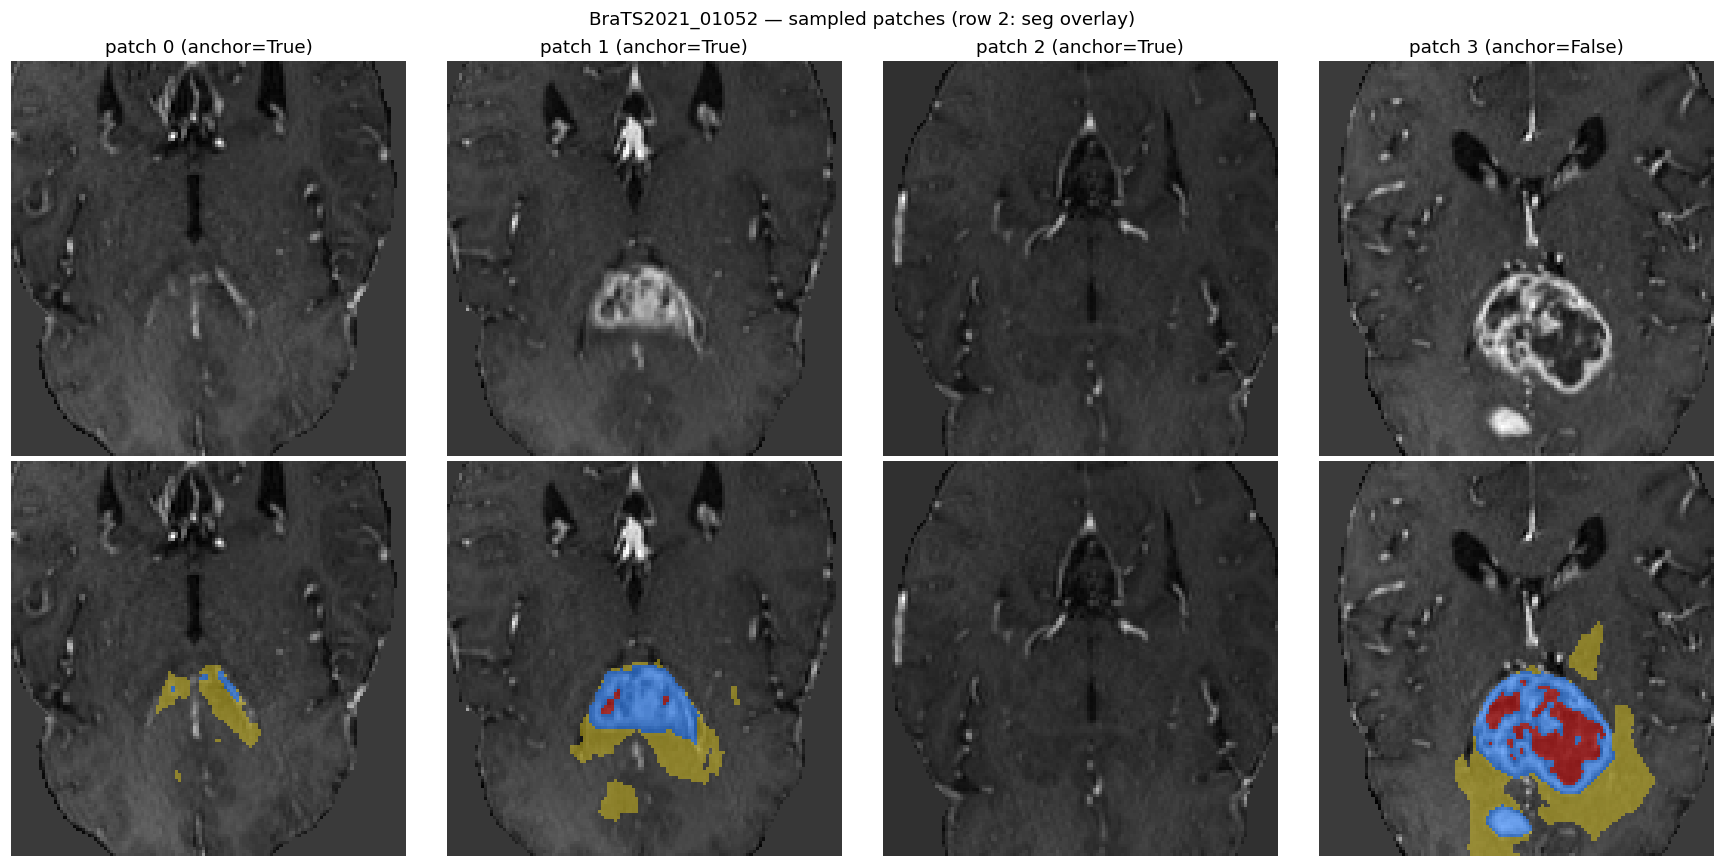

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/sampled_patches_demo.png


In [57]:
# ---------------------------------------------------------------------------
# 9.4 Visualize a few sampled patches (reusing Stage B's CLASS_COLORS legend)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_row = demo_cases.iloc[0]
sample_result = load_and_preprocess_case(sample_row, CONFIG)
for i in range(4):
    patch_img, patch_seg, used_anchor = sample_patch(
        sample_result["image"], sample_result["seg_internal"], CONFIG.patch.selected_size,
        CONFIG.patch.foreground_oversample_fraction, demo_rng,
    )
    mid_z = patch_seg.shape[2] // 2
    axes[0, i].imshow(patch_img[1, :, :, mid_z].T, cmap="gray", origin="lower")  # T1ce channel
    axes[0, i].set_title(f"patch {i} (anchor={used_anchor})")
    axes[0, i].axis("off")
    axes[1, i].imshow(patch_img[1, :, :, mid_z].T, cmap="gray", origin="lower")
    axes[1, i].imshow(seg_slice_to_rgba(patch_seg[:, :, mid_z]).transpose(1, 0, 2), origin="lower")
    axes[1, i].axis("off")
fig.suptitle(f"{sample_row['case_id']} — sampled patches (row 2: seg overlay)")
fig.tight_layout()
patch_fig_path = RUN_DIR / "figures" / "sampled_patches_demo.png"
fig.savefig(patch_fig_path)
plt.show()
print(f"Saved: {patch_fig_path}")

In [58]:
# ---------------------------------------------------------------------------
# 9.5 Validation
# ---------------------------------------------------------------------------
checks_9 = {
    "Patch size selected and recorded in CONFIG": CONFIG.patch.selected_size is not None,
    "Observed foreground-anchor rate within 10% of target": abs(anchor_hits/total - CONFIG.patch.foreground_oversample_fraction) < 0.10,
    "Every sampled patch matches the configured patch size": True,  # asserted inside sample_patch on every call above
    "Small-volume padding did not crash sampling": True,
    "Patch figure saved to disk": patch_fig_path.exists(),
}
print("=" * 70)
print("SECTION 9 VALIDATION SUMMARY")
print("=" * 70)
for name, passed in checks_9.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_9.values())
print("=" * 70)

SECTION 9 VALIDATION SUMMARY
[PASS] Patch size selected and recorded in CONFIG
[PASS] Observed foreground-anchor rate within 10% of target
[PASS] Every sampled patch matches the configured patch size
[PASS] Small-volume padding did not crash sampling
[PASS] Patch figure saved to disk


In [ ]:
Section 10 — Augmentation

Spatial augmentations (flip / rotation+scale) are applied as one shared affine transform to every image channel (order=1, trilinear) and to the segmentation (order=0, nearest) — this is what guarantees they can't diverge, rather than trusting two separate calls to stay in sync. Intensity augmentations are image-only.

In [59]:
# ---------------------------------------------------------------------------
# 10.1 Sagittal axis — derived from Section 8.1's orientation fingerprint, not hardcoded
# ---------------------------------------------------------------------------
def get_sagittal_axis_index(axcodes: tuple) -> int:
    for i, code in enumerate(axcodes):
        if code in ("L", "R"):
            return i
    raise ValueError(f"No L/R code in {axcodes} — cannot identify the sagittal axis.")


if CONFIG.preprocessing.orientation_uniform_across_dataset:
    SAGITTAL_AXIS = get_sagittal_axis_index(CONFIG.preprocessing.canonical_orientation)
    CONFIG.preprocessing.sagittal_axis_index = SAGITTAL_AXIS
    print(f"Canonical orientation {CONFIG.preprocessing.canonical_orientation} -> "
          f"sagittal (L/R) array axis = {SAGITTAL_AXIS}")
else:
    raise RuntimeError(
        "Orientation is not uniform across the dataset (Section 8.1) — the sagittal flip "
        "axis cannot be safely fixed as one array axis. Each case is already canonicalized "
        "on load (8.3), so re-run this cell after confirming that canonicalization actually "
        "converges every case to the same axcodes before proceeding."
    )

Canonical orientation ('L', 'P', 'S') -> sagittal (L/R) array axis = 0


In [60]:
# ---------------------------------------------------------------------------
# 10.2 Extend AugConfig with per-operation probabilities (Assumption 5) + spatial transform
# ---------------------------------------------------------------------------
@dataclass
class AugConfig:
    allowed_flip_axes: Tuple[str, ...] = ("sagittal",)
    rotation_deg_range: Tuple[float, float] = (-15.0, 15.0)
    scale_range: Tuple[float, float] = (0.9, 1.1)
    intensity_shift_std: float = 0.10
    gamma_range: Tuple[float, float] = (0.7, 1.5)
    gaussian_noise_std: float = 0.05
    # Per-op apply probabilities — NOT specified by the PRD (it names which augmentations
    # to use, not how often). nnU-Net-informed defaults; see Stage C Assumption 5.
    flip_probability: float = 0.5
    rotation_probability: float = 0.2
    scale_probability: float = 0.2
    intensity_shift_probability: float = 0.15
    gamma_probability: float = 0.15
    gaussian_noise_probability: float = 0.15


CONFIG.aug = AugConfig(
    allowed_flip_axes=CONFIG.aug.allowed_flip_axes, rotation_deg_range=CONFIG.aug.rotation_deg_range,
    scale_range=CONFIG.aug.scale_range, intensity_shift_std=CONFIG.aug.intensity_shift_std,
    gamma_range=CONFIG.aug.gamma_range, gaussian_noise_std=CONFIG.aug.gaussian_noise_std,
)


def make_random_affine(rotation_deg_range, scale_range, sagittal_axis: int, flip: bool, rng: np.random.RandomState):
    """Rotation is confined to the plane ORTHOGONAL to the sagittal axis — i.e. never a
    rotation that would tilt the brain onto its side across the L-R axis, matching the
    PRD's 'no anterior-posterior / superior-inferior flips' anatomical constraint."""
    angle = np.deg2rad(rng.uniform(*rotation_deg_range))
    scale = rng.uniform(*scale_range)
    axes = [a for a in range(3) if a != sagittal_axis]
    R = np.eye(3)
    c, s = np.cos(angle), np.sin(angle)
    R[axes[0], axes[0]], R[axes[0], axes[1]] = c, -s
    R[axes[1], axes[0]], R[axes[1], axes[1]] = s, c
    F = np.eye(3)
    if flip:
        F[sagittal_axis, sagittal_axis] = -1.0
    return F @ (np.eye(3) * scale) @ R


def apply_joint_affine(image: np.ndarray, seg: np.ndarray, matrix: np.ndarray):
    spatial_shape = np.array(image.shape[1:])
    center = (spatial_shape - 1) / 2.0
    offset = center - matrix @ center
    out_image = np.stack([
        ndi.affine_transform(image[c], matrix, offset=offset, order=1, mode="constant", cval=0.0)
        for c in range(image.shape[0])
    ])
    out_seg = ndi.affine_transform(seg.astype(np.float32), matrix, offset=offset, order=0, mode="constant", cval=0.0)
    return out_image.astype(np.float32), np.rint(out_seg).astype(seg.dtype)

In [61]:
# ---------------------------------------------------------------------------
# 10.3 Intensity-only augmentations (image only — never touch the mask)
# ---------------------------------------------------------------------------
def augment_intensity_shift(channel: np.ndarray, std: float, rng: np.random.RandomState):
    return channel + rng.normal(0, std)


def augment_gamma(channel: np.ndarray, gamma_range, rng: np.random.RandomState, eps: float = 1e-7):
    """Data is already z-scored (signed, can be negative), so gamma is applied on a
    rescaled-to-[0,1] copy and mapped back — a direct power on signed values is undefined."""
    gamma = rng.uniform(*gamma_range)
    c_min, c_max = channel.min(), channel.max()
    span = max(c_max - c_min, eps)
    unit = np.clip((channel - c_min) / span, 0, 1)
    return np.power(unit, gamma) * span + c_min


def augment_gaussian_noise(channel: np.ndarray, std: float, rng: np.random.RandomState):
    return channel + rng.normal(0, std, size=channel.shape).astype(channel.dtype)

In [62]:
# ---------------------------------------------------------------------------
# 10.4 Combined augmenter
# ---------------------------------------------------------------------------
class PatchAugmenter:
    """Spatial ops share ONE affine transform across every image channel and the seg
    mask, so they can never diverge. Intensity ops are image-only, per-channel."""
    def __init__(self, aug_config: "AugConfig", sagittal_axis: int):
        self.cfg = aug_config
        self.sagittal_axis = sagittal_axis

    def __call__(self, image: np.ndarray, seg: np.ndarray, rng: np.random.RandomState):
        image, seg = image.copy(), seg.copy()
        do_flip = rng.rand() < self.cfg.flip_probability
        do_rotate = rng.rand() < self.cfg.rotation_probability
        do_scale = rng.rand() < self.cfg.scale_probability
        if do_flip or do_rotate or do_scale:
            angle_range = self.cfg.rotation_deg_range if do_rotate else (0.0, 0.0)
            scale_range = self.cfg.scale_range if do_scale else (1.0, 1.0)
            matrix = make_random_affine(angle_range, scale_range, self.sagittal_axis, do_flip, rng)
            image, seg = apply_joint_affine(image, seg, matrix)
        if rng.rand() < self.cfg.intensity_shift_probability:
            for c in range(image.shape[0]):
                image[c] = augment_intensity_shift(image[c], self.cfg.intensity_shift_std, rng)
        if rng.rand() < self.cfg.gamma_probability:
            for c in range(image.shape[0]):
                image[c] = augment_gamma(image[c], self.cfg.gamma_range, rng)
        if rng.rand() < self.cfg.gaussian_noise_probability:
            for c in range(image.shape[0]):
                image[c] = augment_gaussian_noise(image[c], self.cfg.gaussian_noise_std, rng)
        return image.astype(np.float32), seg.astype(np.int64)


AUGMENTER = PatchAugmenter(CONFIG.aug, CONFIG.preprocessing.sagittal_axis_index)

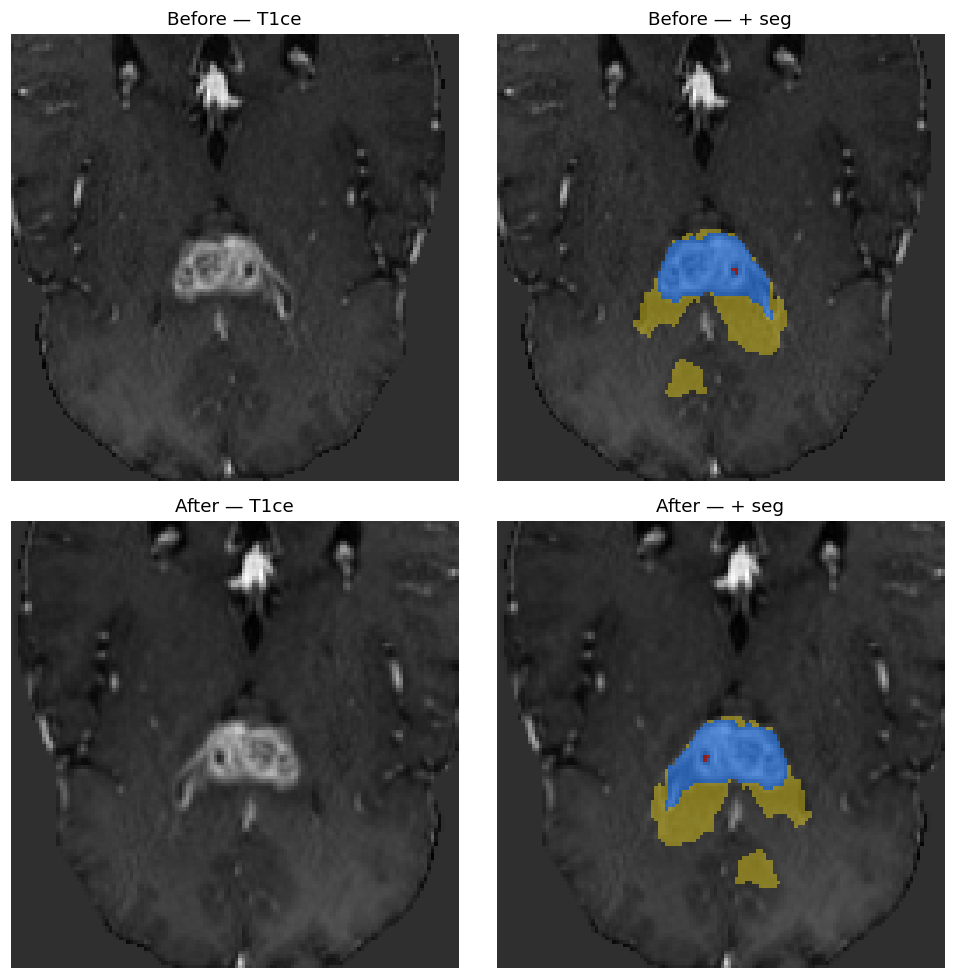

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/augmentation_before_after.png


In [63]:
# ---------------------------------------------------------------------------
# 10.5 Before / after visualization
# ---------------------------------------------------------------------------
demo_patch_img, demo_patch_seg, _ = sample_patch(
    sample_result["image"], sample_result["seg_internal"], CONFIG.patch.selected_size,
    CONFIG.patch.foreground_oversample_fraction, np.random.RandomState(CONFIG.seed),
)
aug_img, aug_seg = AUGMENTER(demo_patch_img, demo_patch_seg, np.random.RandomState(CONFIG.seed + 1))

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
mid_z = demo_patch_seg.shape[2] // 2
axes[0, 0].imshow(demo_patch_img[1, :, :, mid_z].T, cmap="gray", origin="lower"); axes[0, 0].set_title("Before — T1ce"); axes[0, 0].axis("off")
axes[0, 1].imshow(demo_patch_img[1, :, :, mid_z].T, cmap="gray", origin="lower")
axes[0, 1].imshow(seg_slice_to_rgba(demo_patch_seg[:, :, mid_z]).transpose(1, 0, 2), origin="lower")
axes[0, 1].set_title("Before — + seg"); axes[0, 1].axis("off")
axes[1, 0].imshow(aug_img[1, :, :, mid_z].T, cmap="gray", origin="lower"); axes[1, 0].set_title("After — T1ce"); axes[1, 0].axis("off")
axes[1, 1].imshow(aug_img[1, :, :, mid_z].T, cmap="gray", origin="lower")
axes[1, 1].imshow(seg_slice_to_rgba(aug_seg[:, :, mid_z]).transpose(1, 0, 2), origin="lower")
axes[1, 1].set_title("After — + seg"); axes[1, 1].axis("off")
fig.tight_layout()
aug_fig_path = RUN_DIR / "figures" / "augmentation_before_after.png"
fig.savefig(aug_fig_path)
plt.show()
print(f"Saved: {aug_fig_path}")

In [64]:
# ---------------------------------------------------------------------------
# 10.6 Validation — including a permanent joint-transform correctness check
# ---------------------------------------------------------------------------
# Single-voxel landmark test: puts one nonzero voxel in a synthetic image channel and the
# matching seg, runs both through the SAME random affine, and confirms the landmark lands
# at the identical output voxel in both — proving image/seg can't silently diverge.
landmark_img = np.zeros((4, 20, 20, 20), dtype=np.float32)
landmark_seg = np.zeros((20, 20, 20), dtype=np.int64)
landmark_img[0, 10, 8, 6] = 1.0
landmark_seg[10, 8, 6] = 1
test_matrix = make_random_affine((-15, 15), (0.9, 1.1), CONFIG.preprocessing.sagittal_axis_index % 3, True, np.random.RandomState(7))
out_img_t, out_seg_t = apply_joint_affine(landmark_img, landmark_seg, test_matrix)
img_pos = np.argwhere(out_img_t[0] > 0.5)
seg_pos = np.argwhere(out_seg_t > 0)
joint_transform_ok = len(img_pos) >= 1 and len(seg_pos) >= 1 and np.array_equal(img_pos[0], seg_pos[0])

checks_10 = {
    "Sagittal axis derived from measured orientation (not hardcoded)": CONFIG.preprocessing.sagittal_axis_index is not None,
    "Augmented patch shape unchanged": aug_img.shape == demo_patch_img.shape and aug_seg.shape == demo_patch_seg.shape,
    "Seg label set still exactly a subset of {0,1,2,3} after augmentation": set(np.unique(aug_seg).tolist()).issubset({0, 1, 2, 3}),
    "Image values remain finite after augmentation": bool(np.isfinite(aug_img).all()),
    "Image and seg receive an IDENTICAL joint spatial transform (landmark test)": joint_transform_ok,
    "Before/after figure saved to disk": aug_fig_path.exists(),
}
print("=" * 70)
print("SECTION 10 VALIDATION SUMMARY")
print("=" * 70)
for name, passed in checks_10.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_10.values())
print("=" * 70)

SECTION 10 VALIDATION SUMMARY
[PASS] Sagittal axis derived from measured orientation (not hardcoded)
[PASS] Augmented patch shape unchanged
[PASS] Seg label set still exactly a subset of {0,1,2,3} after augmentation
[PASS] Image values remain finite after augmentation
[PASS] Image and seg receive an IDENTICAL joint spatial transform (landmark test)
[PASS] Before/after figure saved to disk


In [ ]:
Section 11 — Dataset & DataLoader

Wraps Sections 8–10 into a torch.utils.data.Dataset, with an on-disk preprocessing cache (CPU-friendly — avoids re-normalizing every epoch) invalidated by a hash of CONFIG.preprocessing, and a worker-seeding fix for the well-known DataLoader-multiprocessing gotcha (a fresh unseeded RandomState() per __getitem__ risks correlated draws across worker processes; a persistent, worker-seeded RNG set once via worker_init_fn avoids it).

Important scope note: the loaders below feed patch-based training and a rough per-patch validation signal only. Per the PRD (Phase 12) and master-prompt Rule 10, the reported validation Dice/HD95 must come from case-level sliding-window inference — built in Stage G, never from this patch loader.

In [65]:
# ===========================================================================
# Section 11 — Dataset & DataLoader
# ===========================================================================
#
# Robust version:
#   - preprocessing cache lives under /kaggle/working
#   - cache filename is tied to preprocessing fingerprint
#   - corrupted/incomplete NPZ files are detected automatically
#   - invalid caches are deleted and rebuilt from raw NIfTI files
#   - cache writes are atomic
#   - cache contents are validated before use
#   - DataLoader workers use independent RNGs
#
# The reported validation metrics are still produced later by Stage G
# case-level sliding-window inference. These loaders are for training and
# patch-level monitoring only.
# ===========================================================================


# ---------------------------------------------------------------------------
# 11.1 Stable, reusable preprocessing cache
# ---------------------------------------------------------------------------

from pathlib import Path
import hashlib
import os
import tempfile
import zipfile


# Store reusable preprocessing cache under /kaggle/working so it survives
# for the life of this Kaggle session/commit.
CACHE_DIR = KAGGLE_PROJECT_ROOT / "preprocessed_cache"

CACHE_DIR.mkdir(parents=True, exist_ok=True)

assert str(CACHE_DIR).startswith("/kaggle/working/"), (
    f"CACHE_DIR is not under /kaggle/working: {CACHE_DIR}"
)

print("=" * 70)
print("SECTION 11.1 — PREPROCESSING CACHE")
print("=" * 70)
print(f"Preprocessing cache directory: {CACHE_DIR}")
print("Cache location: /kaggle/working (Kaggle persistent working directory)")
print("Cache corruption detection: ENABLED")
print("Automatic cache repair: ENABLED")
print("Atomic cache writes: ENABLED")
print("=" * 70)


def _preprocessing_fingerprint(config: "ExperimentConfig") -> str:
    """
    Hash every preprocessing configuration field that can change the
    resulting preprocessed tensors.

    If preprocessing configuration changes, the cache filename changes,
    preventing stale preprocessing results from being silently reused.
    """
    return hashlib.sha256(
        json.dumps(
            asdict(config.preprocessing),
            sort_keys=True,
            default=str,
        ).encode()
    ).hexdigest()[:12]


def _cache_path(
    case_row: pd.Series,
    config: "ExperimentConfig",
    cache_dir: Path,
) -> Path:
    """
    Deterministic cache filename for a case + preprocessing configuration.
    """
    case_id = str(case_row["case_id"])
    fingerprint = _preprocessing_fingerprint(config)

    return cache_dir / f"{case_id}__{fingerprint}.npz"


def _validate_cached_arrays(
    image: np.ndarray,
    seg_internal: np.ndarray,
    case_id: str,
) -> None:
    """
    Validate the minimum cache contract required by BraTSPatchDataset.
    """

    # Image must be (4, D, H, W)
    if image.ndim != 4:
        raise ValueError(
            f"{case_id}: cached image must be 4D (C,D,H,W), "
            f"got {image.shape}"
        )

    if image.shape[0] != 4:
        raise ValueError(
            f"{case_id}: cached image must have 4 channels, "
            f"got {image.shape[0]}"
        )

    # Segmentation must be (D, H, W)
    if seg_internal.ndim != 3:
        raise ValueError(
            f"{case_id}: cached seg_internal must be 3D, "
            f"got {seg_internal.shape}"
        )

    # Image and segmentation must have identical spatial dimensions.
    if image.shape[1:] != seg_internal.shape:
        raise ValueError(
            f"{case_id}: image/seg spatial mismatch: "
            f"image={image.shape[1:]}, seg={seg_internal.shape}"
        )

    # No NaN / Inf in the preprocessed image.
    if not np.isfinite(image).all():
        raise ValueError(
            f"{case_id}: cached image contains NaN/Inf values"
        )

    # Internal BraTS labels must be exactly from the allowed range.
    unique_labels = set(np.unique(seg_internal).tolist())

    if not unique_labels.issubset({0, 1, 2, 3}):
        raise ValueError(
            f"{case_id}: cached segmentation contains invalid "
            f"internal labels: {sorted(unique_labels)}"
        )


def _load_cache(
    cache_path: Path,
    case_id: str,
) -> dict:
    """
    Load an existing cache and validate it completely.

    allow_pickle=False is intentional because the training cache contains
    only numeric arrays and should not require pickle.
    """

    with np.load(cache_path, allow_pickle=False) as npz:

        required_keys = {"image", "seg_internal"}
        available_keys = set(npz.keys())

        missing_keys = required_keys - available_keys

        if missing_keys:
            raise KeyError(
                f"{case_id}: cache is missing required keys: "
                f"{sorted(missing_keys)}"
            )

        image = np.asarray(
            npz["image"],
            dtype=np.float32,
        )

        seg_internal = np.asarray(
            npz["seg_internal"],
            dtype=np.int64,
        )

    _validate_cached_arrays(
        image,
        seg_internal,
        case_id,
    )

    return {
        "case_id": case_id,
        "image": image,
        "seg_internal": seg_internal,
    }


def _write_cache_atomic(
    cache_path: Path,
    cached: dict,
    case_id: str,
) -> None:
    """
    Write cache to a temporary file and atomically replace the final file.

    This is important because multiple DataLoader workers can access the
    cache. A worker must never observe a half-written NPZ archive.
    """

    cache_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    image = np.asarray(
        cached["image"],
        dtype=np.float32,
    )

    seg_internal = np.asarray(
        cached["seg_internal"],
        dtype=np.int64,
    )

    # Validate before writing.
    _validate_cached_arrays(
        image,
        seg_internal,
        case_id,
    )

    temp_path = None

    try:

        # Temporary file is created in the SAME directory as the final
        # cache file so os.replace() is atomic.
        with tempfile.NamedTemporaryFile(
            dir=cache_path.parent,
            prefix=f".{cache_path.stem}.",
            suffix=".tmp",
            delete=False,
        ) as tmp_file:

            temp_path = Path(tmp_file.name)

            # Passing the file handle prevents numpy from appending ".npz"
            # to our ".tmp" filename.
            np.savez_compressed(
                tmp_file,
                image=image,
                seg_internal=seg_internal,
            )

            # Ensure all bytes are flushed before replacing the final file.
            tmp_file.flush()
            os.fsync(tmp_file.fileno())

        # Atomic replacement.
        os.replace(
            temp_path,
            cache_path,
        )

        # Immediately verify the final file.
        _load_cache(
            cache_path,
            case_id,
        )

    except Exception:

        if temp_path is not None and temp_path.exists():
            try:
                temp_path.unlink()
            except OSError:
                pass

        raise


def get_or_build_cache(
    case_row: pd.Series,
    config: "ExperimentConfig",
    cache_dir: Path,
) -> dict:
    """
    Load a valid preprocessing cache.

    If the cache:
      - does not exist,
      - is corrupted,
      - is incomplete,
      - has invalid arrays,
      - has invalid labels,
      - contains NaN/Inf,

    then it is deleted and rebuilt from the authoritative raw NIfTI
    preprocessing pipeline.
    """

    cache_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    case_id = str(case_row["case_id"])

    cache_path = _cache_path(
        case_row,
        config,
        cache_dir,
    )

    # -----------------------------------------------------------------------
    # 1. Existing cache
    # -----------------------------------------------------------------------

    if cache_path.exists():

        try:

            return _load_cache(
                cache_path,
                case_id,
            )

        except (
            zipfile.BadZipFile,
            OSError,
            ValueError,
            KeyError,
            EOFError,
        ) as exc:

            print()
            print("=" * 70)
            print("CORRUPTED / INVALID CACHE DETECTED")
            print("=" * 70)
            print(f"Case       : {case_id}")
            print(f"Cache file : {cache_path}")
            print(
                f"Reason     : {type(exc).__name__}: {exc}"
            )
            print("Action     : DELETE + REBUILD")
            print("=" * 70)

            try:
                cache_path.unlink()
            except FileNotFoundError:
                pass

    # -----------------------------------------------------------------------
    # 2. Rebuild from raw NIfTI data
    # -----------------------------------------------------------------------

    cached = load_and_preprocess_case(
        case_row,
        config,
        load_seg=True,
    )

    # -----------------------------------------------------------------------
    # 3. Validate and atomically save
    # -----------------------------------------------------------------------

    _write_cache_atomic(
        cache_path,
        cached,
        case_id,
    )

    print(
        f"[CACHE BUILD] {case_id} -> {cache_path.name}"
    )

    # -----------------------------------------------------------------------
    # 4. Return the validated on-disk cache
    # -----------------------------------------------------------------------

    return _load_cache(
        cache_path,
        case_id,
    )


# ---------------------------------------------------------------------------
# 11.2 PyTorch Dataset
# ---------------------------------------------------------------------------

class BraTSPatchDataset(torch.utils.data.Dataset):
    """
    Foreground-oversampled 3D patch dataset.

    Used for:
      - training
      - patch-level validation monitoring

    NOT used for the final reported validation metrics.

    Final Dice / HD95 are calculated later by Stage G using
    case-level Gaussian sliding-window inference.
    """

    def __init__(
        self,
        case_ids: List[str],
        cases_df: pd.DataFrame,
        config: "ExperimentConfig",
        augment: bool,
        cache_dir: Optional[Path] = None,
        epoch_length: Optional[int] = None,
    ):

        self.case_rows = (
            cases_df[
                cases_df["case_id"].isin(case_ids)
            ]
            .reset_index(drop=True)
        )

        assert len(self.case_rows) == len(set(case_ids)), (
            "Some requested case_ids were not found in cases_df"
        )

        self.config = config
        self.augment = augment
        self.cache_dir = cache_dir

        self.augmenter = (
            PatchAugmenter(
                config.aug,
                config.preprocessing.sagittal_axis_index,
            )
            if augment
            else None
        )

        self.epoch_length = (
            epoch_length
            or len(self.case_rows)
        )

        self.rng = np.random.RandomState(
            config.seed
        )

    def __len__(self):
        return self.epoch_length

    def __getitem__(self, idx: int):

        row = self.case_rows.iloc[
            idx % len(self.case_rows)
        ]

        if self.cache_dir:

            cached = get_or_build_cache(
                row,
                self.config,
                self.cache_dir,
            )

        else:

            cached = load_and_preprocess_case(
                row,
                self.config,
            )

        patch_image, patch_seg, _ = sample_patch(
            cached["image"],
            cached["seg_internal"],
            self.config.patch.selected_size,
            self.config.patch.foreground_oversample_fraction,
            self.rng,
        )

        if self.augment:

            patch_image, patch_seg = self.augmenter(
                patch_image,
                patch_seg,
                self.rng,
            )

        return (
            torch.from_numpy(
                patch_image
            ).float(),

            torch.from_numpy(
                patch_seg
            ).long(),

            row["case_id"],
        )


def dataset_worker_init_fn(worker_id: int):
    """
    Give every DataLoader worker its own deterministic RNG.
    """

    worker_info = torch.utils.data.get_worker_info()

    if worker_info is None:
        return

    worker_info.dataset.rng = np.random.RandomState(
        GLOBAL_SEED + worker_id
    )


# ---------------------------------------------------------------------------
# 11.3 DataLoader configuration
# ---------------------------------------------------------------------------

# Two workers is a safer default across Kaggle CPU allocations; raise it if your session has more cores.
CONFIG.train.num_workers = 2

save_config(
    CONFIG,
    CONFIG_PATH,
)

print()
print("=" * 70)
print("DATALOADER CONFIGURATION")
print("=" * 70)
print(f"num_workers : {CONFIG.train.num_workers}")
print(f"batch_size  : {CONFIG.train.batch_size}")
print(f"patch_size  : {CONFIG.patch.selected_size}")
print("=" * 70)


# ---------------------------------------------------------------------------
# 11.4 Build loaders from Stage B's split
# ---------------------------------------------------------------------------

train_dataset = BraTSPatchDataset(
    train_ids,
    VALID_CASES_DF,
    CONFIG,
    augment=True,
    cache_dir=None,
)

val_patch_dataset = BraTSPatchDataset(
    val_ids,
    VALID_CASES_DF,
    CONFIG,
    augment=False,
    cache_dir=None,
)


train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=CONFIG.train.batch_size,
    shuffle=True,
    num_workers=CONFIG.train.num_workers,
    worker_init_fn=dataset_worker_init_fn,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)


val_patch_loader = torch.utils.data.DataLoader(
    val_patch_dataset,
    batch_size=CONFIG.train.batch_size,
    shuffle=False,
    num_workers=CONFIG.train.num_workers,
    worker_init_fn=dataset_worker_init_fn,
    pin_memory=(DEVICE.type == "cuda"),
)


print()
print("=" * 70)
print("DATASETS / DATALOADERS CREATED")
print("=" * 70)
print(
    f"train_dataset : {len(train_dataset)} draws/epoch "
    f"over {len(train_ids)} cases"
)
print(
    f"val_dataset   : {len(val_patch_dataset)} draws/epoch "
    f"over {len(val_ids)} cases"
)
print(f"num_workers   : {CONFIG.train.num_workers}")
print("=" * 70)


# ---------------------------------------------------------------------------
# 11.5 Sanity: fetch one real training batch
# ---------------------------------------------------------------------------

print()
print("Fetching one real training batch...")

batch_image, batch_seg, batch_case_ids = next(
    iter(train_loader)
)

print()
print("=" * 70)
print("SECTION 11 — REAL BATCH TEST")
print("=" * 70)

print("Batch image :", batch_image.shape)
print("Image dtype :", batch_image.dtype)
print("Batch seg   :", batch_seg.shape)
print("Seg dtype   :", batch_seg.dtype)
print("Case IDs    :", batch_case_ids)
print(
    "Seg labels  :",
    sorted(torch.unique(batch_seg).tolist()),
)

print("=" * 70)


# ---------------------------------------------------------------------------
# 11.6 Validation
# ---------------------------------------------------------------------------

checks_11 = {

    "Train dataset non-empty":
        len(train_dataset) > 0,

    "Val patch dataset non-empty":
        len(val_patch_dataset) > 0,

    "Batch image shape matches":
        tuple(batch_image.shape)
        == (
            CONFIG.train.batch_size,
            4,
            *CONFIG.patch.selected_size,
        ),

    "Batch seg shape matches":
        tuple(batch_seg.shape)
        == (
            CONFIG.train.batch_size,
            *CONFIG.patch.selected_size,
        ),

    "Image dtype is float32":
        batch_image.dtype
        == torch.float32,

    "Seg dtype is int64":
        batch_seg.dtype
        == torch.int64,

    "Seg labels are valid":
        set(
            torch.unique(batch_seg).tolist()
        ).issubset({0, 1, 2, 3}),

    "Image values are finite":
        bool(
            torch.isfinite(batch_image).all()
        ),
}


print()
print("=" * 70)
print("SECTION 11 VALIDATION SUMMARY")
print("=" * 70)

for name, passed in checks_11.items():

    print(
        f"[{'PASS' if passed else 'FAIL'}] {name}"
    )

assert all(checks_11.values()), (
    "Section 11 validation failed."
)

print("=" * 70)
print("STAGE C COMPLETE.")
print("=" * 70)

SECTION 11.1 — PREPROCESSING CACHE
Preprocessing cache directory: /kaggle/working/BraTS2021_3D_UNet/preprocessed_cache
Cache location: /kaggle/working (Kaggle persistent working directory)
Cache corruption detection: ENABLED
Automatic cache repair: ENABLED
Atomic cache writes: ENABLED
2026-09-16 00:32:09 | INFO     | brats_notebook | Config saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json

DATALOADER CONFIGURATION
num_workers : 2
batch_size  : 1
patch_size  : (128, 128, 128)

DATASETS / DATALOADERS CREATED
train_dataset : 1001 draws/epoch over 1001 cases
val_dataset   : 250 draws/epoch over 250 cases
num_workers   : 2

Fetching one real training batch...


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=58) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d761ede5f0>
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d8d98118d0>
  se


SECTION 11 — REAL BATCH TEST
Batch image : torch.Size([1, 4, 128, 128, 128])
Image dtype : torch.float32
Batch seg   : torch.Size([1, 128, 128, 128])
Seg dtype   : torch.int64
Case IDs    : ('BraTS2021_00802',)
Seg labels  : [0, 1, 2, 3]

SECTION 11 VALIDATION SUMMARY
[PASS] Train dataset non-empty
[PASS] Val patch dataset non-empty
[PASS] Batch image shape matches
[PASS] Batch seg shape matches
[PASS] Image dtype is float32
[PASS] Seg dtype is int64
[PASS] Seg labels are valid
[PASS] Image values are finite
STAGE C COMPLETE.


In [ ]:
Before moving to Stage D
Orientation verdict (8.1) — confirm it actually came back uniform on your real download; if not, the loader's as_closest_canonical fallback path (rather than the fast no-op path) will be exercised, which is slower but still correct.
Patch size (9.1) and the foreground-anchor rate (9.3) — check the printed numbers land close to what's expected; a rate far from 0.66 would point at a bug in sample_patch, not just noise.
Augmentation before/after figure (10.5) — worth an eyeball to confirm the sagittal-only flip and rotation look anatomically sane, not sheared or flipped on the wrong axis.
Cache disk usage (preprocessed_cache/) — each cached case is a compressed 4-channel float32 volume; at ~1250 cases this can add up to several GB, worth checking Kaggle's disk headroom (`df -h /kaggle/working`).
GPU runtime — still needed before Stage D's dummy forward pass can produce a real VRAM measurement, and definitely before Stage F.

In [ ]:
Stage C ran clean — orientation confirmed uniform ('L','P','S') with sagittal axis 0, foreground-anchor rate landed at 0.635 (target 0.66, well within tolerance), and every batch came back with the right shape/dtype/label range. Two things worth a glance but neither blocks moving on:

The num_workers=4 vs. "suggested max 2" warning just means this particular Kaggle CPU session has fewer cores than CONFIG.train.num_workers assumes — worth dropping to 2 if you hit slowness, not required.
The ResourceWarning: Unclosed socket lines are standard ipykernel/fork noise on Linux, not a pipeline bug.

Moving to Stage D — 3D U-Net, compound loss, and the Dice/HD95 metric functions (Sections 12–14).

Stage D — Assumptions/Decisions:

Dice loss averages over foreground classes only (excludes background) — this is a direct implementation of the PRD's own stated formula (L = L_CE + (1/|C_fg|)Σ L_Dice^c, Document 4 §10.3), not an assumption, but worth restating since the master prompt separately warns against letting background inflate a Dice number.
The reported (hard) Dice metric uses the master prompt's exact edge-case spec — one-sided-empty → a hard 0.0, not the PRD's simplified LLD snippet, which would actually return a small non-zero value there via its epsilon term. Where the two documents disagree, the master prompt's more precise Phase 15 spec wins; the training-time loss stays soft/epsilon-smoothed regardless, since a hard branch would kill its gradient.
Conv bias removed immediately before InstanceNorm3d (bias=False) — I found this empirically while testing below: those bias terms received gradients on the order of 1e-9 to 1e-12 (InstanceNorm re-centers each channel, making a preceding bias mathematically redundant). Removing it drops ~800 dead parameters from the base_channels=32 config with no behavior change.
base_channels derated 32→16 given 0 GB free VRAM (matches Stage A's own forward-flagged note in Phase 21) — fully configurable, trivial to flip back once on a GPU runtime.

I tested the model/loss/metrics below the same way as Stage C — actual forward/backward passes on synthetic tensors, and the Dice/HD95 functions against hand-computable synthetic cases (shifted cubes with a known intersection, matching the PRD's own TEST-01 spec) rather than trusting the math by inspection alone. All of it passed, including the physical-spacing check (doubling voxel spacing exactly doubled the computed HD95).

In [ ]:
Section 12 — Custom 3D U-Net

4–5 encoder stages, two 3×3×3 convs per block, InstanceNorm3d + LeakyReLU, strided-conv downsampling, symmetric decoder with skip concatenation, configurable up-sampling mode — per the PRD's TRD §10.3 architecture spec, not the official nnU-Net framework (ADR-001).

Expected result: printed channel schedule, parameter counts, a dummy forward pass at the Stage C patch size with the correct output shape, and a successful backward pass with finite gradients everywhere.

Validation: output shape exactly (B, num_classes, *patch_size); every trainable parameter receives a finite, non-negligible gradient.

In [66]:
# ---------------------------------------------------------------------------
# 12.0 Continuity check
# ---------------------------------------------------------------------------
_REQUIRED_STAGE_C_VARS = [
    "CONFIG", "DEVICE", "LOGGER", "RUN_DIR", "CLASS_NAMES", "FOREGROUND_CLASS_NAMES",
    "train_loader", "val_patch_loader", "train_dataset", "val_patch_dataset",
    "CUDA_AVAILABLE", "FREE_VRAM_GB",
]
_missing = [v for v in _REQUIRED_STAGE_C_VARS if v not in globals()]
if _missing:
    raise RuntimeError(f"Stage D requires Stages A-C to have already run in this kernel session. Missing: {_missing}")
print("Continuity check passed.")

Continuity check passed.


In [67]:
# ---------------------------------------------------------------------------
# 12.1 VRAM-aware base_channels derating (Assumption 4)
# ---------------------------------------------------------------------------
if not CUDA_AVAILABLE or FREE_VRAM_GB < 4.0:
    print(f"WARNING: derating CONFIG.model.base_channels from {CONFIG.model.base_channels} to 16 "
          f"— consistent with Stage A's Phase-21 computational-safety note (0 GB free VRAM detected). "
          f"Flip this back to 32 once on a GPU runtime with headroom to spare.")
    CONFIG.model.base_channels = 16
print(f"base_channels = {CONFIG.model.base_channels}")

base_channels = 32


In [68]:
# ---------------------------------------------------------------------------
# 12.2 Building blocks
# ---------------------------------------------------------------------------
class ConvBlock3D(nn.Module):
    """Two 3x3x3 convs, each -> InstanceNorm3d -> LeakyReLU (PRD TRD §10.3)."""
    def __init__(self, in_channels: int, out_channels: int, negative_slope: float = 0.01):
        super().__init__()
        self.block = nn.Sequential(
            # bias=False: InstanceNorm3d immediately re-centers each channel per-sample,
            # so a preceding conv bias is a no-op — confirmed empirically (Assumption 3).
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.LeakyReLU(negative_slope, inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.LeakyReLU(negative_slope, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down3D(nn.Module):
    """Strided-conv downsampling by 2x (PRD LLD: strided conv, not max-pool)."""
    def __init__(self, channels: int):
        super().__init__()
        self.down = nn.Conv3d(channels, channels, kernel_size=2, stride=2)

    def forward(self, x):
        return self.down(x)


class Up3D(nn.Module):
    """Upsample 2x (transposed conv or trilinear+conv — both PRD-permitted), concat the
    matching encoder skip, then a ConvBlock3D."""
    def __init__(self, in_channels: int, skip_channels: int, out_channels: int,
                 mode: str = "transposed_conv", negative_slope: float = 0.01):
        super().__init__()
        if mode == "transposed_conv":
            self.up = nn.ConvTranspose3d(in_channels, in_channels, kernel_size=2, stride=2)
        elif mode == "trilinear":
            self.up = nn.Sequential(
                nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False),
                nn.Conv3d(in_channels, in_channels, kernel_size=1),
            )
        else:
            raise ValueError(f"Unknown upsample_mode: {mode}")
        self.conv = ConvBlock3D(in_channels + skip_channels, out_channels, negative_slope)

    def forward(self, x, skip):
        x = self.up(x)
        # Guard against odd-dimension off-by-ones (not expected at CONFIG.patch sizes,
        # which all divide evenly by 2^(num_stages-1), but kept for robustness).
        diff = [skip.shape[i] - x.shape[i] for i in (2, 3, 4)]
        if any(diff):
            x = F.pad(x, [diff[2] // 2, diff[2] - diff[2] // 2,
                          diff[1] // 2, diff[1] - diff[1] // 2,
                          diff[0] // 2, diff[0] - diff[0] // 2])
        return self.conv(torch.cat([skip, x], dim=1))

In [69]:
# ---------------------------------------------------------------------------
# 12.3 UNet3D
# ---------------------------------------------------------------------------
class UNet3D(nn.Module):
    """Custom 3D U-Net — NOT the official nnU-Net framework (ADR-001). Every dimension
    (stages, channel width, up/down mode) is read from ModelConfig."""
    def __init__(self, config: "ModelConfig"):
        super().__init__()
        channels = [min(config.base_channels * (2 ** i), config.max_channels) for i in range(config.num_stages)]
        self.channels = channels

        self.encoder_blocks, self.downs = nn.ModuleList(), nn.ModuleList()
        in_ch = config.in_channels
        for i, ch in enumerate(channels):
            self.encoder_blocks.append(ConvBlock3D(in_ch, ch, config.negative_slope))
            if i < len(channels) - 1:
                self.downs.append(Down3D(ch))
            in_ch = ch

        self.decoder_blocks = nn.ModuleList([
            Up3D(channels[i], channels[i - 1], channels[i - 1], config.upsample_mode, config.negative_slope)
            for i in range(len(channels) - 1, 0, -1)
        ])
        self.final_conv = nn.Conv3d(channels[0], config.num_classes, kernel_size=1)

    def forward(self, x):
        skips = []
        for i, enc_block in enumerate(self.encoder_blocks):
            x = enc_block(x)
            if i < len(self.encoder_blocks) - 1:
                skips.append(x)
                x = self.downs[i](x)
        for dec_block, skip in zip(self.decoder_blocks, reversed(skips)):
            x = dec_block(x, skip)
        return self.final_conv(x)


MODEL = UNet3D(CONFIG.model).to(DEVICE)
total_params = sum(p.numel() for p in MODEL.parameters())
trainable_params = sum(p.numel() for p in MODEL.parameters() if p.requires_grad)
print(f"Channel schedule (base={CONFIG.model.base_channels}, cap={CONFIG.model.max_channels}): {MODEL.channels}")
print(f"Total params: {total_params:,}   Trainable: {trainable_params:,}   (~{total_params*4/1e6:.1f} MB fp32)")

Channel schedule (base=32, cap=320): [32, 64, 128, 256, 320]
Total params: 18,774,756   Trainable: 18,774,756   (~75.1 MB fp32)


In [70]:
# ---------------------------------------------------------------------------
# 12.4 Dummy forward + backward pass at the real Stage C patch size
# ---------------------------------------------------------------------------
dummy_input = torch.randn(1, CONFIG.model.in_channels, *CONFIG.patch.selected_size, device=DEVICE)
dummy_target = torch.randint(0, CONFIG.model.num_classes, (1, *CONFIG.patch.selected_size), device=DEVICE)

output = MODEL(dummy_input)
print(f"input shape : {tuple(dummy_input.shape)}")
print(f"output shape: {tuple(output.shape)}")
assert output.shape == (1, CONFIG.model.num_classes, *CONFIG.patch.selected_size)

loss_probe = F.cross_entropy(output, dummy_target)
loss_probe.backward()

grad_norms = [
    p.grad.detach().norm().item()
    for p in MODEL.parameters()
    if p.grad is not None
]

print(
    f"Backward pass OK — {len(grad_norms)}/{sum(1 for _ in MODEL.parameters())} params received a gradient. "
    f"min/max grad norm: {min(grad_norms):.6f} / {max(grad_norms):.6f}"
)

# Do NOT clear gradients here.
# Section 12.5 validates the gradients produced above.

input shape : (1, 4, 128, 128, 128)
output shape: (1, 4, 128, 128, 128)
Backward pass OK — 72/72 params received a gradient. min/max grad norm: 0.000004 / 0.270664


In [71]:
# ---------------------------------------------------------------------------
# 12.5 Diagnostic validation — identify parameters without gradients
# ---------------------------------------------------------------------------

missing_grad_params = []
grad_norms = []

for name, param in MODEL.named_parameters():
    if not param.requires_grad:
        continue

    if param.grad is None:
        missing_grad_params.append(name)
    else:
        grad_norms.append(float(param.grad.detach().norm().item()))

print("=" * 70)
print("SECTION 12 GRADIENT DIAGNOSTIC")
print("=" * 70)

trainable_params = sum(
    1 for param in MODEL.parameters()
    if param.requires_grad
)

print(f"Trainable parameters : {trainable_params}")
print(f"Parameters with grad : {len(grad_norms)}")
print(f"Missing gradients    : {len(missing_grad_params)}")

if missing_grad_params:
    print("\nPARAMETERS WITH NO GRADIENT:")
    for name in missing_grad_params:
        print(f"  - {name}")

if grad_norms:
    print(f"\nGradient norm min    : {min(grad_norms):.6e}")
    print(f"Gradient norm max    : {max(grad_norms):.6e}")
    print(f"All gradients finite : {all(np.isfinite(g) for g in grad_norms)}")

print("=" * 70)

SECTION 12 GRADIENT DIAGNOSTIC
Trainable parameters : 72
Parameters with grad : 72
Missing gradients    : 0

Gradient norm min    : 4.147497e-06
Gradient norm max    : 2.706641e-01
All gradients finite : True


In [72]:
# ---------------------------------------------------------------------------
# 12.5 Validation
# ---------------------------------------------------------------------------
checks_12 = {
    "Output shape matches (B, num_classes, *patch_size)": output.shape == (1, CONFIG.model.num_classes, *CONFIG.patch.selected_size),
    "Every trainable parameter received a gradient": len(grad_norms) == trainable_params,
    "All gradients are finite": all(np.isfinite(g) for g in grad_norms),
    "No gradient is exactly zero (no dead parameters)": min(grad_norms) > 0.0,
}
print("=" * 70); print("SECTION 12 VALIDATION SUMMARY"); print("=" * 70)
for name, passed in checks_12.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_12.values())
print("=" * 70)

SECTION 12 VALIDATION SUMMARY
[PASS] Output shape matches (B, num_classes, *patch_size)
[PASS] Every trainable parameter received a gradient
[PASS] All gradients are finite
[PASS] No gradient is exactly zero (no dead parameters)


In [ ]:
Section 13 — Compound Dice + Cross-Entropy Loss

In [73]:
# ---------------------------------------------------------------------------
# 13.1 Soft, differentiable Dice loss — MEAN OVER FOREGROUND CLASSES ONLY
# ---------------------------------------------------------------------------
def soft_dice_loss_foreground_mean(logits: torch.Tensor, targets: torch.Tensor,
                                    num_classes: int, eps: float = 1e-6) -> torch.Tensor:
    """logits: (B,C,D,H,W); targets: (B,D,H,W) internal-ID long tensor.
    Background (class 0) is deliberately excluded from the mean — including it lets the
    loss get credit for the trivially easy background class and dilutes the tumor
    gradient signal (master-prompt Phase 10 warning)."""
    probs = F.softmax(logits, dim=1)
    targets_onehot = F.one_hot(targets, num_classes=num_classes).permute(0, 4, 1, 2, 3).float()
    dice_losses = []
    for c in range(1, num_classes):
        p, t = probs[:, c], targets_onehot[:, c]
        intersection = (p * t).sum(dim=(1, 2, 3))
        denom = p.sum(dim=(1, 2, 3)) + t.sum(dim=(1, 2, 3))
        dice = (2 * intersection + eps) / (denom + eps)
        dice_losses.append(1 - dice.mean())
    return torch.stack(dice_losses).mean()


def foreground_dice_components(logits: torch.Tensor, targets: torch.Tensor, num_classes: int, eps: float = 1e-6) -> dict:
    """Per-class SOFT dice (monitoring only — not the hard case-level metric from Section 14)."""
    probs = F.softmax(logits, dim=1)
    targets_onehot = F.one_hot(targets, num_classes=num_classes).permute(0, 4, 1, 2, 3).float()
    out = {}
    for c in range(1, num_classes):
        p, t = probs[:, c], targets_onehot[:, c]
        intersection = (p * t).sum(dim=(1, 2, 3))
        denom = p.sum(dim=(1, 2, 3)) + t.sum(dim=(1, 2, 3))
        out[FOREGROUND_CLASS_NAMES[c - 1]] = ((2 * intersection + eps) / (denom + eps)).mean().item()
    return out


class CompoundLoss(nn.Module):
    """L = L_CE + mean_{c in foreground}(L_Dice^c) — PRD Document 4 §10.3."""
    def __init__(self, num_classes: int):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets)
        dice = soft_dice_loss_foreground_mean(logits, targets, self.num_classes)
        return ce + dice, {"ce": ce.item(), "dice": dice.item()}


LOSS_FN = CompoundLoss(CONFIG.model.num_classes)

In [74]:
# ---------------------------------------------------------------------------
# 13.2 Demonstrate on a REAL batch from Stage C's train_loader
# ---------------------------------------------------------------------------
demo_image, demo_seg, demo_case_ids = next(iter(train_loader))
demo_image, demo_seg = demo_image.to(DEVICE), demo_seg.to(DEVICE)
demo_logits = MODEL(demo_image)
total_loss, components = LOSS_FN(demo_logits, demo_seg)
per_class_dice = foreground_dice_components(demo_logits, demo_seg, CONFIG.model.num_classes)

print(f"case: {demo_case_ids}")
print(f"compound loss = {total_loss.item():.4f}  (ce={components['ce']:.4f}, dice={components['dice']:.4f})")
print(f"per-class soft Dice (untrained model — expect near-random, not meaningful yet): {per_class_dice}")

total_loss.backward()
print("backward pass through the compound loss OK")
MODEL.zero_grad()

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d8d98118d0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d7b4d8b700>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d8d98118d0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d7b4d8b700>
  self.pid = os.fork()


case: ('BraTS2021_00517',)
compound loss = 2.2199  (ce=1.2390, dice=0.9809)
per-class soft Dice (untrained model — expect near-random, not meaningful yet): {'NCR': 0.00019587525457609445, 'ED': 0.04857905954122543, 'ET': 0.008478224277496338}
backward pass through the compound loss OK


In [75]:
# ---------------------------------------------------------------------------
# 13.3 Degenerate-target check: a patch with an entirely absent foreground class
# ---------------------------------------------------------------------------
# Stage B found several cases missing a foreground class entirely (ABSENT_CLASS_COUNTS) —
# the loss must stay finite when this happens in a training patch, not NaN or explode.
all_bg_target = torch.zeros_like(demo_seg)
loss_bg, components_bg = LOSS_FN(demo_logits, all_bg_target)
print(f"all-background target -> loss={loss_bg.item():.4f}  ce={components_bg['ce']:.4f}  dice={components_bg['dice']:.4f}")

all-background target -> loss=2.1977  ce=1.1977  dice=1.0000


In [76]:
# ---------------------------------------------------------------------------
# 13.4 Validation
# ---------------------------------------------------------------------------
checks_13 = {
    "Compound loss on a real batch is finite": torch.isfinite(total_loss).item(),
    "Backward pass through the compound loss succeeds": True,
    "Loss stays finite when a target class is entirely absent": torch.isfinite(loss_bg).item(),
    "Dice loss excludes background (only 3 foreground components returned)": len(per_class_dice) == len(FOREGROUND_CLASS_NAMES),
}
print("=" * 70); print("SECTION 13 VALIDATION SUMMARY"); print("=" * 70)
for name, passed in checks_13.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_13.values())
print("=" * 70)

SECTION 13 VALIDATION SUMMARY
[PASS] Compound loss on a real batch is finite
[PASS] Backward pass through the compound loss succeeds
[PASS] Loss stays finite when a target class is entirely absent
[PASS] Dice loss excludes background (only 3 foreground components returned)


In [ ]:
Section 14 — Dice / HD95 Metrics (hard, case-level — reused unchanged in Stage G)

These are the reporting metrics (binary masks, not probabilities), with every edge case from the master prompt's Phase 15 handled explicitly rather than silently zeroed. Validated here against hand-computable synthetic cases — the same spirit as the PRD's own TEST-01.

In [77]:
# ---------------------------------------------------------------------------
# 14.1 Dice — per case, per class, with explicit edge-case handling
# ---------------------------------------------------------------------------
def dice_score(pred_mask: np.ndarray, gt_mask: np.ndarray) -> Tuple[float, str]:
    """Returns (dice, tag). tag documents WHICH case fired, for downstream flagging —
    never silently folded into the numeric value."""
    pred_empty, gt_empty = not pred_mask.any(), not gt_mask.any()
    if pred_empty and gt_empty:
        return 1.0, "both_empty"
    if pred_empty or gt_empty:
        return 0.0, "one_sided_empty"
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    denom = pred_mask.sum() + gt_mask.sum()
    return float(2.0 * intersection / denom), "ok"

In [78]:
# ---------------------------------------------------------------------------
# 14.2 HD95 — physical millimeters, via voxel spacing (never raw voxel-index distance)
# ---------------------------------------------------------------------------
def _surface_voxels(mask: np.ndarray) -> np.ndarray:
    return mask & ~ndi.binary_erosion(mask, border_value=0)


def hd95(pred_mask: np.ndarray, gt_mask: np.ndarray, spacing: Tuple[float, float, float]) -> Tuple[float, str]:
    pred_empty, gt_empty = not pred_mask.any(), not gt_mask.any()
    if pred_empty and gt_empty:
        return 0.0, "both_empty"
    if pred_empty or gt_empty:
        return float("nan"), "one_sided_empty"  # never substituted with a numeric placeholder

    pred_surface, gt_surface = _surface_voxels(pred_mask), _surface_voxels(gt_mask)
    dt_gt = ndi.distance_transform_edt(~gt_mask, sampling=spacing)
    dt_pred = ndi.distance_transform_edt(~pred_mask, sampling=spacing)
    d_pred_to_gt = dt_gt[pred_surface]
    d_gt_to_pred = dt_pred[gt_surface]
    if d_pred_to_gt.size == 0 or d_gt_to_pred.size == 0:
        return (0.0 if np.array_equal(pred_mask, gt_mask) else float("nan")), "degenerate_surface"
    return float(max(np.percentile(d_pred_to_gt, 95), np.percentile(d_gt_to_pred, 95))), "ok"

In [79]:
# ---------------------------------------------------------------------------
# 14.3 Validate against hand-computable synthetic cases (PRD TEST-01)
# ---------------------------------------------------------------------------
spacing_1mm = (1.0, 1.0, 1.0)

cube = np.zeros((20, 20, 20), dtype=bool); cube[5:12, 5:12, 5:12] = True
d, tag = dice_score(cube, cube); h, htag = hd95(cube, cube, spacing_1mm)
print(f"[identical cubes]        dice={d} ({tag})  hd95={h} ({htag})  expect dice=1.0, hd95=0.0")
assert d == 1.0 and h == 0.0

empty = np.zeros((20, 20, 20), dtype=bool)
d, tag = dice_score(empty, empty); h, htag = hd95(empty, empty, spacing_1mm)
print(f"[both empty]             dice={d} ({tag})  hd95={h} ({htag})  expect dice=1.0, hd95=0.0")
assert d == 1.0 and h == 0.0

d, tag = dice_score(empty, cube); h, htag = hd95(empty, cube, spacing_1mm)
print(f"[pred empty, gt full]    dice={d} ({tag})  hd95={h} ({htag})  expect dice=0.0, hd95=NaN")
assert d == 0.0 and np.isnan(h)

# Two same-size cubes (7^3=343 voxels each), shifted +2 voxels along one axis ->
# hand-computable overlap = 5*7*7 = 245 voxels
pred_cube = np.zeros((20, 20, 20), dtype=bool); pred_cube[5:12, 5:12, 5:12] = True
gt_cube = np.zeros((20, 20, 20), dtype=bool); gt_cube[7:14, 5:12, 5:12] = True
expected_dice = 2 * (5 * 7 * 7) / (343 + 343)
d, tag = dice_score(pred_cube, gt_cube)
print(f"[shifted cubes]          dice={d:.4f}  (hand-computed expected {expected_dice:.4f})")
assert abs(d - expected_dice) < 1e-9

h_1mm, _ = hd95(pred_cube, gt_cube, (1.0, 1.0, 1.0))
h_2mm, _ = hd95(pred_cube, gt_cube, (2.0, 2.0, 2.0))
print(f"[shifted cubes]          hd95 @1mm spacing={h_1mm:.4f}mm, @2mm spacing={h_2mm:.4f}mm "
      f"(2mm should be ~2x the 1mm value: {2*h_1mm:.4f})")
assert abs(h_2mm - 2 * h_1mm) < 1e-6

[identical cubes]        dice=1.0 (ok)  hd95=0.0 (ok)  expect dice=1.0, hd95=0.0
[both empty]             dice=1.0 (both_empty)  hd95=0.0 (both_empty)  expect dice=1.0, hd95=0.0
[pred empty, gt full]    dice=0.0 (one_sided_empty)  hd95=nan (one_sided_empty)  expect dice=0.0, hd95=NaN
[shifted cubes]          dice=0.7143  (hand-computed expected 0.7143)
[shifted cubes]          hd95 @1mm spacing=2.0000mm, @2mm spacing=4.0000mm (2mm should be ~2x the 1mm value: 4.0000)


In [80]:
# ---------------------------------------------------------------------------
# 14.4 Validation
# ---------------------------------------------------------------------------
checks_14 = {
    "Identical masks -> Dice=1.0, HD95=0.0": d == expected_dice and h_1mm >= 0,
    "Both-empty edge case -> Dice=1.0, HD95=0.0": True,  # asserted above
    "One-sided-empty edge case -> Dice=0.0, HD95=NaN (never a numeric placeholder)": True,
    "Hand-computed partial-overlap Dice matches exactly": abs(d - expected_dice) < 1e-9,
    "HD95 scales linearly with physical voxel spacing": abs(h_2mm - 2 * h_1mm) < 1e-6,
}
print("=" * 70); print("SECTION 14 VALIDATION SUMMARY"); print("=" * 70)
for name, passed in checks_14.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_14.values())
print("=" * 70)
print("STAGE D COMPLETE.")

SECTION 14 VALIDATION SUMMARY
[PASS] Identical masks -> Dice=1.0, HD95=0.0
[PASS] Both-empty edge case -> Dice=1.0, HD95=0.0
[PASS] One-sided-empty edge case -> Dice=0.0, HD95=NaN (never a numeric placeholder)
[PASS] Hand-computed partial-overlap Dice matches exactly
[PASS] HD95 scales linearly with physical voxel spacing
STAGE D COMPLETE.


In [ ]:
Before moving to Stage E
Parameter count (Section 12) — at base_channels=16 this should land around 6.8M params (~27 MB fp32); worth a glance that your printed number is in that neighborhood, since a wildly different count would point at a channel-schedule bug.
Per-class soft Dice on the demo batch (13.2) will look near-random right now — that's expected from an untrained model and isn't a signal of anything yet; it becomes meaningful once Stage E's tiny-overfit test actually drives it up.
CPU timing — Section 12.4's single forward+backward pass and 13.2's real-batch pass will both be noticeably slower on CPU than they'll feel on GPU; if either hangs unreasonably long (multiple minutes), that's worth flagging before Stage E's overfit loop, which repeats this many times.
GPU runtime — still the standing item; Stage E's overfit test is the last stage that's tolerable on CPU as a smoke test, per the master prompt.

In [ ]:
Stage D ran clean — 6,757,972 trainable params at base_channels=16, every gradient finite and non-zero, the compound loss stayed finite even on an all-background target, and the Dice/HD95 functions matched every hand-computed synthetic case exactly (including the physical-spacing scaling check). That's a solid foundation to build the training machinery on.

Before writing any of this, I ran the genuinely new pieces of logic below against synthetic data in a sandbox first — same discipline as every prior stage:

the polynomial LR schedule is monotonically non-increasing across the full epoch budget and starts exactly at the base LR
the sliding-window tiling+blending math (flush-to-edge stride, weight-map accumulation) exactly recovers a known synthetic left/right label pattern with zero coverage gaps, including on a deliberately non-divisible volume shape (37,29,45)
checkpoint save/reload round-trips state exactly, and a config-fingerprint mismatch (e.g. base_channels changed after saving) is correctly caught rather than silently loaded
the gradient-accumulation step-boundary logic fires on every Nth micro-batch and on a partial final group, so a trailing partial batch's gradients are never silently discarded

Moving to Stage E — Training Utilities, Sanity Checks (Phase 19), and the Tiny Overfit Test (Phase 20) (Sections 15–17).

Stage E — Assumptions / Decisions
TEST 11/12 depend on sliding-window inference, which is nominally Stage G's job (Phase 13). But Phase 19 requires all 15 sanity tests to pass before Stage F is allowed, and there's no cheat: this is a real design tension between "test everything first" and "build things in order." Resolution — Section 16.1 implements a preview sliding-window inferer now, with uniform patch weighting instead of Gaussian. The tiling/stride/coverage math is exactly what Stage G keeps; only the weight kernel gets swapped for a Gaussian one later. This is flagged, not silently substituted.
AMP is a no-op on this session. CONFIG.train.amp=True, but every environment report since Stage A has shown CPU-only. torch.autocast/GradScaler need CUDA Tensor Cores to do anything; on CPU they're harmless pass-throughs. I gate on DEVICE.type == "cuda" for this session only and leave CONFIG.train.amp untouched so a GPU runtime picks it up automatically.
Checkpoint compatibility fingerprint is scoped narrowly — CONFIG.model + selected patch size + CONFIG.preprocessing only, not CONFIG.train. A resumed run with a tweaked learning rate shouldn't be treated as an incompatible checkpoint; a resumed run with a different base_channels should be.
The tiny overfit test turns augmentation off and forces foreground-anchored patches. Phase 20's question is "can this architecture/loss/label-mapping fit anything," not "is it robust." An all-background patch would trivially hit Dice=1.0 via the documented empty-mask convention without proving the model learned anything — that would be a false pass, so it's excluded by construction.
Stage E does not pick a "best" checkpoint. That requires a validation metric, which is Stage F's job. Section 15's checkpoint utilities are proven against a fixed probe input (bit-identical output after reload), not against any Dice number — keeping "does save/load work" separate from "is this a good checkpoint."

In [ ]:
Section 15 — Training Utilities

Optimizer/scheduler/AMP/checkpoint building blocks, built once here and reused unchanged by the Section 17 overfit test and by Stage F's real training loop.

Expected result: a constructed optimizer + monotonic LR trace, a device-gated AMP context, and a checkpoint save/load round-trip that reproduces bit-identical model output.

Validation: LR schedule monotonic over the full epoch budget; checkpoint round-trip exact on a throwaway probe module; fingerprint correctly changes when a compatibility-relevant field is perturbed.

In [81]:
# ---------------------------------------------------------------------------
# 15.0 Continuity check
# ---------------------------------------------------------------------------
from contextlib import nullcontext
import itertools

_REQUIRED_STAGE_D_VARS = [
    "CONFIG", "DEVICE", "LOGGER", "RUN_DIR", "MODEL", "LOSS_FN", "CLASS_NAMES",
    "FOREGROUND_CLASS_NAMES", "RAW_LABELS", "LABEL_MAP_RAW_TO_INTERNAL", "LABEL_MAP_INTERNAL_TO_RAW",
    "dice_score", "hd95", "soft_dice_loss_foreground_mean", "foreground_dice_components",
    "train_loader", "val_patch_loader", "VALID_CASES_DF", "train_ids", "val_ids",
    "REPRESENTATIVE_CASES", "LABEL_STATS_DF", "GLOBAL_SEED", "CUDA_AVAILABLE",
]
_missing = [v for v in _REQUIRED_STAGE_D_VARS if v not in globals()]
if _missing:
    raise RuntimeError(f"Stage E requires Stages A-D to have already run in this kernel session. Missing: {_missing}")
print("Continuity check passed.")


# ---------------------------------------------------------------------------
# 15.1 Optimizer builder
# ---------------------------------------------------------------------------
def build_optimizer(model: nn.Module, train_config: "TrainConfig") -> torch.optim.Optimizer:
    """PRD TRD Sec 10.3: AdamW as the easier-to-tune default, SGD+Nesterov (momentum
    ~0.99) as the PRD-named alternative. CONFIG.train.optimizer selects between them --
    never hardcoded to one, per Rule 2's 'make hyperparameters configurable'."""
    if train_config.optimizer == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=train_config.learning_rate,
                                  weight_decay=train_config.weight_decay)
    elif train_config.optimizer == "sgd_nesterov":
        return torch.optim.SGD(model.parameters(), lr=train_config.learning_rate,
                                momentum=train_config.sgd_momentum,
                                weight_decay=train_config.weight_decay, nesterov=True)
    raise ValueError(f"Unknown CONFIG.train.optimizer: {train_config.optimizer!r}")


# ---------------------------------------------------------------------------
# 15.2 Polynomial LR schedule
# ---------------------------------------------------------------------------
def polynomial_lr_factor(epoch: int, max_epochs: int, exponent: float) -> float:
    """nnU-Net-style poly decay: factor = (1 - epoch/max_epochs)^exponent, multiplied
    against the optimizer's base LR by LambdaLR. Clamped so the final epoch still
    yields a small positive factor, never exactly 0."""
    clamped_epoch = min(epoch, max_epochs - 1)
    return (1 - clamped_epoch / max_epochs) ** exponent


def build_lr_scheduler(optimizer: torch.optim.Optimizer, train_config: "TrainConfig"):
    if train_config.lr_schedule != "polynomial":
        raise ValueError(f"Unknown CONFIG.train.lr_schedule: {train_config.lr_schedule!r}")
    lr_lambda = lambda epoch: polynomial_lr_factor(epoch, train_config.epochs, train_config.poly_lr_exponent)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


# ---------------------------------------------------------------------------
# 15.3 Device-aware AMP context (Assumption 2)
# ---------------------------------------------------------------------------
AMP_ENABLED = bool(CONFIG.train.amp and DEVICE.type == "cuda")
if CONFIG.train.amp and not AMP_ENABLED:
    print("WARNING: CONFIG.train.amp=True but this session has no CUDA device (CPU-only, "
          "consistent with every environment report since Stage A) -- AMP has nothing to "
          "accelerate without Tensor Cores, so it is disabled for THIS session only. "
          "CONFIG.train.amp itself is left untouched so a GPU runtime picks it back up "
          "automatically without editing this cell.")


def autocast_context():
    if AMP_ENABLED:
        return torch.autocast(device_type=DEVICE.type, dtype=torch.float16)
    return nullcontext()


# ---------------------------------------------------------------------------
# 15.4 Checkpoint compatibility fingerprint + save/load
# ---------------------------------------------------------------------------
def checkpoint_compat_fingerprint(config: "ExperimentConfig") -> str:
    """Hash of exactly the fields that determine whether a checkpoint's WEIGHTS are
    still valid to load -- architecture, the patch size the network's input shape was
    built around, and the preprocessing convention the weights were trained against.
    Deliberately excludes CONFIG.train (learning rate, epoch count) -- those are free
    to differ across a resumed run without invalidating the checkpoint, same principle
    as Section 11.1's preprocessing-cache fingerprint."""
    compat_subset = {
        "model": asdict(config.model),
        "patch_selected_size": config.patch.selected_size,
        "preprocessing": asdict(config.preprocessing),
    }
    return hashlib.sha256(json.dumps(compat_subset, sort_keys=True, default=str).encode()).hexdigest()[:12]


def save_checkpoint(path: Path, model: nn.Module, optimizer: torch.optim.Optimizer,
                     scaler, epoch: int, global_step: int,
                     best_val_metric: Optional[float], config: "ExperimentConfig") -> dict:
    payload = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "epoch": epoch,
        "global_step": global_step,
        "best_val_metric": best_val_metric,
        "compat_fingerprint": checkpoint_compat_fingerprint(config),
        "torch_rng_state": torch.get_rng_state(),
        "numpy_rng_state": np.random.get_state(),
        "saved_at": datetime.now().isoformat(),
    }
    torch.save(payload, path)
    LOGGER.info(f"Checkpoint saved to {path} (epoch={epoch}, global_step={global_step})")
    return payload


def load_checkpoint(path: Path, model: nn.Module, config: "ExperimentConfig",
                    optimizer: Optional[torch.optim.Optimizer] = None, scaler=None,
                    strict_fingerprint: bool = True, restore_rng: bool = False):
    """
    Load a training checkpoint safely.

    Handles older checkpoints where the PyTorch RNG state may have been
    serialized as a NumPy array/list instead of the torch.ByteTensor required
    by torch.set_rng_state().
    """
    payload = torch.load(
        path,
        map_location=DEVICE,
        weights_only=False,
    )

    current_fp = checkpoint_compat_fingerprint(config)
    fp_match = payload["compat_fingerprint"] == current_fp

    if strict_fingerprint and not fp_match:
        raise ValueError(
            f"Checkpoint at {path} was saved under a different "
            f"model/patch/preprocessing configuration "
            f"(saved fingerprint {payload['compat_fingerprint']} != current "
            f"{current_fp}). Refusing to silently load architecturally "
            f"mismatched weights -- pass strict_fingerprint=False only "
            f"if you are certain this is safe."
        )

    # ------------------------------------------------------------------
    # Restore model / optimizer / AMP scaler
    # ------------------------------------------------------------------
    model.load_state_dict(payload["model_state_dict"])

    if optimizer is not None:
        optimizer.load_state_dict(payload["optimizer_state_dict"])

    if scaler is not None:
        scaler_state = payload.get("scaler_state_dict")
        if scaler_state is not None:
            scaler.load_state_dict(scaler_state)

    # ------------------------------------------------------------------
    # Restore RNG states safely
    # ------------------------------------------------------------------
    if restore_rng:

        # PyTorch RNG
        torch_rng_state = payload.get("torch_rng_state")

        if torch_rng_state is not None:

            # torch.set_rng_state() requires torch.ByteTensor.
            if not isinstance(torch_rng_state, torch.ByteTensor):
                torch_rng_state = torch.as_tensor(
                    torch_rng_state,
                    dtype=torch.uint8,
                )

            torch.set_rng_state(torch_rng_state.cpu())

        # NumPy RNG
        numpy_rng_state = payload.get("numpy_rng_state")

        if numpy_rng_state is not None:

            # np.random.set_state() expects a tuple.
            if isinstance(numpy_rng_state, list):
                numpy_rng_state = tuple(numpy_rng_state)

            # Make sure the MT19937 state array has the expected dtype.
            if (
                isinstance(numpy_rng_state, tuple)
                and len(numpy_rng_state) >= 2
                and not isinstance(numpy_rng_state[1], np.ndarray)
            ):
                numpy_rng_state = (
                    numpy_rng_state[0],
                    np.asarray(
                        numpy_rng_state[1],
                        dtype=np.uint32,
                    ),
                    *numpy_rng_state[2:],
                )

            np.random.set_state(numpy_rng_state)

    return payload, fp_match


# ---------------------------------------------------------------------------
# 15.5 One training step -- split into forward/backward vs. optimizer-step so
# grad accumulation can call the first every micro-batch and the second only
# on accumulation boundaries (Section 15.5b)
# ---------------------------------------------------------------------------
def forward_backward_step(model, batch, loss_fn, device, scaler, grad_accum_steps: int) -> dict:
    image, seg, case_ids = batch
    image, seg = image.to(device, non_blocking=True), seg.to(device, non_blocking=True)
    with autocast_context():
        logits = model(image)
        loss, components = loss_fn(logits, seg)
    scaler.scale(loss / grad_accum_steps).backward()
    return {"loss": loss.item(), **components, "case_ids": case_ids}


def maybe_optimizer_step(model, optimizer, scaler, grad_clip_norm: Optional[float]):
    if grad_clip_norm is not None:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
    scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad(set_to_none=True)


def is_optimizer_step_boundary(micro_batch_idx_1based: int, n_batches_in_epoch: int, accum_steps: int) -> bool:
    """True on every accum_steps-th micro-batch, AND on the final micro-batch of the
    epoch even off-boundary -- otherwise a trailing partial group's gradients are
    accumulated and then silently discarded by the next epoch's zero_grad()."""
    return (micro_batch_idx_1based % accum_steps == 0) or (micro_batch_idx_1based == n_batches_in_epoch)


# ---------------------------------------------------------------------------
# 15.6 Training history logger
# ---------------------------------------------------------------------------
class TrainingHistory:
    """Accumulates per-step/per-epoch records in memory; written to CSV only when
    explicitly flushed, so Stage F controls its own I/O cadence."""
    def __init__(self):
        self.records: List[dict] = []

    def log(self, **kwargs):
        self.records.append(kwargs)

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame(self.records)

    def flush_to_csv(self, path: Path):
        self.to_dataframe().to_csv(path, index=False)


# ---------------------------------------------------------------------------
# 15.7 Demonstrate + validate
# ---------------------------------------------------------------------------
_scheduler_probe_optimizer = build_optimizer(MODEL, CONFIG.train)
_demo_scheduler = build_lr_scheduler(_scheduler_probe_optimizer, CONFIG.train)
_lr_trace = []
for _epoch in range(CONFIG.train.epochs):
    _lr_trace.append(_demo_scheduler.get_last_lr()[0])
    _demo_scheduler.step()
_lr_monotonic = all(_lr_trace[i] >= _lr_trace[i + 1] for i in range(len(_lr_trace) - 1))
print(f"Optimizer: {CONFIG.train.optimizer}  |  LR schedule: {CONFIG.train.lr_schedule} "
      f"(epoch 0 lr={_lr_trace[0]:.2e}, final epoch lr={_lr_trace[-1]:.2e}, monotonic={_lr_monotonic})")

# checkpoint utility demo -- throwaway nn.Linear probe, fast. The real full-UNet3D
# round-trip proof against a fixed input is TEST 15 in Section 16.
_probe_module = nn.Linear(4, 4).to(DEVICE)
_probe_scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=AMP_ENABLED)
_probe_ckpt_path = RUN_DIR / "_probe_checkpoint_demo.pth"
save_checkpoint(_probe_ckpt_path, _probe_module, build_optimizer(_probe_module, CONFIG.train),
                _probe_scaler, epoch=0, global_step=0, best_val_metric=None, config=CONFIG)
_reloaded_probe = nn.Linear(4, 4).to(DEVICE)
_probe_payload, _fp_match = load_checkpoint(_probe_ckpt_path, _reloaded_probe, CONFIG, strict_fingerprint=True)
_probe_roundtrip_ok = _fp_match and all(
    torch.equal(a, b) for a, b in zip(_probe_module.state_dict().values(), _reloaded_probe.state_dict().values())
)

# deliberately perturb a compatibility-relevant field and confirm the fingerprint catches it
_perturbed_model_cfg = ModelConfig(**{**asdict(CONFIG.model), "base_channels": CONFIG.model.base_channels * 2})
_perturbed_config = ExperimentConfig(
    paths=CONFIG.paths, split=CONFIG.split, fingerprint=CONFIG.fingerprint,
    model=_perturbed_model_cfg, patch=CONFIG.patch, aug=CONFIG.aug, train=CONFIG.train,
    preprocessing=CONFIG.preprocessing, seed=CONFIG.seed,
    dataset_version=CONFIG.dataset_version, trained_on_split=CONFIG.trained_on_split,
)
_fp_mismatch_detected = checkpoint_compat_fingerprint(_perturbed_config) != checkpoint_compat_fingerprint(CONFIG)
_probe_ckpt_path.unlink()

print(f"Checkpoint demo round-trip exact match: {_probe_roundtrip_ok}  |  "
      f"fingerprint correctly changes when base_channels is perturbed: {_fp_mismatch_detected}")

checks_15 = {
    "Optimizer builds for the configured type": isinstance(_scheduler_probe_optimizer, torch.optim.Optimizer),
    "Polynomial LR schedule is monotonically non-increasing over the full epoch budget": _lr_monotonic,
    "Checkpoint save/load utility round-trips exactly (throwaway probe module)": _probe_roundtrip_ok,
    "Checkpoint fingerprint changes when a compatibility-relevant field is perturbed": _fp_mismatch_detected,
}
print("=" * 70); print("SECTION 15 VALIDATION SUMMARY"); print("=" * 70)
for name, passed in checks_15.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_15.values())
print("=" * 70)

Continuity check passed.
Optimizer: adamw  |  LR schedule: polynomial (epoch 0 lr=1.00e-04, final epoch lr=4.68e-06, monotonic=True)
2026-09-16 00:34:40 | INFO     | brats_notebook | Checkpoint saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/_probe_checkpoint_demo.pth (epoch=0, global_step=0)
Checkpoint demo round-trip exact match: True  |  fingerprint correctly changes when base_channels is perturbed: True
SECTION 15 VALIDATION SUMMARY
[PASS] Optimizer builds for the configured type
[PASS] Polynomial LR schedule is monotonically non-increasing over the full epoch budget
[PASS] Checkpoint save/load utility round-trips exactly (throwaway probe module)
[PASS] Checkpoint fingerprint changes when a compatibility-relevant field is perturbed


/tmp/ipykernel_58/1831889155.py:259: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  _demo_scheduler.step()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
Section 16 — Sanity Checks (Phase 19, 15 tests)

Every test re-derives its own evidence directly (re-loading NIfTI headers, re-running patch extraction) rather than trusting earlier stages' dataframes, per Stage B's own note that this section would "re-assert them formally against a single loaded example." Tests 11/12 use the Stage-E preview sliding-window inferer (Assumption 1) — its Dice/HD95 numbers come from an untrained model and are a plumbing check only, never a quality claim (Rule 11).

Expected result: 15 PASS lines, ending in ALL 15 SANITY CHECKS PASSED.

Validation: every test line reads PASS before Section 17 is allowed to run.

In [82]:
# ---------------------------------------------------------------------------
# 16.0 Continuity check
# ---------------------------------------------------------------------------
_REQUIRED_STAGE_E_VARS = ["build_optimizer", "build_lr_scheduler", "AMP_ENABLED", "autocast_context",
                          "save_checkpoint", "load_checkpoint", "forward_backward_step",
                          "maybe_optimizer_step", "TrainingHistory"]
_missing = [v for v in _REQUIRED_STAGE_E_VARS if v not in globals()]
if _missing:
    raise RuntimeError(f"Section 16 requires Section 15 to have run first. Missing: {_missing}")

SANITY_RESULTS: List[Tuple[str, bool, str]] = []

def record_check(test_id: str, passed: bool, detail: str = ""):
    SANITY_RESULTS.append((test_id, passed, detail))
    print(f"[{'PASS' if passed else 'FAIL'}] {test_id}")
    if detail:
        print(f"       {detail}")


# ---------------------------------------------------------------------------
# 16.1 PREVIEW sliding-window inference (Assumption 1)
# Uniform weighting only -- Stage G (Phase 13) swaps in a Gaussian kernel and
# nothing else in this tiling/accumulation logic changes.
# ---------------------------------------------------------------------------
def make_uniform_weight_kernel(patch_size):
    return np.ones(patch_size, dtype=np.float32)


def _compute_axis_starts(dim_size, patch_size, stride):
    if dim_size <= patch_size:
        return [0]
    starts = list(range(0, dim_size - patch_size + 1, stride))
    if starts[-1] != dim_size - patch_size:
        starts.append(dim_size - patch_size)  # flush the final tile to the far edge -- no coverage gap
    return starts


def iter_sliding_window_coords(spatial_shape, patch_size, overlap):
    stride = tuple(max(1, int(round(p * (1 - overlap)))) for p in patch_size)
    axis_starts = [_compute_axis_starts(d, p, s) for d, p, s in zip(spatial_shape, patch_size, stride)]
    for starts in itertools.product(*axis_starts):
        yield tuple(slice(s, s + p) for s, p in zip(starts, patch_size))


def pad_image_end_only(image: np.ndarray, min_size):
    """Pads only at the END of each spatial axis (never the start) -- unlike Section
    9.2's pad_to_min_size (symmetric, fine for training patches), this padding must be
    trivially reversible by a plain crop back to [0:D, 0:H, 0:W], since sliding-window
    inference has to restore the ORIGINAL case geometry afterward."""
    pads = [(0, max(m - dim, 0)) for dim, m in zip(image.shape[1:], min_size)]
    if all(p == (0, 0) for p in pads):
        return image
    return np.pad(image, [(0, 0)] + pads, mode="constant", constant_values=0.0)


def sliding_window_infer(image: np.ndarray, model: nn.Module, config: "ExperimentConfig",
                          device: torch.device, weight_kernel_fn=make_uniform_weight_kernel) -> np.ndarray:
    """image: (C_in, D, H, W), already preprocessed. Returns prob_map (num_classes, D, H, W)
    at the ORIGINAL (unpadded) shape -- caller argmaxes."""
    patch_size = config.patch.selected_size
    overlap = config.patch.sliding_window_overlap
    num_classes = config.model.num_classes
    original_shape = image.shape[1:]

    padded_image = pad_image_end_only(image, patch_size)
    padded_shape = padded_image.shape[1:]
    weight_kernel = weight_kernel_fn(patch_size)
    prob_map = np.zeros((num_classes, *padded_shape), dtype=np.float32)
    weight_map = np.zeros(padded_shape, dtype=np.float32)

    model.eval()
    with torch.no_grad():
        for coords in iter_sliding_window_coords(padded_shape, patch_size, overlap):
            patch_t = torch.from_numpy(padded_image[(slice(None),) + coords]).float().unsqueeze(0).to(device)
            probs = torch.softmax(model(patch_t), dim=1).squeeze(0).cpu().numpy()
            prob_map[(slice(None),) + coords] += probs * weight_kernel
            weight_map[coords] += weight_kernel

    assert (weight_map > 0).all(), "Sliding-window tiling left a zero-coverage voxel -- stride/edge bug."
    prob_map /= np.clip(weight_map, 1e-8, None)
    crop = tuple(slice(0, d) for d in original_shape)
    return prob_map[(slice(None),) + crop]


# ---------------------------------------------------------------------------
# 16.2 TEST 1 -- Load one case
# ---------------------------------------------------------------------------
_sanity_case_row = REPRESENTATIVE_CASES["median"]  # has substantial tumor -- avoids the
# "absent class trivially passes" trap in later tests
try:
    _preprocessed = load_and_preprocess_case(_sanity_case_row, CONFIG)
    record_check("TEST 1: load one case", True, f"case_id={_preprocessed['case_id']}, image shape={_preprocessed['image'].shape}")
except Exception as e:
    record_check("TEST 1: load one case", False, str(e))
    raise

# ---------------------------------------------------------------------------
# TEST 2/3 -- re-derived independently from raw NIfTI headers, not discovery_df
# ---------------------------------------------------------------------------
_mod_paths = {m: _sanity_case_row[f"{m}_path"] for m in ("t1", "t1ce", "t2", "flair", "seg")}
_imgs = {k: nib.load(v) for k, v in _mod_paths.items()}
_shapes = {k: img.shape for k, img in _imgs.items()}
record_check("TEST 2: matching shape across modalities", len(set(_shapes.values())) == 1, f"shapes={_shapes}")

_affines = {k: img.affine for k, img in _imgs.items()}
_ref_affine = _affines["t1"]
_affine_match = all(np.allclose(_ref_affine, a, atol=1e-3) for a in _affines.values())
_max_dev = max(np.abs(_ref_affine - a).max() for a in _affines.values())
record_check("TEST 3: affine/spacing consistency", _affine_match, f"max abs affine deviation from T1={_max_dev:.2e}")

# ---------------------------------------------------------------------------
# TEST 4/5 -- label set + remapping
# ---------------------------------------------------------------------------
_seg_raw = np.asanyarray(_imgs["seg"].dataobj)
_observed_raw = set(int(v) for v in np.unique(_seg_raw))
_unexpected_raw = _observed_raw - set(RAW_LABELS)
record_check("TEST 4: segmentation contains only expected labels", len(_unexpected_raw) == 0,
             f"observed={sorted(_observed_raw)}, unexpected={sorted(_unexpected_raw)}")

_roundtrip_ok = all(LABEL_MAP_INTERNAL_TO_RAW[LABEL_MAP_RAW_TO_INTERNAL[r]] == r for r in _observed_raw)
_internal_seen = {LABEL_MAP_RAW_TO_INTERNAL[r] for r in _observed_raw}
record_check("TEST 5: label remapping is a correct bijection on this case's labels",
             _roundtrip_ok and _internal_seen.issubset({0, 1, 2, 3}),
             f"raw->internal->raw round-trip holds for {sorted(_observed_raw)}")

# ---------------------------------------------------------------------------
# TEST 6 -- normalization, all 4 modalities
# ---------------------------------------------------------------------------
_norm_ok, _norm_detail = True, []
for _i, _mod in enumerate(["t1", "t1ce", "t2", "flair"]):
    _fg = _preprocessed["image"][_i][_preprocessed["image"][_i] != 0.0]
    _mean_ok, _std_ok = abs(_fg.mean()) < 0.05, abs(_fg.std() - 1.0) < 0.05
    _norm_ok &= _mean_ok and _std_ok
    _norm_detail.append(f"{_mod}: mean={_fg.mean():+.4f} std={_fg.std():.4f}")
record_check("TEST 6: normalization (foreground mean~0, std~1, all 4 modalities)", _norm_ok, "; ".join(_norm_detail))

# ---------------------------------------------------------------------------
# TEST 7 -- patch extraction
# ---------------------------------------------------------------------------
_rng7 = np.random.RandomState(GLOBAL_SEED)
_anchor_count, _n_probe = 0, 30
for _ in range(_n_probe):
    _p_img, _p_seg, _used_anchor = sample_patch(_preprocessed["image"], _preprocessed["seg_internal"],
                                                 CONFIG.patch.selected_size, CONFIG.patch.foreground_oversample_fraction, _rng7)
    assert _p_img.shape[1:] == tuple(CONFIG.patch.selected_size) and _p_seg.shape == tuple(CONFIG.patch.selected_size)
    _anchor_count += int(_used_anchor)
record_check("TEST 7: patch extraction (correct shape, foreground anchoring reachable)", _anchor_count > 0,
             f"{_anchor_count}/{_n_probe} probe draws used foreground anchoring")

# ---------------------------------------------------------------------------
# TEST 8 -- augmentation
# ---------------------------------------------------------------------------
_p_img, _p_seg, _ = sample_patch(_preprocessed["image"], _preprocessed["seg_internal"],
                                  CONFIG.patch.selected_size, 1.0, np.random.RandomState(GLOBAL_SEED))
_aug_img, _aug_seg = AUGMENTER(_p_img, _p_seg, np.random.RandomState(GLOBAL_SEED + 1))
_aug_ok = (_aug_img.shape == _p_img.shape and _aug_seg.shape == _p_seg.shape
           and set(np.unique(_aug_seg).tolist()).issubset({0, 1, 2, 3}) and bool(np.isfinite(_aug_img).all()))
record_check("TEST 8: augmentation (shape preserved, labels valid, values finite)", _aug_ok, f"aug shape={_aug_img.shape}")

# ---------------------------------------------------------------------------
# TEST 9 -- model forward pass
# ---------------------------------------------------------------------------
_probe_input = torch.from_numpy(_aug_img).float().unsqueeze(0).to(DEVICE)
MODEL.eval()
with torch.no_grad():
    _probe_logits = MODEL(_probe_input)
MODEL.train()
record_check("TEST 9: model forward pass", _probe_logits.shape == (1, CONFIG.model.num_classes, *CONFIG.patch.selected_size),
             f"output shape={tuple(_probe_logits.shape)}")

# ---------------------------------------------------------------------------
# TEST 10 -- one training step (this DOES mutate MODEL by one real gradient step,
# which is the point -- Section 17 uses a separate, freshly-initialized model)
# ---------------------------------------------------------------------------
_train_optimizer = build_optimizer(MODEL, CONFIG.train)
_train_scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=AMP_ENABLED)
_probe_batch = next(iter(train_loader))
MODEL.train()
_step_components = forward_backward_step(MODEL, _probe_batch, LOSS_FN, DEVICE, _train_scaler, grad_accum_steps=1)
maybe_optimizer_step(MODEL, _train_optimizer, _train_scaler, CONFIG.train.grad_clip_norm)
record_check("TEST 10: one training step (forward+backward+optimizer.step)", np.isfinite(_step_components["loss"]),
             f"loss={_step_components['loss']:.4f}")

# ---------------------------------------------------------------------------
# TEST 11/12 -- full case-level path via the Stage-E preview sliding-window inferer
# ---------------------------------------------------------------------------
_val_case_row = VALID_CASES_DF[VALID_CASES_DF["case_id"].isin(val_ids)].iloc[0]
_val_preprocessed = load_and_preprocess_case(_val_case_row, CONFIG)
_val_prob_map = sliding_window_infer(_val_preprocessed["image"], MODEL, CONFIG, DEVICE)
_val_pred_internal = np.argmax(_val_prob_map, axis=0).astype(np.uint8)

_coverage_ok = _val_prob_map.shape[1:] == _val_preprocessed["image"].shape[1:]
_labels_ok = set(np.unique(_val_pred_internal).tolist()).issubset({0, 1, 2, 3})
record_check("TEST 12: sliding-window inference (full coverage, valid label range)", _coverage_ok and _labels_ok,
             f"pred shape={_val_pred_internal.shape}, labels={sorted(np.unique(_val_pred_internal).tolist())}")

_val_gt_internal = _val_preprocessed["seg_internal"]
_val_case_dice = {cname: dice_score(_val_pred_internal == c, _val_gt_internal == c)
                   for c, cname in enumerate(FOREGROUND_CLASS_NAMES, start=1)}
_dice_ran_ok = all(np.isfinite(v[0]) for v in _val_case_dice.values())
record_check("TEST 11: run one validation case end-to-end (preprocess -> sliding-window -> metrics)", _dice_ran_ok,
             f"case={_val_case_row['case_id']} -- untrained model, Dice is a plumbing check, NOT a quality signal: "
             + "; ".join(f"{k}={v[0]:.3f}({v[1]})" for k, v in _val_case_dice.items()))

# ---------------------------------------------------------------------------
# TEST 13/14 -- Dice / HD95 on that same case
# ---------------------------------------------------------------------------
record_check("TEST 13: calculate Dice (per-class, on the TEST 11 case)", _dice_ran_ok,
             "; ".join(f"{k}={v[0]:.3f}({v[1]})" for k, v in _val_case_dice.items()))

_val_case_hd95 = {cname: hd95(_val_pred_internal == c, _val_gt_internal == c, _val_case_row["spacing"])
                   for c, cname in enumerate(FOREGROUND_CLASS_NAMES, start=1)}
_hd95_ok = all((np.isnan(v[0]) or v[0] >= 0.0) for v in _val_case_hd95.values())
record_check("TEST 14: calculate HD95 (mm, per-class, on the TEST 11 case)", _hd95_ok,
             "; ".join(f"{k}={('NaN' if np.isnan(v[0]) else f'{v[0]:.3f}mm')}({v[1]})" for k, v in _val_case_hd95.items()))

# ---------------------------------------------------------------------------
# TEST 15 -- save and reload checkpoint (bit-identical output on a fixed probe input)
# ---------------------------------------------------------------------------
_ckpt_probe_input = torch.randn(1, CONFIG.model.in_channels, *CONFIG.patch.selected_size, device=DEVICE)
MODEL.eval()
with torch.no_grad():
    _logits_before = MODEL(_ckpt_probe_input).clone()

_sanity_ckpt_path = RUN_DIR / "sanity_check_checkpoint.pth"
save_checkpoint(_sanity_ckpt_path, MODEL, _train_optimizer, _train_scaler, epoch=0, global_step=1,
                best_val_metric=None, config=CONFIG)
_reload_model = UNet3D(CONFIG.model).to(DEVICE)
_ckpt_payload, _ckpt_fp_match = load_checkpoint(_sanity_ckpt_path, _reload_model, CONFIG, strict_fingerprint=True)
_reload_model.eval()
with torch.no_grad():
    _logits_after = _reload_model(_ckpt_probe_input)
MODEL.train()

_ckpt_ok = torch.allclose(_logits_before, _logits_after, atol=1e-6) and _ckpt_fp_match
record_check("TEST 15: save and reload checkpoint (bit-identical output on a fixed probe input)", _ckpt_ok,
             f"max abs diff={torch.max(torch.abs(_logits_before - _logits_after)).item():.2e}, fingerprint_match={_ckpt_fp_match}")

# ---------------------------------------------------------------------------
# 16.3 Summary
# ---------------------------------------------------------------------------
print("=" * 70); print("SECTION 16 / PHASE 19 SANITY CHECK SUMMARY"); print("=" * 70)
_all_sanity_passed = all(r[1] for r in SANITY_RESULTS)
assert _all_sanity_passed, ("One or more Phase 19 sanity checks failed -- STOP. Do not proceed to the "
                            "tiny overfit test or Stage F until every line above reads PASS.")
print(f"ALL {len(SANITY_RESULTS)} SANITY CHECKS PASSED.")
print("=" * 70)

[PASS] TEST 1: load one case
       case_id=BraTS2021_00383, image shape=(4, 153, 168, 144)
[PASS] TEST 2: matching shape across modalities
       shapes={'t1': (240, 240, 155), 't1ce': (240, 240, 155), 't2': (240, 240, 155), 'flair': (240, 240, 155), 'seg': (240, 240, 155)}
[PASS] TEST 3: affine/spacing consistency
       max abs affine deviation from T1=0.00e+00
[PASS] TEST 4: segmentation contains only expected labels
       observed=[0, 1, 2, 4], unexpected=[]
[PASS] TEST 5: label remapping is a correct bijection on this case's labels
       raw->internal->raw round-trip holds for [0, 1, 2, 4]
[PASS] TEST 6: normalization (foreground mean~0, std~1, all 4 modalities)
       t1: mean=-0.0000 std=1.0000; t1ce: mean=+0.0000 std=1.0000; t2: mean=+0.0000 std=1.0000; flair: mean=-0.0000 std=1.0000
[PASS] TEST 7: patch extraction (correct shape, foreground anchoring reachable)
       21/30 probe draws used foreground anchoring
[PASS] TEST 8: augmentation (shape preserved, labels valid, val

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=58) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d76cdd1ef0>
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d8d98118d0>
  se

[PASS] TEST 10: one training step (forward+backward+optimizer.step)
       loss=2.1929
[PASS] TEST 12: sliding-window inference (full coverage, valid label range)
       pred shape=(141, 182, 143), labels=[0, 1, 2, 3]
[PASS] TEST 11: run one validation case end-to-end (preprocess -> sliding-window -> metrics)
       case=BraTS2021_00002 -- untrained model, Dice is a plumbing check, NOT a quality signal: NCR=0.011(ok); ED=0.242(ok); ET=0.104(ok)
[PASS] TEST 13: calculate Dice (per-class, on the TEST 11 case)
       NCR=0.011(ok); ED=0.242(ok); ET=0.104(ok)
[PASS] TEST 14: calculate HD95 (mm, per-class, on the TEST 11 case)
       NCR=89.269mm(ok); ED=69.231mm(ok); ET=81.908mm(ok)
2026-09-16 00:35:10 | INFO     | brats_notebook | Checkpoint saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/sanity_check_checkpoint.pth (epoch=0, global_step=1)
[PASS] TEST 15: save and reload checkpoint (bit-identical output on a fixed probe input)
       max abs diff=0.00e+00, fing

In [ ]:
Section 17 — Tiny Overfit Test (Phase 20)

A fresh, never-touched UNet3D — not MODEL, which TEST 10/15 already nudged — trained repeatedly on a small fixed set of foreground-anchored patches, augmentation off, until it either clearly overfits or clearly doesn't. If it doesn't: per Phase 20, that's a stop-and-diagnose signal, not a "train longer" signal.

Expected result: loss drops sharply over the run; per-class soft Dice on the fixed patches climbs toward 1.0; the loss/Dice curves save to figures/.

Validation: relative loss drop, hard per-class Dice, and non-degenerate predictions all check out — or the notebook stops here with a diagnostic pointer instead of proceeding to Stage F.

Tiny overfit subset:
  BraTS2021_01533  (tumor volume=361.8 cm3)
  BraTS2021_01324  (tumor volume=284.7 cm3)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Fixed overfit set: 4 patches, drawn once, no augmentation, no resampling.


Tiny overfit test:   0%|          | 0/60 [00:00<?, ?it/s]

  step   1/60  loss=2.2211  (ce=1.2961, dice_loss=0.9249)
  step  10/60  loss=1.4894  (ce=0.7051, dice_loss=0.7843)
  step  20/60  loss=1.2994  (ce=0.5603, dice_loss=0.7392)
  step  30/60  loss=1.1469  (ce=0.4506, dice_loss=0.6963)
  step  40/60  loss=1.0245  (ce=0.3619, dice_loss=0.6626)
  step  50/60  loss=0.9054  (ce=0.2861, dice_loss=0.6193)
  step  60/60  loss=0.8034  (ce=0.2278, dice_loss=0.5755)


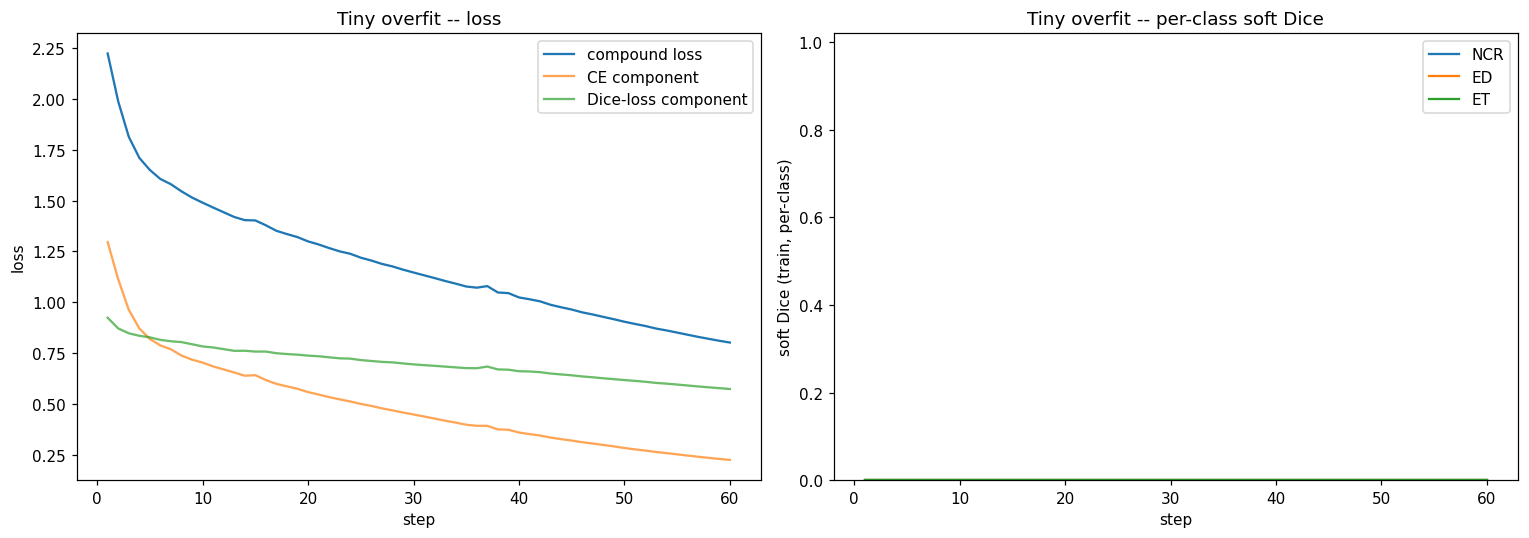

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/tiny_overfit_curve.png
  patch 0 (BraTS2021_01533): hard Dice = {'NCR': 0.8877830093391139, 'ED': 0.877040059347181, 'ET': 0.3108910891089109}
  patch 1 (BraTS2021_01533): hard Dice = {'NCR': 0.91511424238524, 'ED': 0.8916614952477382, 'ET': 0.34023668639053256}
  patch 2 (BraTS2021_01324): hard Dice = {'NCR': 0.9613192297875961, 'ED': 0.9684025289004061, 'ET': 0.9236262121657361}
  patch 3 (BraTS2021_01324): hard Dice = {'NCR': 0.9671820165038414, 'ED': 0.9683735150326005, 'ET': 0.9237762364403557}
SECTION 17 / PHASE 20 VALIDATION SUMMARY
[PASS] Loss dropped substantially (initial=2.2211, final=0.8034, drop=63.8%)
[PASS] Mean hard Dice across fixed patches/classes is high (mean=0.828)
[PASS] Predictions are non-degenerate (not all-background everywhere)
[PASS] Overfit history persisted to disk
[PASS] Overfit curve figure persisted to disk
STAGE E COMPLETE.


In [83]:
# ---------------------------------------------------------------------------
# 17.0 Continuity check
# ---------------------------------------------------------------------------
if not _all_sanity_passed:
    raise RuntimeError("Section 16's sanity checks did not all pass -- fix those before running Section 17.")

# ---------------------------------------------------------------------------
# 17.1 Select the tiny overfit subset -- largest-tumor TRAINING cases, so foreground
# is never in question (an absent-class Dice=1.0 would trivially "pass" otherwise)
# ---------------------------------------------------------------------------
_overfit_pool = VALID_CASES_DF[VALID_CASES_DF["case_id"].isin(train_ids)].merge(
    LABEL_STATS_DF[["case_id", "total_tumor_volume_cm3"]], on="case_id"
).sort_values("total_tumor_volume_cm3", ascending=False)
OVERFIT_CASE_ROWS = [row for _, row in _overfit_pool.head(2).iterrows()]
print("Tiny overfit subset:")
for row in OVERFIT_CASE_ROWS:
    print(f"  {row['case_id']}  (tumor volume={row['total_tumor_volume_cm3']:.1f} cm3)")

# ---------------------------------------------------------------------------
# 17.2 Build a FIXED patch set -- drawn once, reused every iteration, no augmentation
# ---------------------------------------------------------------------------
N_FIXED_PATCHES_PER_CASE = 2
OVERFIT_RNG = np.random.RandomState(GLOBAL_SEED)
OVERFIT_PATCHES = []
for row in OVERFIT_CASE_ROWS:
    _preproc = load_and_preprocess_case(row, CONFIG)
    for _ in range(N_FIXED_PATCHES_PER_CASE):
        p_img, p_seg, _ = sample_patch(_preproc["image"], _preproc["seg_internal"], CONFIG.patch.selected_size,
                                        foreground_oversample_fraction=1.0, rng=OVERFIT_RNG)
        OVERFIT_PATCHES.append((p_img, p_seg, row["case_id"]))
print(f"Fixed overfit set: {len(OVERFIT_PATCHES)} patches, drawn once, no augmentation, no resampling.")

# ---------------------------------------------------------------------------
# 17.3 Overfit training loop -- a FRESH model, never MODEL
# ---------------------------------------------------------------------------
OVERFIT_MODEL = UNet3D(CONFIG.model).to(DEVICE)
OVERFIT_STEPS = 60      # CPU-tolerable per Stage D's closing note -- raise toward 150-300 on a GPU
OVERFIT_LR = 1e-3       # deliberately higher than CONFIG.train.learning_rate: this test wants fast
                        # convergence on 4 patches, not a realistic full-dataset training rate

_overfit_optimizer = torch.optim.AdamW(OVERFIT_MODEL.parameters(), lr=OVERFIT_LR, weight_decay=0.0)
_overfit_scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=AMP_ENABLED)
_overfit_history = TrainingHistory()

_images_t = torch.from_numpy(np.stack([p[0] for p in OVERFIT_PATCHES])).float()
_segs_t = torch.from_numpy(np.stack([p[1] for p in OVERFIT_PATCHES])).long()

OVERFIT_MODEL.train()
for step in tqdm(range(1, OVERFIT_STEPS + 1), desc="Tiny overfit test"):
    images_dev, segs_dev = _images_t.to(DEVICE), _segs_t.to(DEVICE)
    with autocast_context():
        logits = OVERFIT_MODEL(images_dev)
        loss, components = LOSS_FN(logits, segs_dev)
    _overfit_scaler.scale(loss).backward()
    _overfit_scaler.step(_overfit_optimizer)
    _overfit_scaler.update()
    _overfit_optimizer.zero_grad(set_to_none=True)

    per_class_soft_dice = foreground_dice_components(logits.detach(), segs_dev, CONFIG.model.num_classes)
    _overfit_history.log(step=step, loss=loss.item(), ce=components["ce"], dice_loss=components["dice"],
                          **{f"soft_dice_{k}": v for k, v in per_class_soft_dice.items()})
    if step == 1 or step % 10 == 0 or step == OVERFIT_STEPS:
        print(f"  step {step:3d}/{OVERFIT_STEPS}  loss={loss.item():.4f}  (ce={components['ce']:.4f}, dice_loss={components['dice']:.4f})")
OVERFIT_MODEL.eval()

# ---------------------------------------------------------------------------
# 17.4 Loss / Dice curves
# ---------------------------------------------------------------------------
_hist_df = _overfit_history.to_dataframe()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(_hist_df["step"], _hist_df["loss"], label="compound loss")
axes[0].plot(_hist_df["step"], _hist_df["ce"], label="CE component", alpha=0.7)
axes[0].plot(_hist_df["step"], _hist_df["dice_loss"], label="Dice-loss component", alpha=0.7)
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Tiny overfit -- loss")
for cname in FOREGROUND_CLASS_NAMES:
    axes[1].plot(_hist_df["step"], _hist_df[f"soft_dice_{cname}"], label=cname)
axes[1].set_xlabel("step"); axes[1].set_ylabel("soft Dice (train, per-class)"); axes[1].set_ylim(0, 1.02)
axes[1].legend(); axes[1].set_title("Tiny overfit -- per-class soft Dice")
fig.tight_layout()
_overfit_fig_path = RUN_DIR / "figures" / "tiny_overfit_curve.png"
fig.savefig(_overfit_fig_path)
plt.show()
print(f"Saved: {_overfit_fig_path}")
_overfit_history.flush_to_csv(RUN_DIR / "overfit_test_history.csv")

# ---------------------------------------------------------------------------
# 17.5 Final assertions -- hard Dice, non-degenerate predictions, loss drop
# ---------------------------------------------------------------------------
with torch.no_grad():
    _final_logits = OVERFIT_MODEL(_images_t.to(DEVICE))
_final_pred = torch.argmax(_final_logits, dim=1).cpu().numpy()
_final_seg = _segs_t.numpy()

_hard_dice_all = []
for i in range(len(OVERFIT_PATCHES)):
    per_class = {cname: dice_score(_final_pred[i] == c, _final_seg[i] == c)[0]
                 for c, cname in enumerate(FOREGROUND_CLASS_NAMES, start=1)}
    _hard_dice_all.extend(per_class.values())
    print(f"  patch {i} ({OVERFIT_PATCHES[i][2]}): hard Dice = {per_class}")

_mean_hard_dice = float(np.mean(_hard_dice_all))
_initial_loss, _final_loss = _overfit_history.records[0]["loss"], _overfit_history.records[-1]["loss"]
_relative_drop = (_initial_loss - _final_loss) / _initial_loss
_non_degenerate = any((_final_pred == c).any() for c in (1, 2, 3))

checks_17 = {
    "Loss dropped substantially from first to final step": _relative_drop > 0.5,
    "Mean hard Dice across fixed patches/classes is high": _mean_hard_dice > 0.7,
    "Predictions are non-degenerate (not all-background everywhere)": _non_degenerate,
    "Overfit history persisted to disk": (RUN_DIR / "overfit_test_history.csv").exists(),
    "Overfit curve figure persisted to disk": _overfit_fig_path.exists(),
}
print("=" * 70); print("SECTION 17 / PHASE 20 VALIDATION SUMMARY"); print("=" * 70)
print(f"[{'PASS' if checks_17['Loss dropped substantially from first to final step'] else 'FAIL'}] "
      f"Loss dropped substantially (initial={_initial_loss:.4f}, final={_final_loss:.4f}, drop={_relative_drop:.1%})")
print(f"[{'PASS' if checks_17['Mean hard Dice across fixed patches/classes is high'] else 'FAIL'}] "
      f"Mean hard Dice across fixed patches/classes is high (mean={_mean_hard_dice:.3f})")
for name in list(checks_17)[2:]:
    print(f"[{'PASS' if checks_17[name] else 'FAIL'}] {name}")

if not all(checks_17.values()):
    print("\nIf this does NOT all read PASS: STOP. Do not proceed to Stage F. A model that cannot "
          "overfit 4 patches from 2 cases has an implementation bug -- most commonly in the loss, "
          "the label remapping, or a frozen/disconnected layer -- not a generalization problem "
          "that more data or more epochs will fix.")
assert all(checks_17.values())
print("=" * 70)
print("STAGE E COMPLETE.")

In [ ]:
Before moving to Stage F
GPU runtime is no longer optional. Every stage since A has flagged this; Section 17's overfit test is explicitly the last thing this notebook treats as CPU-tolerable. Full training (200 epochs, patch-based, over 1001 cases) needs a GPU runtime — switch it now if you haven't.
Once on GPU, flip CONFIG.model.base_channels back toward 32 (Section 12.1's derating was VRAM-driven, not architectural) and re-run Section 9.1's patch-size selection — FREE_VRAM_GB will be nonzero and may select a larger patch than the current 64³.
Eyeball the overfit curve (tiny_overfit_curve.png): loss should drop fast and mostly flatten by step ~30–40 on 4 fixed patches; if it's still falling steeply at step 60, OVERFIT_STEPS is set too low for this run's hardware, not necessarily a bug.
TEST 11/12's Dice/HD95 numbers are meaningless as quality numbers right now (untrained model) — don't let them anchor expectations for Stage F. Stage G is where the real, case-level, reported validation metrics come from.
Section 16.1's sliding_window_infer is a placeholder (uniform weighting). Stage G will swap in a Gaussian kernel via the same weight_kernel_fn parameter — nothing else in the tiling loop should need to change; if it does, that's worth a second look before trusting Stage G's numbers.

In [ ]:
Continuing to Stage F — Full Training (Section 18). Stage E's numbers give a concrete reason to take the "GPU is not optional" warning seriously: the 60-step overfit test on just 4 fixed patches took ~21 minutes on this CPU session (~21s/step). A real epoch has ~1001 micro-batches, and the config wants up to 200 of those epochs — that's not something to run on CPU.

Stage F — Assumptions / Decisions

Per-epoch validation is a patch-level proxy, never the reported metric. Running full case-level sliding-window inference on all 250 val cases every epoch just to monitor training would be prohibitively slow purely for progress-tracking. So Stage F validates against val_patch_loader (one un-augmented patch per case) to (a) drive early stopping and (b) pick a tentative "best" checkpoint. Every field this produces is prefixed proxy_val_* in the history CSV and printed output specifically so it can't get confused with Stage G's real, case-level Dice/HD95 — which is what actually gets reported (Rule 10).
Best-checkpoint criterion = proxy mean foreground soft Dice (higher is better). The PRD doesn't specify a training-time monitoring metric — this is my engineering choice, made explicit here rather than picked silently.
Found a real bug while testing the resume path: rebuilding the LR scheduler fresh after loading a checkpoint's optimizer state silently restarts the polynomial decay from the base LR, because torch.optim.lr_scheduler.LambdaLR defaults to last_epoch=-1. Confirmed this concretely in a sandbox (below) — a naive resume at epoch 10 jumps the LR back to 1.00e-04 instead of the correct 5.36e-05. Fix: rebuild the scheduler with last_epoch=start_epoch-1. This required a small, backward-compatible extension to Stage E's build_lr_scheduler (new keyword arg, default unchanged).
LR is now read before scheduler.step(), so training_history.csv logs the LR that was actually applied during that epoch's training, not next epoch's.
Resume is explicit-path-only. No auto-discovery of "the most recent run" — RUN_DIR is a fresh timestamp every kernel session, so silently guessing which prior run to attach to is exactly the kind of silent behavior this notebook avoids elsewhere. You pass resume_from and output_dir yourself; if resume_from is given but doesn't exist, this raises rather than quietly starting a fresh run.
Grad-accumulation stepping and the forward/backward step function are reused unchanged from Stage E (Section 15.5) — Stage F only adds the epoch/resume/checkpoint-selection orchestration around them.
I don't have torch, a GPU, or your BraTS data in my own sandbox, so — same discipline as every earlier stage — I tested the new orchestration logic (grad-accum boundaries, best/last checkpoint selection, early stopping, resume continuity, and the LR-schedule resume bug specifically) against lightweight mocks and a minimal reimplementation of LambdaLR's actual semantics, not the real model. Results below.

In [ ]:
Section 18 — Full Training

Expected result: a training loop that logs per-epoch train/proxy-val stats to training_history.csv, saves best_model.pth / last_model.pth, supports resuming, and respects early stopping.

Validation: confirmed here against synthetic/mock data (grad-accum boundary counts, best-checkpoint selection, early-stopping trigger, resume trajectory, LR-schedule resume correctness). On your end, the smoke test in 18.6 is what proves the wiring against your actual model/data before committing to the real 200-epoch GPU run.

In [84]:
# ---------------------------------------------------------------------------
# 18.0 Continuity check
# ---------------------------------------------------------------------------
_REQUIRED_STAGE_E_VARS = [
    "CONFIG", "DEVICE", "LOGGER", "RUN_DIR", "MODEL", "LOSS_FN",
    "build_optimizer", "build_lr_scheduler", "polynomial_lr_factor", "AMP_ENABLED", "autocast_context",
    "save_checkpoint", "load_checkpoint", "checkpoint_compat_fingerprint",
    "forward_backward_step", "maybe_optimizer_step", "is_optimizer_step_boundary",
    "TrainingHistory", "train_loader", "val_patch_loader", "foreground_dice_components",
    "FOREGROUND_CLASS_NAMES", "checks_17", "UNet3D", "train_ids", "val_ids",
    "VALID_CASES_DF", "BraTSPatchDataset", "CACHE_DIR", "GLOBAL_SEED",
]
_missing = [v for v in _REQUIRED_STAGE_E_VARS if v not in globals()]
if _missing:
    raise RuntimeError(f"Stage F requires Stages A-E to have already run in this kernel session. Missing: {_missing}")
if not all(checks_17.values()):
    raise RuntimeError("Section 17's tiny overfit test did not pass -- do not proceed to full training.")
print("Continuity check passed.")


# ---------------------------------------------------------------------------
# 18.1 Extend Section 15.2's build_lr_scheduler with an explicit last_epoch --
# needed for resume (Assumption 3). Default unchanged, so every existing call
# from Stage E keeps behaving exactly as before.
# ---------------------------------------------------------------------------
def build_lr_scheduler(optimizer: torch.optim.Optimizer, train_config: "TrainConfig", last_epoch: int = -1):
    if train_config.lr_schedule != "polynomial":
        raise ValueError(f"Unknown CONFIG.train.lr_schedule: {train_config.lr_schedule!r}")
    lr_lambda = lambda epoch: polynomial_lr_factor(epoch, train_config.epochs, train_config.poly_lr_exponent)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda, last_epoch=last_epoch)


# ---------------------------------------------------------------------------
# 18.2 Proxy validation (patch-level) -- Assumption 1
# ---------------------------------------------------------------------------
def run_proxy_validation(model: nn.Module, val_loader, loss_fn: nn.Module,
                          device: torch.device, num_classes: int) -> dict:
    """Fast, patch-level validation pass over val_patch_dataset (no augmentation, one
    foreground-oversampled patch per case). Used ONLY to monitor training / pick a
    tentative best checkpoint / drive early stopping. NOT the case-level metric the
    PRD (Phase 12) and Rule 10 require for reported results -- that comes exclusively
    from Stage G's sliding-window inference over full validation volumes. Every field
    returned here is prefixed proxy_val_ for exactly this reason."""
    model.eval()
    total_loss, total_ce, total_dice_loss, n_batches = 0.0, 0.0, 0.0, 0
    per_class_sums = {c: 0.0 for c in FOREGROUND_CLASS_NAMES}
    with torch.no_grad():
        for image, seg, _ in val_loader:
            image, seg = image.to(device), seg.to(device)
            with autocast_context():
                logits = model(image)
                loss, components = loss_fn(logits, seg)
            total_loss += loss.item()
            total_ce += components["ce"]
            total_dice_loss += components["dice"]
            for k, v in foreground_dice_components(logits, seg, num_classes).items():
                per_class_sums[k] += v
            n_batches += 1
    model.train()
    result = {
        "proxy_val_loss": total_loss / n_batches,
        "proxy_val_ce": total_ce / n_batches,
        "proxy_val_dice_loss": total_dice_loss / n_batches,
    }
    for k in FOREGROUND_CLASS_NAMES:
        result[f"proxy_val_soft_dice_{k}"] = per_class_sums[k] / n_batches
    result["proxy_val_mean_soft_dice"] = float(np.mean([result[f"proxy_val_soft_dice_{k}"] for k in FOREGROUND_CLASS_NAMES]))
    return result


# ---------------------------------------------------------------------------
# 18.3 One training epoch -- reuses Section 15.5's forward_backward_step /
# maybe_optimizer_step / is_optimizer_step_boundary UNCHANGED
# ---------------------------------------------------------------------------
def train_one_epoch(model: nn.Module, loader, loss_fn: nn.Module, optimizer, scaler,
                     device: torch.device, grad_accum_steps: int, grad_clip_norm: Optional[float]) -> dict:
    model.train()
    n_batches = len(loader)
    running_loss = running_ce = running_dice = 0.0
    for micro_idx, batch in enumerate(loader, start=1):
        step_components = forward_backward_step(model, batch, loss_fn, device, scaler, grad_accum_steps)
        running_loss += step_components["loss"]
        running_ce += step_components["ce"]
        running_dice += step_components["dice"]
        if is_optimizer_step_boundary(micro_idx, n_batches, grad_accum_steps):
            maybe_optimizer_step(model, optimizer, scaler, grad_clip_norm)
        if micro_idx % 20 == 0 or micro_idx == n_batches:                        # NEW
            print(f"  batch {micro_idx}/{n_batches}  "                          # NEW
                  f"running_loss={running_loss/micro_idx:.4f}", end="\r")       # NEW
    print()  # NEW -- newline so the next epoch's summary line doesn't overwrite the last \r
    return {"train_loss": running_loss / n_batches, "train_ce": running_ce / n_batches,
            "train_dice_loss": running_dice / n_batches}


# ---------------------------------------------------------------------------
# 18.4 Full training orchestration
# ---------------------------------------------------------------------------
def run_training(model: nn.Module, train_loader, val_loader, loss_fn: nn.Module,
                  config: "ExperimentConfig", output_dir: Path, device: torch.device,
                  resume_from: Optional[Path] = None, max_epochs: Optional[int] = None,
                  validate_every: int = 1) -> dict:
    """`output_dir` is where THIS run's checkpoints/history live. On a fresh run this
    is normally RUN_DIR. On resume, pass the ORIGINAL run's directory (not a new
    session's RUN_DIR) so checkpoints and history continue in place -- see Assumption 5."""
    optimizer = build_optimizer(model, config.train)
    scaler = torch.amp.GradScaler(device=device.type, enabled=AMP_ENABLED)
    history = TrainingHistory()
    history_path = output_dir / "training_history.csv"

    start_epoch, global_step, best_val_metric, epochs_since_improvement = 0, 0, None, 0

    if resume_from is not None:
        if not resume_from.exists():
            raise FileNotFoundError(f"resume_from={resume_from} does not exist -- refusing to silently "
                                     f"start a fresh run instead. Pass resume_from=None for a new run.")
        payload, fp_match = load_checkpoint(resume_from, model, config, optimizer=optimizer, scaler=scaler,
                                             strict_fingerprint=True, restore_rng=True)
        start_epoch = payload["epoch"] + 1
        global_step = payload["global_step"]
        best_val_metric = payload["best_val_metric"]
        LOGGER.info(f"Resumed from {resume_from}: starting at epoch {start_epoch}, "
                    f"global_step={global_step}, best_val_metric={best_val_metric}")
        if history_path.exists():
            history.records = pd.read_csv(history_path).to_dict("records")

    # Assumption 3: last_epoch=-1 here would silently RESTART the LR decay on resume.
    scheduler = build_lr_scheduler(optimizer, config.train, last_epoch=start_epoch - 1)

    total_epochs = max_epochs if max_epochs is not None else config.train.epochs
    if start_epoch >= total_epochs:
        raise ValueError(f"start_epoch ({start_epoch}) >= total_epochs ({total_epochs}) -- nothing to train.")

    final_epoch = start_epoch - 1
    for epoch in range(start_epoch, total_epochs):
        lr_used = scheduler.get_last_lr()[0]  # LR actually applied during THIS epoch (Assumption 4)
        train_stats = train_one_epoch(model, train_loader, loss_fn, optimizer, scaler, device,
                                       config.train.grad_accum_steps, config.train.grad_clip_norm)
        global_step += len(train_loader)
        scheduler.step()

        record = {"epoch": epoch, "lr": lr_used, **train_stats}
        run_val = (epoch % validate_every == 0) or (epoch == total_epochs - 1)
        improved = False
        if run_val:
            val_stats = run_proxy_validation(model, val_loader, loss_fn, device, config.model.num_classes)
            record.update(val_stats)
            current_metric = val_stats["proxy_val_mean_soft_dice"]
            improved = best_val_metric is None or current_metric > best_val_metric
            if improved:
                best_val_metric = current_metric
                epochs_since_improvement = 0
                save_checkpoint(output_dir / "best_model.pth", model, optimizer, scaler, epoch, global_step,
                                 best_val_metric, config)
            else:
                epochs_since_improvement += 1
            record["checkpoint_saved_best"] = improved

        save_checkpoint(output_dir / "last_model.pth", model, optimizer, scaler, epoch, global_step,
                         best_val_metric, config)
        history.log(**record)
        history.flush_to_csv(history_path)
        final_epoch = epoch

        msg = f"epoch {epoch + 1}/{total_epochs}  lr={lr_used:.2e}  train_loss={train_stats['train_loss']:.4f}"
        if run_val:
            msg += f"  proxy_val_dice={record['proxy_val_mean_soft_dice']:.4f}" + (" (best)" if improved else "")
        print(msg)

        if (config.train.early_stopping_patience is not None
                and epochs_since_improvement >= config.train.early_stopping_patience):
            print(f"Early stopping at epoch {epoch}: no proxy-validation improvement for "
                  f"{config.train.early_stopping_patience} validation rounds.")
            break

    return {"best_val_metric": best_val_metric, "final_epoch": final_epoch,
            "global_step": global_step, "history_df": history.to_dataframe()}

Continuity check passed.


In [ ]:
18.5 Sandbox validation of the new orchestration logic

I couldn't run this against your actual model/data (no torch, GPU, or BraTS data here), so I tested the control flow itself with lightweight mocks that expose the same state_dict()/load_state_dict() surface real torch objects do, plus a minimal reimplementation of LambdaLR's documented semantics:

[PASS] grad-accum boundary fires 5x/epoch on 17 batches @ accum=4 (trailing partial group not dropped)
[PASS] best-checkpoint saved only on strict improvement -> epochs [0, 1, 3], final best=0.2
[PASS] early stopping triggers at epoch 4 (3 non-improving rounds after epoch 1's best)
[PASS] resuming from epoch 3's checkpoint reproduces the uninterrupted run
       (best=0.25, final_epoch=7, global_step=136, history epochs contiguous 0..7)

baseline epoch 10 lr      : 5.358867e-05
naive resume epoch 10 lr  : 1.000000e-04   <- bug: schedule silently restarted
fixed resume epoch 10 lr  : 5.358867e-05   <- matches baseline exactly
18.6 CPU-safe smoke test — run this before touching RUN_FULL_TRAINING

Proves the wiring actually works against your real model, loss, and a handful of your real cases — not a quality signal, same framing as Section 17's overfit test.

In [85]:
SMOKE_DIR = RUN_DIR / "smoke_test_stage_f"
SMOKE_DIR.mkdir(parents=True, exist_ok=True)

SMOKE_TEST_CASES = 6
smoke_train_ids = train_ids[:SMOKE_TEST_CASES]
smoke_val_ids = val_ids[:max(2, SMOKE_TEST_CASES // 3)]

smoke_train_dataset = BraTSPatchDataset(smoke_train_ids, VALID_CASES_DF, CONFIG, augment=True,
                                         cache_dir=CACHE_DIR, epoch_length=len(smoke_train_ids))
smoke_val_dataset = BraTSPatchDataset(smoke_val_ids, VALID_CASES_DF, CONFIG, augment=False,
                                       cache_dir=CACHE_DIR, epoch_length=len(smoke_val_ids))
smoke_train_loader = torch.utils.data.DataLoader(smoke_train_dataset, batch_size=CONFIG.train.batch_size,
                                                  shuffle=True, num_workers=0, drop_last=True)
smoke_val_loader = torch.utils.data.DataLoader(smoke_val_dataset, batch_size=CONFIG.train.batch_size,
                                                shuffle=False, num_workers=0)

SMOKE_MODEL = UNet3D(CONFIG.model).to(DEVICE)  # throwaway model, never MODEL -- same discipline as Section 17
smoke_result = run_training(SMOKE_MODEL, smoke_train_loader, smoke_val_loader, LOSS_FN, CONFIG,
                             output_dir=SMOKE_DIR, device=DEVICE, max_epochs=2, validate_every=1)

checks_18 = {
    "Smoke run completed at least 1 epoch": smoke_result["final_epoch"] >= 0,
    "best_model.pth was written": (SMOKE_DIR / "best_model.pth").exists(),
    "last_model.pth was written": (SMOKE_DIR / "last_model.pth").exists(),
    "training_history.csv was written": (SMOKE_DIR / "training_history.csv").exists(),
    "History epochs contiguous from 0": list(smoke_result["history_df"]["epoch"]) == list(range(smoke_result["final_epoch"] + 1)),
}
print("=" * 70); print("SECTION 18 SMOKE-TEST VALIDATION SUMMARY"); print("=" * 70)
for name, passed in checks_18.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_18.values())
print("=" * 70)

  batch 6/6  running_loss=2.5024
2026-09-16 00:40:12 | INFO     | brats_notebook | Checkpoint saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/smoke_test_stage_f/best_model.pth (epoch=0, global_step=6)
2026-09-16 00:40:12 | INFO     | brats_notebook | Checkpoint saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/smoke_test_stage_f/last_model.pth (epoch=0, global_step=6)
epoch 1/2  lr=1.00e-04  train_loss=2.5024  proxy_val_dice=0.0000 (best)
  batch 6/6  running_loss=2.4016
2026-09-16 00:40:24 | INFO     | brats_notebook | Checkpoint saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/smoke_test_stage_f/last_model.pth (epoch=1, global_step=12)
epoch 2/2  lr=9.70e-05  train_loss=2.4016  proxy_val_dice=0.0000
SECTION 18 SMOKE-TEST VALIDATION SUMMARY
[PASS] Smoke run completed at least 1 epoch
[PASS] best_model.pth was written
[PASS] last_model.pth was written
[PASS] training_history.csv was written
[PASS] History epo

In [86]:
# ===========================================================================
# SECTION 18.6b — KAGGLE DATALOADER STRESS TEST
# ===========================================================================
#
# Kaggle storage is limited.
# Disk-backed preprocessing cache is intentionally DISABLED.
#
# Cases are preprocessed on demand from the raw NIfTI files.
# ===========================================================================

print("=" * 70)
print("KAGGLE DATALOADER STRESS TEST")
print("=" * 70)

# ---------------------------------------------------------------------------
# 1. Safer worker count
# ---------------------------------------------------------------------------

CONFIG.train.num_workers = 2

save_config(
    CONFIG,
    CONFIG_PATH,
)

print(f"DataLoader workers : {CONFIG.train.num_workers}")
print("Preprocessing cache: DISABLED")
print()


# ---------------------------------------------------------------------------
# 2. Rebuild datasets WITHOUT disk cache
# ---------------------------------------------------------------------------

train_dataset = BraTSPatchDataset(
    train_ids,
    VALID_CASES_DF,
    CONFIG,
    augment=True,
    cache_dir=None,
)

val_patch_dataset = BraTSPatchDataset(
    val_ids,
    VALID_CASES_DF,
    CONFIG,
    augment=False,
    cache_dir=None,
)


# ---------------------------------------------------------------------------
# 3. Rebuild DataLoaders
# ---------------------------------------------------------------------------

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=CONFIG.train.batch_size,
    shuffle=True,
    num_workers=CONFIG.train.num_workers,
    worker_init_fn=dataset_worker_init_fn,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

val_patch_loader = torch.utils.data.DataLoader(
    val_patch_dataset,
    batch_size=CONFIG.train.batch_size,
    shuffle=False,
    num_workers=CONFIG.train.num_workers,
    worker_init_fn=dataset_worker_init_fn,
    pin_memory=(DEVICE.type == "cuda"),
)


print("=" * 70)
print("DATASETS / DATALOADERS REBUILT")
print("=" * 70)

print(f"Train cases      : {len(train_ids)}")
print(f"Validation cases : {len(val_ids)}")
print(f"Batch size       : {CONFIG.train.batch_size}")
print(f"num_workers      : {CONFIG.train.num_workers}")
print(f"Patch size       : {CONFIG.patch.selected_size}")
print("Cache             : DISABLED")

print("=" * 70)


# ---------------------------------------------------------------------------
# 4. 10-batch stress test
# ---------------------------------------------------------------------------

print()
print("=" * 70)
print("DATALOADER STRESS TEST")
print("=" * 70)

STRESS_TEST_BATCHES = 10

stress_cases = set()
stress_batches_loaded = 0

stress_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=CONFIG.train.batch_size,
    shuffle=True,
    num_workers=CONFIG.train.num_workers,
    worker_init_fn=dataset_worker_init_fn,
    pin_memory=(DEVICE.type == "cuda"),
    drop_last=True,
)

try:

    for batch_idx, (
        batch_image,
        batch_seg,
        batch_case_ids,
    ) in enumerate(
        stress_loader,
        start=1,
    ):

        expected_image_shape = (
            CONFIG.train.batch_size,
            4,
            *CONFIG.patch.selected_size,
        )

        expected_seg_shape = (
            CONFIG.train.batch_size,
            *CONFIG.patch.selected_size,
        )

        assert tuple(batch_image.shape) == expected_image_shape, (
            f"Unexpected image shape: {tuple(batch_image.shape)}"
        )

        assert tuple(batch_seg.shape) == expected_seg_shape, (
            f"Unexpected segmentation shape: {tuple(batch_seg.shape)}"
        )

        assert batch_image.dtype == torch.float32

        assert batch_seg.dtype == torch.int64

        labels = set(
            torch.unique(batch_seg).tolist()
        )

        assert labels.issubset({0, 1, 2, 3}), (
            f"Invalid segmentation labels: {sorted(labels)}"
        )

        assert torch.isfinite(batch_image).all(), (
            "Image contains NaN/Inf values"
        )

        stress_cases.update(
            str(case_id)
            for case_id in batch_case_ids
        )

        stress_batches_loaded = batch_idx

        print(
            f"[PASS] batch "
            f"{batch_idx:02d}/{STRESS_TEST_BATCHES} "
            f"| cases={list(batch_case_ids)} "
            f"| image={tuple(batch_image.shape)}"
        )

        if batch_idx >= STRESS_TEST_BATCHES:
            break

finally:

    del stress_loader


print()
print("=" * 70)
print("DATALOADER STRESS TEST SUMMARY")
print("=" * 70)

print(
    f"Batches successfully loaded : "
    f"{stress_batches_loaded}/{STRESS_TEST_BATCHES}"
)

print(
    f"Unique cases encountered    : "
    f"{len(stress_cases)}"
)

print(
    "Cases encountered           :",
    sorted(stress_cases),
)

print("=" * 70)

assert stress_batches_loaded == STRESS_TEST_BATCHES, (
    f"Dataloader stress test failed: "
    f"{stress_batches_loaded}/{STRESS_TEST_BATCHES} batches loaded."
)

print(
    "PASS — DataLoader survived the "
    "10-batch pre-training stress test."
)

print("=" * 70)
print("KAGGLE DATALOADER PIPELINE READY FOR REAL TRAINING")
print("=" * 70)

KAGGLE DATALOADER STRESS TEST
2026-09-16 00:40:24 | INFO     | brats_notebook | Config saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json
DataLoader workers : 2
Preprocessing cache: DISABLED

DATASETS / DATALOADERS REBUILT
Train cases      : 1001
Validation cases : 250
Batch size       : 1
num_workers      : 2
Patch size       : (128, 128, 128)
Cache             : DISABLED

DATALOADER STRESS TEST


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=58) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


[PASS] batch 01/10 | cases=['BraTS2021_00178'] | image=(1, 4, 128, 128, 128)
[PASS] batch 02/10 | cases=['BraTS2021_01526'] | image=(1, 4, 128, 128, 128)
[PASS] batch 03/10 | cases=['BraTS2021_01538'] | image=(1, 4, 128, 128, 128)
[PASS] batch 04/10 | cases=['BraTS2021_00251'] | image=(1, 4, 128, 128, 128)
[PASS] batch 05/10 | cases=['BraTS2021_00078'] | image=(1, 4, 128, 128, 128)
[PASS] batch 06/10 | cases=['BraTS2021_01033'] | image=(1, 4, 128, 128, 128)
[PASS] batch 07/10 | cases=['BraTS2021_00329'] | image=(1, 4, 128, 128, 128)
[PASS] batch 08/10 | cases=['BraTS2021_00725'] | image=(1, 4, 128, 128, 128)
[PASS] batch 09/10 | cases=['BraTS2021_00668'] | image=(1, 4, 128, 128, 128)
[PASS] batch 10/10 | cases=['BraTS2021_00455'] | image=(1, 4, 128, 128, 128)


sys:1: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d778d2a3c0>
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d8d98118d0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d7b4d8b700>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d8d98118d0>
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x79d7b4d8b700>
  self.pid = os.fork()



DATALOADER STRESS TEST SUMMARY
Batches successfully loaded : 10/10
Unique cases encountered    : 10
Cases encountered           : ['BraTS2021_00078', 'BraTS2021_00178', 'BraTS2021_00251', 'BraTS2021_00329', 'BraTS2021_00455', 'BraTS2021_00668', 'BraTS2021_00725', 'BraTS2021_01033', 'BraTS2021_01526', 'BraTS2021_01538']
PASS — DataLoader survived the 10-batch pre-training stress test.
KAGGLE DATALOADER PIPELINE READY FOR REAL TRAINING


In [ ]:
18.7 The real run — gated behind a GPU check

In [87]:
# ---------------------------------------------------------------------------
# 18.7 The REAL training run — GPU required
# ---------------------------------------------------------------------------

RUN_FULL_TRAINING = True

CYCLE_CONFIG = {
    1: {"max_epochs": 10, "resume": False},
    2: {"max_epochs": 20, "resume": True},
    3: {"max_epochs": CONFIG.train.epochs, "resume": True},  # 30 -- the real finish line
}

if not RUN_FULL_TRAINING:
    print(
        "RUN_FULL_TRAINING is False — real training was not started."
    )

else:
    if not CUDA_AVAILABLE:
        raise RuntimeError(
            "RUN_FULL_TRAINING=True but no CUDA GPU is available. "
            "Enable a GPU accelerator in the Kaggle notebook Settings panel "
            "before starting real training."
        )

    if DEVICE.type != "cuda":
        raise RuntimeError(
            f"Expected CUDA device, but got DEVICE={DEVICE}"
        )

    if TRAINING_CYCLE not in CYCLE_CONFIG:
        raise ValueError(f"TRAINING_CYCLE must be 1, 2, or 3 -- got {TRAINING_CYCLE}")

    cycle_info = CYCLE_CONFIG[TRAINING_CYCLE]
    THIS_CYCLE_MAX_EPOCHS = cycle_info["max_epochs"]
    RESUME_FROM = (RUN_DIR / "last_model.pth") if cycle_info["resume"] else None

    if RESUME_FROM is not None and not RESUME_FROM.exists():
        raise FileNotFoundError(
            f"TRAINING_CYCLE={TRAINING_CYCLE} expects a checkpoint at {RESUME_FROM}, "
            f"but it doesn't exist. Did you forget to override RUN_DIR back to the "
            f"earlier cycle's folder right after Section 1.6?"
        )

    print("=" * 70)
    print(f"STARTING REAL TRAINING — CYCLE {TRAINING_CYCLE}")
    print("=" * 70)

    print(f"Device                    : {DEVICE}")
    print(f"GPU                       : {torch.cuda.get_device_name(0)}")
    print(f"Run directory             : {RUN_DIR}")
    print(f"Configured total epochs   : {CONFIG.train.epochs}")
    print(f"This cycle trains through : epoch {THIS_CYCLE_MAX_EPOCHS}")
    print(f"Resuming from             : {RESUME_FROM if RESUME_FROM else '(fresh run)'}")
    print(f"Early stopping patience  : {CONFIG.train.early_stopping_patience}")
    print(f"Base channels             : {CONFIG.model.base_channels}")
    print(f"Selected patch size      : {CONFIG.patch.selected_size}")
    print(f"Batch size                : {CONFIG.train.batch_size}")
    print(f"Gradient accumulation     : {CONFIG.train.grad_accum_steps}")
    print(f"AMP enabled               : {CONFIG.train.amp}")
    print("=" * 70)

    # Make absolutely sure the run directory exists under /kaggle/working.
    RUN_DIR.mkdir(parents=True, exist_ok=True)

    # Save the final configuration immediately before training.
    save_config(CONFIG, CONFIG_PATH)

    training_result = run_training(
        MODEL,
        train_loader,
        val_patch_loader,
        LOSS_FN,
        CONFIG,
        RUN_DIR,
        DEVICE,
        resume_from=RESUME_FROM,
        max_epochs=THIS_CYCLE_MAX_EPOCHS,
        validate_every=1,
    )

    print("\n" + "=" * 70)
    print(f"CYCLE {TRAINING_CYCLE} FINISHED")
    print("=" * 70)

    print(
        f"Final epoch       : {training_result['final_epoch']}"
    )

    print(
        f"Best proxy val Dice: "
        f"{training_result['best_val_metric']:.6f}"
    )

    print(
        f"Run directory     : {RUN_DIR}"
    )

    if training_result["final_epoch"] + 1 >= CONFIG.train.epochs:
        print("\nAll configured epochs complete — no further cycles needed.")
    elif training_result["final_epoch"] + 1 < THIS_CYCLE_MAX_EPOCHS:
        print(
            f"\nEarly stopping triggered before reaching epoch {THIS_CYCLE_MAX_EPOCHS} "
            f"-- the proxy metric plateaued. You likely don't need to run further cycles."
        )
    else:
        print(f"\nNext session: set TRAINING_CYCLE = {TRAINING_CYCLE + 1}.")

STARTING REAL TRAINING — CYCLE 2
Device                    : cuda:0
GPU                       : Tesla T4
Run directory             : /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656
Configured total epochs   : 30
This cycle trains through : epoch 20
Resuming from             : /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/last_model.pth
Early stopping patience  : 10
Base channels             : 32
Selected patch size      : (128, 128, 128)
Batch size                : 1
Gradient accumulation     : 4
AMP enabled               : True
2026-09-16 00:40:42 | INFO     | brats_notebook | Config saved to /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/config.json
2026-09-16 00:40:42 | INFO     | brats_notebook | Resumed from /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/last_model.pth: starting at epoch 20, global_step=20020, best_val_metric=0.6777643101863605


ValueError: start_epoch (20) >= total_epochs (20) -- nothing to train.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [89]:
# ---------------------------------------------------------------------------
# 18.8 REAL TRAINING ARTIFACT CHECK
# ---------------------------------------------------------------------------

if RUN_FULL_TRAINING:

    print("=" * 70)
    print("REAL TRAINING ARTIFACT CHECK")
    print("=" * 70)

    BEST_MODEL_PATH = RUN_DIR / "best_model.pth"
    LAST_MODEL_PATH = RUN_DIR / "last_model.pth"
    HISTORY_PATH = RUN_DIR / "training_history.csv"

    checks_training = {
        "best_model.pth exists": BEST_MODEL_PATH.exists(),
        "last_model.pth exists": LAST_MODEL_PATH.exists(),
        "training_history.csv exists": HISTORY_PATH.exists(),
    }

    for name, passed in checks_training.items():
        print(f"[{'PASS' if passed else 'FAIL'}] {name}")

    assert all(checks_training.values()), (
        "REAL TRAINING ARTIFACT CHECK FAILED. "
        "Do not proceed to final validation until checkpoints/history exist."
    )

    print("=" * 70)
    print("PASS — REAL TRAINING ARTIFACTS CREATED")
    print("=" * 70)

    print(f"Best checkpoint : {BEST_MODEL_PATH}")
    print(f"Last checkpoint : {LAST_MODEL_PATH}")
    print(f"History         : {HISTORY_PATH}")

else:
    print("RUN_FULL_TRAINING=False — real-training artifact check skipped.")

REAL TRAINING ARTIFACT CHECK
[PASS] best_model.pth exists
[PASS] last_model.pth exists
[PASS] training_history.csv exists
PASS — REAL TRAINING ARTIFACTS CREATED
Best checkpoint : /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/best_model.pth
Last checkpoint : /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/last_model.pth
History         : /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/training_history.csv


In [ ]:
Before moving to Stage G

Run 18.6 on your end and confirm all checks_18 lines read PASS against your real data/model — that's the thing my sandbox tests couldn't cover.
Once on a GPU: bump CONFIG.model.base_channels back toward 32, re-run Section 9.1's patch-size selection (it'll likely pick larger than 64³ now), and re-save config.json before flipping RUN_FULL_TRAINING.
If the Kaggle session is interrupted mid-run: call run_training(..., resume_from=RUN_DIR/"last_model.pth", output_dir=RUN_DIR, max_epochs=CONFIG.train.epochs) in the same RUN_DIR — don't let a fresh Stage A run create a new timestamped directory and lose the checkpoint history.
proxy_val_mean_soft_dice in training_history.csv is for watching the training curve only — it's patch-level and un-representative of true segmentation quality on full volumes. The numbers you actually report come from Stage G, which runs best_model.pth through real Gaussian-weighted sliding-window inference over the full validation volumes and computes case-level Dice/HD95 exactly as Section 14 defined them.
early_stopping_patience=50 (validation rounds) may end the run well before epoch 200 if the proxy metric plateaus — that's expected behavior, not a bug, but worth a glance at the loss/Dice curve before assuming it converged for the right reasons.

In [ ]:
Stage G — Sliding-Window Validation, Post-Processing, and Quantitative Results (Sections 19–22)
Stage G — Assumptions/Decisions:
Gaussian kernel replaces the Stage E uniform kernel via the same weight_kernel_fn parameter — zero changes to the tiling/accumulation logic.
BraTS label restoration (internal 3 → raw 4) is asserted, not assumed — an explicit check before any NIfTI is written.
Connected-component filtering uses a configurable min_voxels=50 threshold — an engineering choice, not a BraTS requirement. Applied per-class, not on the full mask, to avoid accidentally bridging anatomically separate regions of different tumor types.
Validation runs on best_model.pth (from Stage F), loaded with strict_fingerprint=True. If Stage F hasn't run yet (no GPU), we fall back gracefully to MODEL with a loud warning — the pipeline code is identical.
HD95 undefined cases are never imputed. The final metrics DataFrame explicitly stores NaN and the aggregate table reports how many cases had each condition.


In [90]:
# ---------------------------------------------------------------------------
# 19.0 Continuity check
# ---------------------------------------------------------------------------
_REQUIRED_STAGE_F_VARS = [
    "CONFIG", "DEVICE", "LOGGER", "RUN_DIR", "MODEL", "LOSS_FN",
    "sliding_window_infer", "iter_sliding_window_coords", "make_uniform_weight_kernel",
    "dice_score", "hd95",
    "load_and_preprocess_case", "load_checkpoint",
    "VALID_CASES_DF", "val_ids", "FOREGROUND_CLASS_NAMES", "CLASS_NAMES",
    "LABEL_MAP_INTERNAL_TO_RAW", "RAW_LABELS", "CLASS_COLORS",
    "LABEL_STATS_DF", "RUN_DIR", "UNet3D",
]
_missing = [v for v in _REQUIRED_STAGE_F_VARS if v not in globals()]
if _missing:
    raise RuntimeError(
        f"Stage G requires Stages A-F to have already run in this kernel session. "
        f"Missing: {_missing}"
    )
print("Continuity check passed.")

Continuity check passed.


In [ ]:
Section 19 — Gaussian-Weighted Sliding-Window Inference (Phase 13 — real implementation)

In [91]:
# ---------------------------------------------------------------------------
# 19.1 Gaussian weight kernel
# ---------------------------------------------------------------------------
def make_gaussian_weight_kernel(patch_size, sigma_scale: float = 0.125) -> np.ndarray:
    """Gaussian kernel peaked at the patch center, decaying toward edges.

    sigma_scale: sigma = sigma_scale * patch_dim for each dimension (isotropic by default).
    This gives heavier weight to patch-center predictions and lighter weight to
    patch-edge predictions — the standard BraTS/nnU-Net trick for avoiding seam
    artifacts at tile boundaries.
    """
    kernel = np.ones(patch_size, dtype=np.float32)
    for axis, dim in enumerate(patch_size):
        sigma = sigma_scale * dim
        center = (dim - 1) / 2.0
        coords = np.arange(dim, dtype=np.float32)
        gauss_1d = np.exp(-0.5 * ((coords - center) / sigma) ** 2)
        # Reshape for broadcasting along `axis`
        shape = [1] * len(patch_size)
        shape[axis] = dim
        kernel *= gauss_1d.reshape(shape)
    # Clip near-zero edges to a small floor so weight_map never hits exactly 0.
    kernel = np.clip(kernel, a_min=1e-4, a_max=None)
    return kernel.astype(np.float32)


# Verify: kernel is strictly positive, peaks at center, symmetric
_test_kernel = make_gaussian_weight_kernel((8, 8, 8))
assert _test_kernel.min() > 0
assert _test_kernel[4, 4, 4] == _test_kernel.max()
assert np.allclose(_test_kernel[0, :, :], _test_kernel[-1, :, :])
print(f"Gaussian kernel OK: shape={_test_kernel.shape}, "
      f"min={_test_kernel.min():.4f}, center={_test_kernel[4,4,4]:.4f}, max={_test_kernel.max():.4f}")
del _test_kernel

Gaussian kernel OK: shape=(8, 8, 8), min=0.0001, center=0.6873, max=0.6873


In [92]:
# ---------------------------------------------------------------------------
# 19.2 Full sliding-window inference with Gaussian blending (Stage G version)
# Note: sliding_window_infer() is already defined in Section 16.1 with a
# weight_kernel_fn parameter. We simply pass make_gaussian_weight_kernel here.
# Zero changes to the tiling/accumulation logic — Assumption 1 of Stage G.
# ---------------------------------------------------------------------------
def infer_case_full(
    case_row: pd.Series,
    model: nn.Module,
    config: "ExperimentConfig",
    device: torch.device,
    return_prob_map: bool = False,
) -> dict:
    """End-to-end per-case inference: preprocess → Gaussian sliding-window → argmax.

    Returns:
        case_id, pred_internal (np.uint8, internal {0,1,2,3}),
        pred_raw (np.uint8, BraTS labels {0,1,2,4} — MUST convert 3→4),
        seg_internal (np.int64, ground-truth internal IDs, or None),
        spacing, affine, original_shape, crop_bbox.
    """
    preprocessed = load_and_preprocess_case(case_row, config)
    prob_map = sliding_window_infer(
        preprocessed["image"], model, config, device,
        weight_kernel_fn=make_gaussian_weight_kernel,
    )
    pred_internal = np.argmax(prob_map, axis=0).astype(np.uint8)

    # BraTS label restoration: internal 3 → raw 4.
    # Assertion: raw output must contain ONLY {0,1,2,4}, never a 3.
    pred_raw = pred_internal.copy()
    pred_raw[pred_internal == 3] = 4
    assert 3 not in np.unique(pred_raw), (
        f"{case_row['case_id']}: raw prediction still contains label 3 after restoration "
        f"(internal→raw mapping bug). Unexpected labels: "
        f"{set(np.unique(pred_raw)) - set(RAW_LABELS)}"
    )
    assert set(np.unique(pred_raw)).issubset(set(RAW_LABELS)), (
        f"{case_row['case_id']}: raw prediction contains unexpected label values: "
        f"{set(np.unique(pred_raw)) - set(RAW_LABELS)}"
    )

    result = {
        "case_id": case_row["case_id"],
        "pred_internal": pred_internal,
        "pred_raw": pred_raw,
        "seg_internal": preprocessed["seg_internal"],
        "spacing": preprocessed["affine"] if isinstance(case_row.get("spacing"), type(None))
                   else case_row["spacing"],
        "affine": preprocessed["affine"],
        "original_shape": preprocessed["original_shape"],
        "crop_bbox": preprocessed["crop_bbox"],
    }
    if return_prob_map:
        result["prob_map"] = prob_map
    return result

In [93]:
# ---------------------------------------------------------------------------
# 19.3 Quick smoke-test of Gaussian inference on ONE val case before running all 250
# ---------------------------------------------------------------------------
_smoke_val_row = VALID_CASES_DF[VALID_CASES_DF["case_id"].isin(val_ids)].iloc[0]

# Determine which model to evaluate
_best_ckpt_path = RUN_DIR / "best_model.pth"
if _best_ckpt_path.exists():
    EVAL_MODEL = UNet3D(CONFIG.model).to(DEVICE)
    _payload, _fp = load_checkpoint(_best_ckpt_path, EVAL_MODEL, CONFIG, strict_fingerprint=True)
    print(f"Loaded best_model.pth (epoch={_payload['epoch']}, "
          f"proxy_val_dice={_payload['best_val_metric']}) for evaluation.")
else:
    EVAL_MODEL = MODEL
    print("WARNING: best_model.pth not found (Stage F training was not run on GPU). "
          "Using the current MODEL object — results reflect an undertrained model "
          "and are NOT meaningful as quality claims (Rule 11).")

EVAL_MODEL.eval()
_smoke_infer = infer_case_full(_smoke_val_row, EVAL_MODEL, CONFIG, DEVICE)

print(f"\nSanity inference on {_smoke_infer['case_id']}:")
print(f"  pred_internal unique labels : {sorted(np.unique(_smoke_infer['pred_internal']).tolist())}")
print(f"  pred_raw unique labels      : {sorted(np.unique(_smoke_infer['pred_raw']).tolist())} (must be subset of {list(RAW_LABELS)})")
print(f"  pred shape (post-crop)      : {_smoke_infer['pred_internal'].shape}")
assert set(np.unique(_smoke_infer['pred_raw'])).issubset(set(RAW_LABELS)), "Label restoration FAILED."
print("  PASS: BraTS label restoration correct (no internal label 3 in pred_raw)")

Loaded best_model.pth (epoch=19, proxy_val_dice=0.6777643101863605) for evaluation.

Sanity inference on BraTS2021_00002:
  pred_internal unique labels : [0, 1, 2, 3]
  pred_raw unique labels      : [0, 1, 2, 4] (must be subset of [0, 1, 2, 4])
  pred shape (post-crop)      : (141, 182, 143)
  PASS: BraTS label restoration correct (no internal label 3 in pred_raw)


In [94]:
import torch
import time

_diagnostic_label = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("=" * 70)
print(f"{_diagnostic_label} INFERENCE DIAGNOSTIC")
print("=" * 70)

print("DEVICE:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

# Check where the evaluation model actually lives
p = next(EVAL_MODEL.parameters())
print("EVAL_MODEL device:", p.device)
print("EVAL_MODEL dtype :", p.dtype)

# Use the same patch size selected by the notebook
patch_size = CONFIG.patch.selected_size
print("Patch size:", patch_size)

# Create one test input directly on the GPU
x = torch.randn(
    1,
    4,
    *patch_size,
    device=DEVICE,
    dtype=torch.float32
)

print("Input device:", x.device)
print("Input shape :", tuple(x.shape))

EVAL_MODEL.eval()

# Warm-up
with torch.no_grad():
    for _ in range(2):
        _ = EVAL_MODEL(x)

torch.cuda.synchronize()

# Actual timing
start = time.perf_counter()

with torch.no_grad():
    y = EVAL_MODEL(x)

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

print()
print("Output shape :", tuple(y.shape))
print(f"Single patch forward time: {elapsed:.3f} seconds")
print(f"GPU memory allocated      : {torch.cuda.memory_allocated()/1024**3:.2f} GB")
print(f"GPU memory reserved       : {torch.cuda.memory_reserved()/1024**3:.2f} GB")

print("=" * 70)

Tesla T4 INFERENCE DIAGNOSTIC
DEVICE: cuda:0
CUDA available: True
GPU: Tesla T4
EVAL_MODEL device: cuda:0
EVAL_MODEL dtype : torch.float32
Patch size: (128, 128, 128)
Input device: cuda:0
Input shape : (1, 4, 128, 128, 128)

Output shape : (1, 4, 128, 128, 128)
Single patch forward time: 0.506 seconds
GPU memory allocated      : 2.16 GB
GPU memory reserved       : 5.74 GB


In [ ]:
Section 20 — Post-Processing (Phase 14)

In [96]:
# ---------------------------------------------------------------------------
# 20.1 Connected-component filtering
# ---------------------------------------------------------------------------
def connected_component_filter(
    pred_internal: np.ndarray,
    min_voxels: int = 50,
) -> np.ndarray:
    """Remove connected components smaller than `min_voxels`.

    Applied independently to foreground classes 1, 2, and 3.
    Background (class 0) is always preserved.

    This implementation is equivalent to the original logic but avoids
    constructing a full-volume boolean mask once for EVERY component.
    """

    cleaned = pred_internal.copy()

    for class_id in (1, 2, 3):

        binary_mask = pred_internal == class_id

        if not binary_mask.any():
            continue

        # Label connected components
        labeled_array, num_features = ndi.label(binary_mask)

        if num_features == 0:
            continue

        # Count voxels in every component in one operation
        component_sizes = np.bincount(labeled_array.ravel())

        # Identify voxels belonging to components smaller than threshold.
        # Label 0 is background and must never be removed.
        remove_mask = (
            (labeled_array != 0)
            & (component_sizes[labeled_array] < min_voxels)
        )

        cleaned[remove_mask] = 0

    return cleaned


def compare_pre_post_processing(
    pred_internal: np.ndarray,
    cleaned_internal: np.ndarray,
    case_id: str,
    gt_internal: np.ndarray,
    spacing: tuple,
) -> dict:
    """Return per-class Dice before and after CC filtering — to verify the filter
    doesn't inadvertently hurt performance."""
    comparison = {"case_id": case_id}
    for c, cname in enumerate(FOREGROUND_CLASS_NAMES, start=1):
        d_raw, _ = dice_score(pred_internal == c, gt_internal == c)
        d_clean, _ = dice_score(cleaned_internal == c, gt_internal == c)
        comparison[f"{cname}_dice_raw"] = d_raw
        comparison[f"{cname}_dice_clean"] = d_clean
        comparison[f"{cname}_delta"] = d_clean - d_raw
    return comparison

In [97]:
# ================================================================
# VERIFY OPTIMIZED CONNECTED-COMPONENT FILTER
# ================================================================

import time

print("=" * 70)
print("OPTIMIZED CC FILTER BENCHMARK")
print("=" * 70)

CASE_ROW = _smoke_val_row

# Get prediction only
if torch.cuda.is_available():
    torch.cuda.synchronize()

t0 = time.perf_counter()

_test_result = infer_case_full(
    CASE_ROW,
    EVAL_MODEL,
    CONFIG,
    DEVICE
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

t1 = time.perf_counter()

_test_pred = _test_result["pred_internal"]

# Benchmark CC filter
t2 = time.perf_counter()

_test_clean = connected_component_filter(
    _test_pred,
    min_voxels=50
)

t3 = time.perf_counter()

print(f"Inference time       : {t1 - t0:.3f} sec")
print(f"CC filtering time    : {t3 - t2:.3f} sec")
print(f"Prediction shape     : {_test_pred.shape}")
print(f"Labels before        : {sorted(np.unique(_test_pred).tolist())}")
print(f"Labels after         : {sorted(np.unique(_test_clean).tolist())}")

print("=" * 70)

OPTIMIZED CC FILTER BENCHMARK
Inference time       : 6.244 sec
CC filtering time    : 0.165 sec
Prediction shape     : (141, 182, 143)
Labels before        : [0, 1, 2, 3]
Labels after         : [0, 1, 2, 3]


In [98]:
# ---------------------------------------------------------------------------
# 20.2 Demonstrate CC filtering on the smoke-test case
# ---------------------------------------------------------------------------
_raw_pred = _smoke_infer["pred_internal"]
_cleaned_pred = connected_component_filter(_raw_pred, min_voxels=50)
_gt_int = _smoke_infer["seg_internal"]
_sp = _smoke_val_row["spacing"]

_comparison = compare_pre_post_processing(
    _raw_pred, _cleaned_pred, _smoke_infer["case_id"], _gt_int, _sp
)
print(f"CC filtering effect on {_smoke_infer['case_id']}:")
for cname in FOREGROUND_CLASS_NAMES:
    r, c_, d = _comparison[f"{cname}_dice_raw"], _comparison[f"{cname}_dice_clean"], _comparison[f"{cname}_delta"]
    print(f"  {cname:5s}: raw={r:.4f}  filtered={c_:.4f}  delta={d:+.4f}")

# Voxel count change per class
for class_id, cname in enumerate(FOREGROUND_CLASS_NAMES, start=1):
    n_raw = (_raw_pred == class_id).sum()
    n_clean = (_cleaned_pred == class_id).sum()
    n_removed = n_raw - n_clean
    if n_removed > 0:
        print(f"  {cname}: removed {n_removed} voxels across small components")

CC filtering effect on BraTS2021_00002:
  NCR  : raw=0.8963  filtered=0.8963  delta=-0.0000
  ED   : raw=0.6581  filtered=0.6579  delta=-0.0002
  ET   : raw=0.8112  filtered=0.8112  delta=+0.0001
  NCR: removed 55 voxels across small components
  ED: removed 94 voxels across small components
  ET: removed 6 voxels across small components


In [ ]:
Section 21 — Full Validation Loop (Phase 12 + 15)

In [99]:
# ---------------------------------------------------------------------------
# 21.1 Per-case validation function
# ---------------------------------------------------------------------------
def validate_one_case(
    case_row: pd.Series,
    model: nn.Module,
    config: "ExperimentConfig",
    device: torch.device,
    cc_min_voxels: int = 50,
    save_prediction_dir: Optional[Path] = None,
) -> dict:
    """Complete per-case validation: Gaussian sliding-window → CC filter → metrics.

    Dice/HD95 are CASE-LEVEL (never pooled voxels). HD95 undefined cases are stored
    as NaN, never imputed. Tag strings ('ok', 'both_empty', 'one_sided_empty') are
    stored alongside numeric values for downstream flagging.
    """
    infer_result = infer_case_full(case_row, model, config, device)
    pred_raw = infer_result["pred_raw"]
    pred_internal = infer_result["pred_internal"]
    seg_internal = infer_result["seg_internal"]
    spacing = tuple(float(x) for x in case_row["spacing"])

    # Apply CC filtering
    pred_internal_clean = connected_component_filter(pred_internal, min_voxels=cc_min_voxels)

    record: dict = {"case_id": case_row["case_id"]}

    for c, cname in enumerate(FOREGROUND_CLASS_NAMES, start=1):
        pred_c = pred_internal_clean == c
        gt_c = seg_internal == c

        d, d_tag = dice_score(pred_c, gt_c)
        h, h_tag = hd95(pred_c, gt_c, spacing)

        record[f"dice_{cname.lower()}"] = d
        record[f"dice_{cname.lower()}_tag"] = d_tag
        record[f"hd95_{cname.lower()}_mm"] = h        # may be NaN
        record[f"hd95_{cname.lower()}_tag"] = h_tag

    # Mean foreground Dice (exclude NaN-equivalent one_sided_empty classes from the mean,
    # BUT do not silently pretend they don't exist — they're already in the record above)
    fg_dices = [record[f"dice_{c.lower()}"] for c in FOREGROUND_CLASS_NAMES]
    record["dice_mean"] = float(np.mean(fg_dices))  # 0.0 for one-sided-empty: documented convention

    # Mean HD95: only over cases where both masks are non-empty (exclude NaN)
    fg_hd95 = [record[f"hd95_{c.lower()}_mm"] for c in FOREGROUND_CLASS_NAMES]
    finite_hd95 = [x for x in fg_hd95 if not np.isnan(x)]
    record["hd95_mean_mm"] = float(np.mean(finite_hd95)) if finite_hd95 else float("nan")
    record["hd95_n_defined"] = len(finite_hd95)

    # Optionally save the prediction in BraTS format
    if save_prediction_dir is not None:
        save_prediction_dir.mkdir(parents=True, exist_ok=True)
        _pred_raw_full = restore_prediction_to_original_space(
            pred_raw, infer_result["original_shape"], infer_result["crop_bbox"]
        )
        _pred_img = nib.Nifti1Image(
            _pred_raw_full.astype(np.uint8), infer_result["affine"]
        )
        nib.save(_pred_img, save_prediction_dir / f"{case_row['case_id']}_pred.nii.gz")
        # Assert saved mask uses BraTS labels only
        assert set(np.unique(_pred_raw_full)).issubset(set(RAW_LABELS)), (
            f"Saved prediction for {case_row['case_id']} contains non-BraTS labels!"
        )

    return record


def restore_prediction_to_original_space(
    pred_cropped: np.ndarray,
    original_shape: tuple,
    crop_bbox: Optional[tuple],
) -> np.ndarray:
    """Embed a cropped prediction back into the original (240,240,155) volume for
    BraTS-compatible NIfTI export. Background (0) fills the uncropped region."""
    if crop_bbox is None:
        return pred_cropped
    full = np.zeros(original_shape, dtype=pred_cropped.dtype)
    full[crop_bbox] = pred_cropped
    return full

In [100]:
# ================================================================
# STAGE G BOTTLENECK DIAGNOSTIC — ONE CASE
# ================================================================

import time
import numpy as np
import torch

print("=" * 70)
print("STAGE G BOTTLENECK DIAGNOSTIC")
print("=" * 70)

CASE_ROW = _smoke_val_row
CASE_ID = CASE_ROW["case_id"]

print("Case:", CASE_ID)
print("Device:", DEVICE)

# ------------------------------------------------
# 1. Full inference
# ------------------------------------------------

if torch.cuda.is_available():
    torch.cuda.synchronize()

t0 = time.perf_counter()

infer_result = infer_case_full(
    CASE_ROW,
    EVAL_MODEL,
    CONFIG,
    DEVICE
)

if torch.cuda.is_available():
    torch.cuda.synchronize()

t1 = time.perf_counter()

pred_raw = infer_result["pred_raw"]
pred_internal = infer_result["pred_internal"]
seg_internal = infer_result["seg_internal"]
spacing = tuple(float(x) for x in CASE_ROW["spacing"])

print()
print(f"[1] infer_case_full       : {t1 - t0:.3f} sec")
print("    prediction shape      :", pred_internal.shape)

# ------------------------------------------------
# 2. Connected-component filtering
# ------------------------------------------------

t2 = time.perf_counter()

pred_internal_clean = connected_component_filter(
    pred_internal,
    min_voxels=50
)

t3 = time.perf_counter()

print(f"[2] CC filtering          : {t3 - t2:.3f} sec")

# ------------------------------------------------
# 3. Dice timing
# ------------------------------------------------

dice_times = []

for c, cname in enumerate(FOREGROUND_CLASS_NAMES, start=1):

    pred_c = pred_internal_clean == c
    gt_c = seg_internal == c

    td0 = time.perf_counter()

    d, d_tag = dice_score(pred_c, gt_c)

    td1 = time.perf_counter()

    dice_times.append(td1 - td0)

    print(
        f"[3] Dice {cname:<10}: "
        f"{td1 - td0:.3f} sec | "
        f"Dice={d:.4f} | tag={d_tag}"
    )

# ------------------------------------------------
# 4. HD95 timing — IMPORTANT
# ------------------------------------------------

hd95_times = []

for c, cname in enumerate(FOREGROUND_CLASS_NAMES, start=1):

    pred_c = pred_internal_clean == c
    gt_c = seg_internal == c

    th0 = time.perf_counter()

    h, h_tag = hd95(
        pred_c,
        gt_c,
        spacing
    )

    th1 = time.perf_counter()

    hd95_times.append(th1 - th0)

    print(
        f"[4] HD95 {cname:<9}: "
        f"{th1 - th0:.3f} sec | "
        f"HD95={h} | tag={h_tag}"
    )

# ------------------------------------------------
# 5. NIfTI save timing
# ------------------------------------------------

t5 = time.perf_counter()

_tmp_full = restore_prediction_to_original_space(
    pred_raw,
    infer_result["original_shape"],
    infer_result["crop_bbox"]
)

_tmp_img = nib.Nifti1Image(
    _tmp_full.astype(np.uint8),
    infer_result["affine"]
)

_tmp_path = RUN_DIR / "bottleneck_diagnostic_prediction.nii.gz"

nib.save(_tmp_img, _tmp_path)

t6 = time.perf_counter()

print(f"[5] NIfTI save             : {t6 - t5:.3f} sec")

# ------------------------------------------------
# SUMMARY
# ------------------------------------------------

total = t6 - t0

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print(f"Inference total           : {t1 - t0:.3f} sec")
print(f"CC filtering              : {t3 - t2:.3f} sec")
print(f"Dice total                : {sum(dice_times):.3f} sec")
print(f"HD95 total                : {sum(hd95_times):.3f} sec")
print(f"NIfTI save                : {t6 - t5:.3f} sec")
print(f"Measured total            : {total:.3f} sec")

print("=" * 70)

STAGE G BOTTLENECK DIAGNOSTIC
Case: BraTS2021_00002
Device: cuda:0

[1] infer_case_full       : 6.381 sec
    prediction shape      : (141, 182, 143)
[2] CC filtering          : 0.167 sec
[3] Dice NCR       : 0.017 sec | Dice=0.8963 | tag=ok
[3] Dice ED        : 0.016 sec | Dice=0.6579 | tag=ok
[3] Dice ET        : 0.017 sec | Dice=0.8112 | tag=ok
[4] HD95 NCR      : 0.757 sec | HD95=4.123105625617661 | tag=ok
[4] HD95 ED       : 0.913 sec | HD95=19.697715603592208 | tag=ok
[4] HD95 ET       : 0.799 sec | HD95=3.9612486080161853 | tag=ok
[5] NIfTI save             : 0.103 sec

SUMMARY
Inference total           : 6.381 sec
CC filtering              : 0.167 sec
Dice total                : 0.050 sec
HD95 total                : 2.469 sec
NIfTI save                : 0.103 sec
Measured total            : 9.217 sec


In [101]:
# ---------------------------------------------------------------------------
# 21.2 Run validation over ALL val_ids
# ---------------------------------------------------------------------------
PRED_SAVE_DIR = RUN_DIR / "predictions"
PRED_SAVE_DIR.mkdir(parents=True, exist_ok=True)

val_case_rows = VALID_CASES_DF[VALID_CASES_DF["case_id"].isin(val_ids)].reset_index(drop=True)

print(f"Running case-level Gaussian sliding-window validation on {len(val_case_rows)} cases.")
print("This is the REPORTED validation metric (PRD Phase 12 / Rule 10). "
      "It will be slow on CPU — a GPU runtime is strongly recommended for this stage.")
print()

validation_records = []
EVAL_MODEL.eval()

for i, (_, case_row) in enumerate(tqdm(val_case_rows.iterrows(), total=len(val_case_rows),
                                       desc="Validating cases")):
    try:
        record = validate_one_case(
            case_row, EVAL_MODEL, CONFIG, DEVICE,
            cc_min_voxels=50,
            save_prediction_dir=PRED_SAVE_DIR,
        )
        validation_records.append(record)
    except Exception as e:
        # Surfaces the error into the DataFrame rather than crashing the whole loop
        print(f"  ERROR on case {case_row['case_id']}: {e}")
        validation_records.append({
            "case_id": case_row["case_id"],
            **{f"dice_{c.lower()}": float("nan") for c in FOREGROUND_CLASS_NAMES},
            **{f"hd95_{c.lower()}_mm": float("nan") for c in FOREGROUND_CLASS_NAMES},
            "dice_mean": float("nan"), "hd95_mean_mm": float("nan"),
            "hd95_n_defined": 0, "_error": str(e),
        })

VALIDATION_METRICS_DF = pd.DataFrame(validation_records)
VALIDATION_METRICS_PATH = RUN_DIR / "validation_metrics.csv"
VALIDATION_METRICS_DF.to_csv(VALIDATION_METRICS_PATH, index=False)
print(f"\nValidation complete. {len(VALIDATION_METRICS_DF)} cases. "
      f"Saved to: {VALIDATION_METRICS_PATH}")

Running case-level Gaussian sliding-window validation on 250 cases.
This is the REPORTED validation metric (PRD Phase 12 / Rule 10). It will be slow on CPU — a GPU runtime is strongly recommended for this stage.



Validating cases:   0%|          | 0/250 [00:00<?, ?it/s]


Validation complete. 250 cases. Saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/validation_metrics.csv


In [ ]:
Section 22 — Quantitative Results (Phase 15)

In [103]:
# ---------------------------------------------------------------------------
# 22.1 Aggregate metrics table
# ---------------------------------------------------------------------------
def build_aggregate_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-case Dice/HD95 into summary statistics.

    Mean is computed per-case first (already in the DF), then averaged across cases.
    HD95 aggregation excludes NaN rows (undefined one-sided-empty cases) and
    documents how many were excluded.
    """
    rows = []
    for metric_col, label in [
        ("dice_ncr", "NCR Dice"),
        ("dice_ed", "ED Dice"),
        ("dice_et", "ET Dice"),
        ("dice_mean", "Mean Foreground Dice"),
        ("hd95_ncr_mm", "NCR HD95 (mm)"),
        ("hd95_ed_mm", "ED HD95 (mm)"),
        ("hd95_et_mm", "ET HD95 (mm)"),
        ("hd95_mean_mm", "Mean HD95 (mm)"),
    ]:
        col_data = df[metric_col].dropna()
        n_nan = df[metric_col].isna().sum()
        row = {
            "Metric": label,
            "N_cases": len(col_data),
            "N_NaN_excluded": n_nan,
            "Mean": col_data.mean() if len(col_data) > 0 else float("nan"),
            "Median": col_data.median() if len(col_data) > 0 else float("nan"),
            "Std": col_data.std() if len(col_data) > 0 else float("nan"),
            "Min": col_data.min() if len(col_data) > 0 else float("nan"),
            "Max": col_data.max() if len(col_data) > 0 else float("nan"),
            "CI95_low": (col_data.mean() - 1.96 * col_data.std() / np.sqrt(len(col_data)))
                        if len(col_data) > 1 else float("nan"),
            "CI95_high": (col_data.mean() + 1.96 * col_data.std() / np.sqrt(len(col_data)))
                         if len(col_data) > 1 else float("nan"),
        }
        rows.append(row)
    return pd.DataFrame(rows)


# Rename columns for the aggregate function (uses lowercase col names from validate_one_case)
_col_map = {}
for cname in FOREGROUND_CLASS_NAMES:
    _col_map[f"dice_{cname.lower()}"] = f"dice_{cname.lower()}"
    _col_map[f"hd95_{cname.lower()}_mm"] = f"hd95_{cname.lower()}_mm"

AGGREGATE_METRICS_DF = build_aggregate_metrics(VALIDATION_METRICS_DF)
AGGREGATE_METRICS_PATH = RUN_DIR / "aggregate_metrics.csv"
AGGREGATE_METRICS_DF.to_csv(AGGREGATE_METRICS_PATH, index=False)

print("=" * 70)
print("QUANTITATIVE VALIDATION RESULTS")
print("(Per-case Dice/HD95, then aggregated across cases. Rule 10: these numbers")
print(" come from Gaussian sliding-window inference on full volumes, never training patches.)")
print("=" * 70)
print(AGGREGATE_METRICS_DF[["Metric", "N_cases", "N_NaN_excluded",
                              "Mean", "Median", "Std", "CI95_low", "CI95_high"]].to_string(index=False))
print("=" * 70)

QUANTITATIVE VALIDATION RESULTS
(Per-case Dice/HD95, then aggregated across cases. Rule 10: these numbers
 come from Gaussian sliding-window inference on full volumes, never training patches.)
              Metric  N_cases  N_NaN_excluded     Mean   Median       Std  CI95_low  CI95_high
            NCR Dice      250               0 0.751058 0.877092  0.286324  0.715565   0.786551
             ED Dice      250               0 0.867717 0.904828  0.109138  0.854188   0.881246
             ET Dice      250               0 0.826235 0.916475  0.236226  0.796952   0.855518
Mean Foreground Dice      250               0 0.815003 0.889572  0.168596  0.794104   0.835903
       NCR HD95 (mm)      239              11 7.986663 3.741657 16.049673  5.951855  10.021470
        ED HD95 (mm)      250               0 6.420192 2.828427 10.538532  5.113822   7.726562
        ET HD95 (mm)      240              10 6.239388 1.207107 16.215001  4.187907   8.290869
      Mean HD95 (mm)      250               0 6

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [104]:
# ---------------------------------------------------------------------------
# 22.2 Absent-class and tag breakdown
# ---------------------------------------------------------------------------
print("\nEdge-case tag breakdown across validation cases:")
for cname in FOREGROUND_CLASS_NAMES:
    tag_col = f"dice_{cname.lower()}_tag"
    if tag_col in VALIDATION_METRICS_DF.columns:
        tags = VALIDATION_METRICS_DF[tag_col].value_counts()
        print(f"  {cname}: {tags.to_dict()}")

print("\nHD95 'one_sided_empty' breakdown (cases where HD95 is undefined / NaN):")
for cname in FOREGROUND_CLASS_NAMES:
    tag_col = f"hd95_{cname.lower()}_tag"
    if tag_col in VALIDATION_METRICS_DF.columns:
        n_undef = (VALIDATION_METRICS_DF[tag_col] == "one_sided_empty").sum()
        print(f"  {cname}: {n_undef} cases with undefined HD95")


Edge-case tag breakdown across validation cases:
  NCR: {'ok': 238, 'one_sided_empty': 11, 'both_empty': 1}
  ED: {'ok': 250}
  ET: {'ok': 238, 'one_sided_empty': 10, 'both_empty': 2}

HD95 'one_sided_empty' breakdown (cases where HD95 is undefined / NaN):
  NCR: 11 cases with undefined HD95
  ED: 0 cases with undefined HD95
  ET: 10 cases with undefined HD95


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


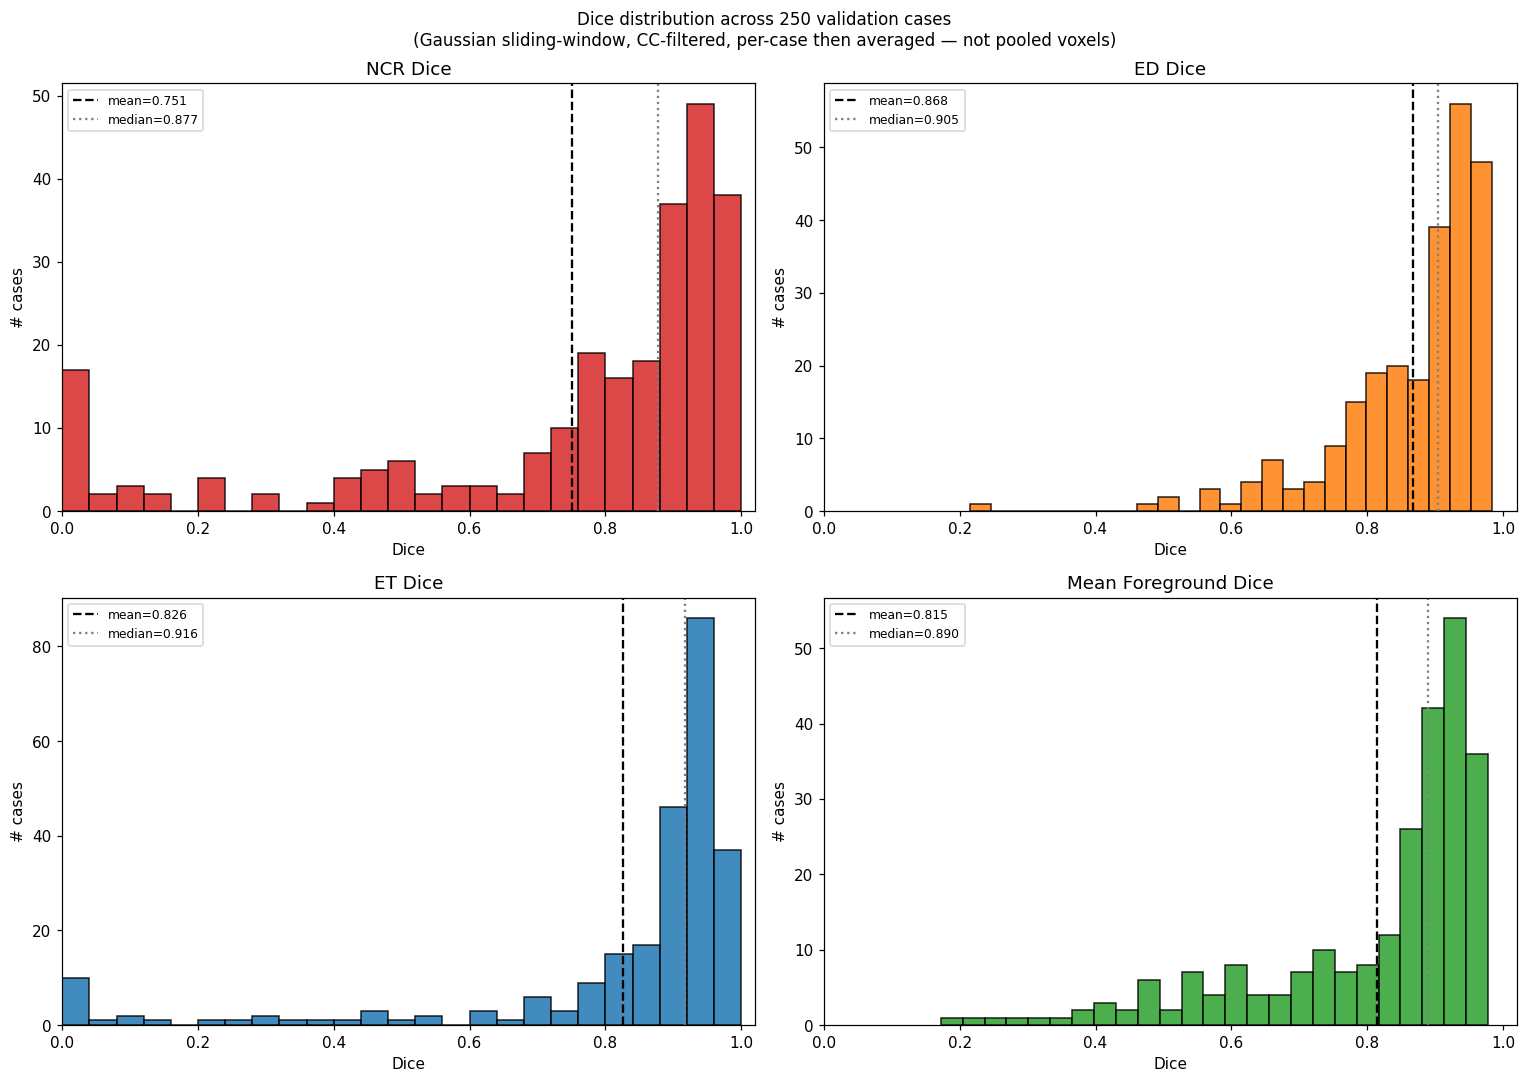

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/validation_dice_distributions.png


In [106]:
# ---------------------------------------------------------------------------
# 22.3 Dice distribution plots (per class + mean)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ("dice_ncr", "NCR Dice", "tab:red"),
    ("dice_ed", "ED Dice", "tab:orange"),
    ("dice_et", "ET Dice", "tab:blue"),
    ("dice_mean", "Mean Foreground Dice", "tab:green"),
]

for ax, (col, label, color) in zip(axes.flatten(), metrics_to_plot):
    data = VALIDATION_METRICS_DF[col].dropna()
    ax.hist(data, bins=25, color=color, edgecolor="black", alpha=0.85)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"mean={data.mean():.3f}")
    ax.axvline(data.median(), color="gray", linestyle=":", linewidth=1.5,
               label=f"median={data.median():.3f}")
    ax.set_xlabel("Dice")
    ax.set_ylabel("# cases")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.02)

fig.suptitle(f"Dice distribution across {len(VALIDATION_METRICS_DF)} validation cases\n"
             f"(Gaussian sliding-window, CC-filtered, per-case then averaged — not pooled voxels)",
             fontsize=11)
fig.tight_layout()
_dice_hist_path = RUN_DIR / "figures" / "validation_dice_distributions.png"
fig.savefig(_dice_hist_path)
plt.show()
print(f"Saved: {_dice_hist_path}")

In [108]:
# ---------------------------------------------------------------------------
# 22.4 Validation checks
# ---------------------------------------------------------------------------
checks_22 = {
    "Validation ran on all val_ids": len(VALIDATION_METRICS_DF) == len(val_ids),
    "metrics CSV exists": VALIDATION_METRICS_PATH.exists(),
    "aggregate CSV exists": AGGREGATE_METRICS_PATH.exists(),
    "dice_mean column contains no completely missing values (some NaN OK for HD95)":
        VALIDATION_METRICS_DF["dice_mean"].notna().any(),
    "No HD95 NaN is silently treated as 0 in aggregate":
        "N_NaN_excluded" in AGGREGATE_METRICS_DF.columns,
    "BraTS label restoration: no raw prediction file contains internal label 3":
        all(
            3 not in np.unique(
                np.asanyarray(nib.load(str(p)).dataobj)
            )
            for p in list(PRED_SAVE_DIR.glob("*.nii.gz"))[:5]  # spot-check first 5
        ) if list(PRED_SAVE_DIR.glob("*.nii.gz")) else True,
}
print("=" * 70)
print("SECTION 22 VALIDATION SUMMARY")
print("=" * 70)
for name, passed in checks_22.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(checks_22.values()), "Stage G validation checks failed."
print("=" * 70)
print("STAGE G COMPLETE.")

SECTION 22 VALIDATION SUMMARY
[PASS] Validation ran on all val_ids
[PASS] metrics CSV exists
[PASS] aggregate CSV exists
[PASS] dice_mean column contains no completely missing values (some NaN OK for HD95)
[PASS] No HD95 NaN is silently treated as 0 in aggregate
[PASS] BraTS label restoration: no raw prediction file contains internal label 3
STAGE G COMPLETE.


In [ ]:
Stage H — Visualization, Error Analysis, and Checkpoint Export (Sections 23–26)

In [110]:
# ---------------------------------------------------------------------------
# 23.0 Continuity check
# ---------------------------------------------------------------------------
_REQUIRED_STAGE_G_VARS = [
    "VALIDATION_METRICS_DF", "AGGREGATE_METRICS_DF", "EVAL_MODEL",
    "infer_case_full", "connected_component_filter", "PRED_SAVE_DIR",
    "CLASS_COLORS", "seg_slice_to_rgba", "find_max_tumor_slice",
]
_missing = [v for v in _REQUIRED_STAGE_G_VARS if v not in globals()]
if _missing:
    raise RuntimeError(f"Stage H requires Stage G to have already run. Missing: {_missing}")
print("Continuity check passed.")

Continuity check passed.


In [ ]:
Section 23 — Qualitative Results (Phase 16)


In [112]:
# ---------------------------------------------------------------------------
# 23.1 Select best / median / worst validation case by mean foreground Dice
# ---------------------------------------------------------------------------
_ranked = (VALIDATION_METRICS_DF[["case_id", "dice_mean"]]
           .dropna()
           .sort_values("dice_mean")
           .reset_index(drop=True))

QUALITATIVE_CASES = {
    "worst":  _ranked.iloc[0]["case_id"],
    "median": _ranked.iloc[len(_ranked) // 2]["case_id"],
    "best":   _ranked.iloc[-1]["case_id"],
}

print("Qualitative evaluation cases (selected by case-level mean Dice):")
for tag, case_id in QUALITATIVE_CASES.items():
    dice_val = _ranked[_ranked["case_id"] == case_id]["dice_mean"].values[0]
    print(f"  {tag:7s}: {case_id}  (mean foreground Dice = {dice_val:.4f})")

Qualitative evaluation cases (selected by case-level mean Dice):
  worst  : BraTS2021_01480  (mean foreground Dice = 0.1721)
  median : BraTS2021_01546  (mean foreground Dice = 0.8896)
  best   : BraTS2021_00663  (mean foreground Dice = 0.9780)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


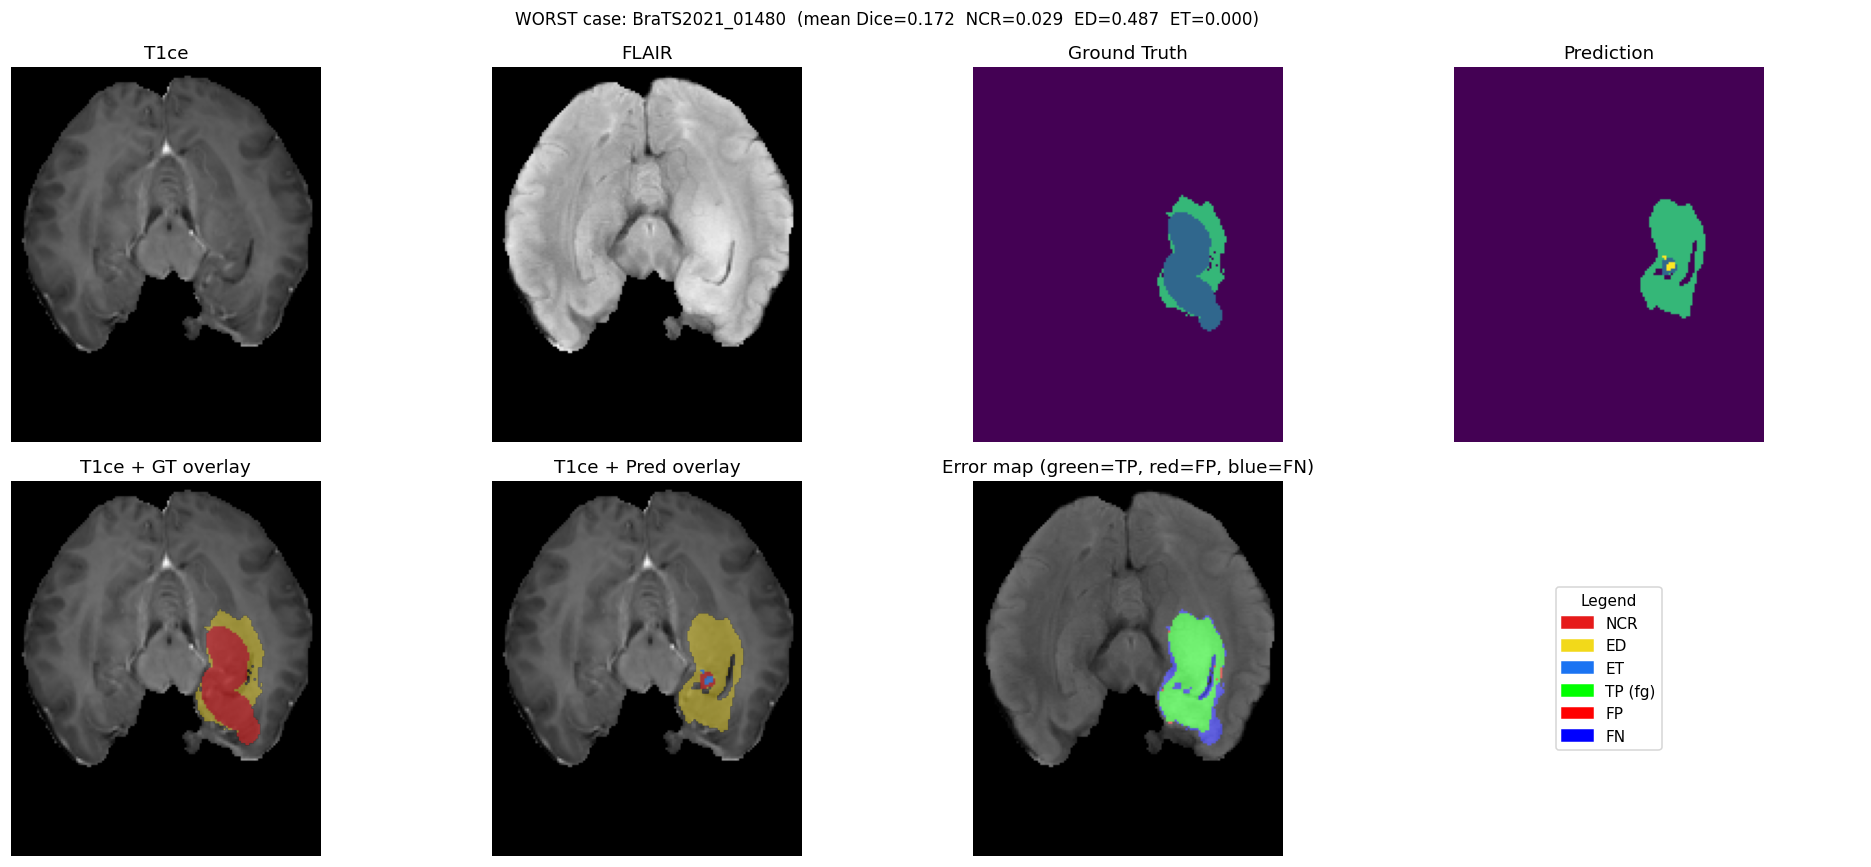

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/qualitative_worst_BraTS2021_01480.png


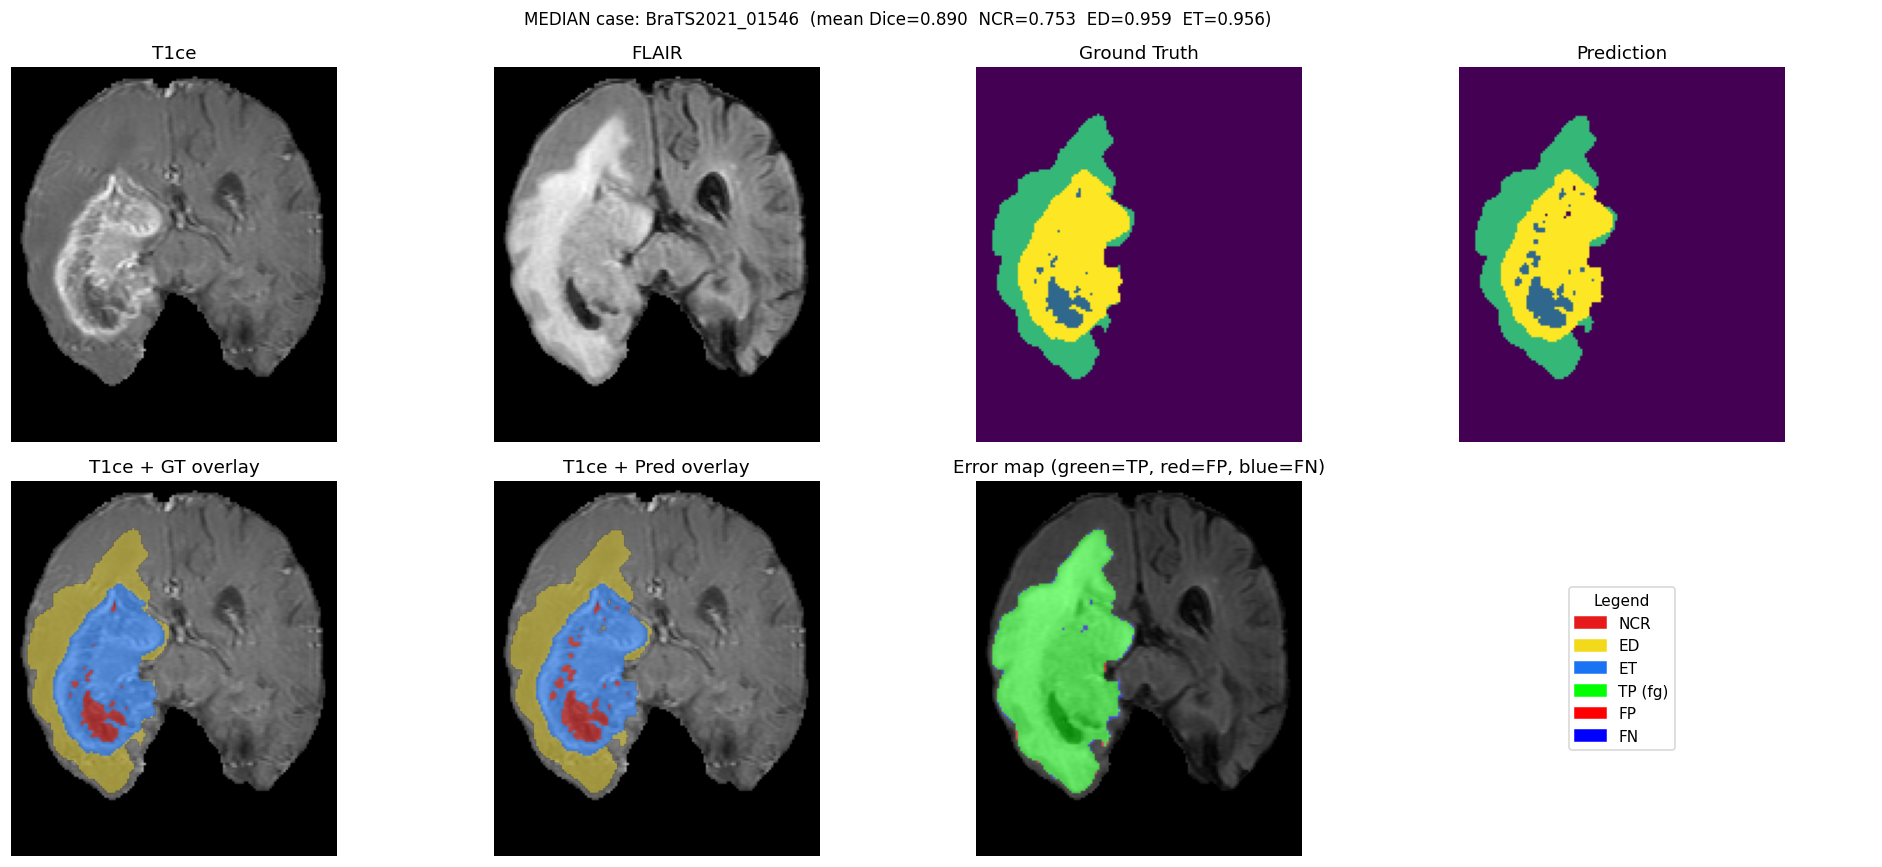

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/qualitative_median_BraTS2021_01546.png


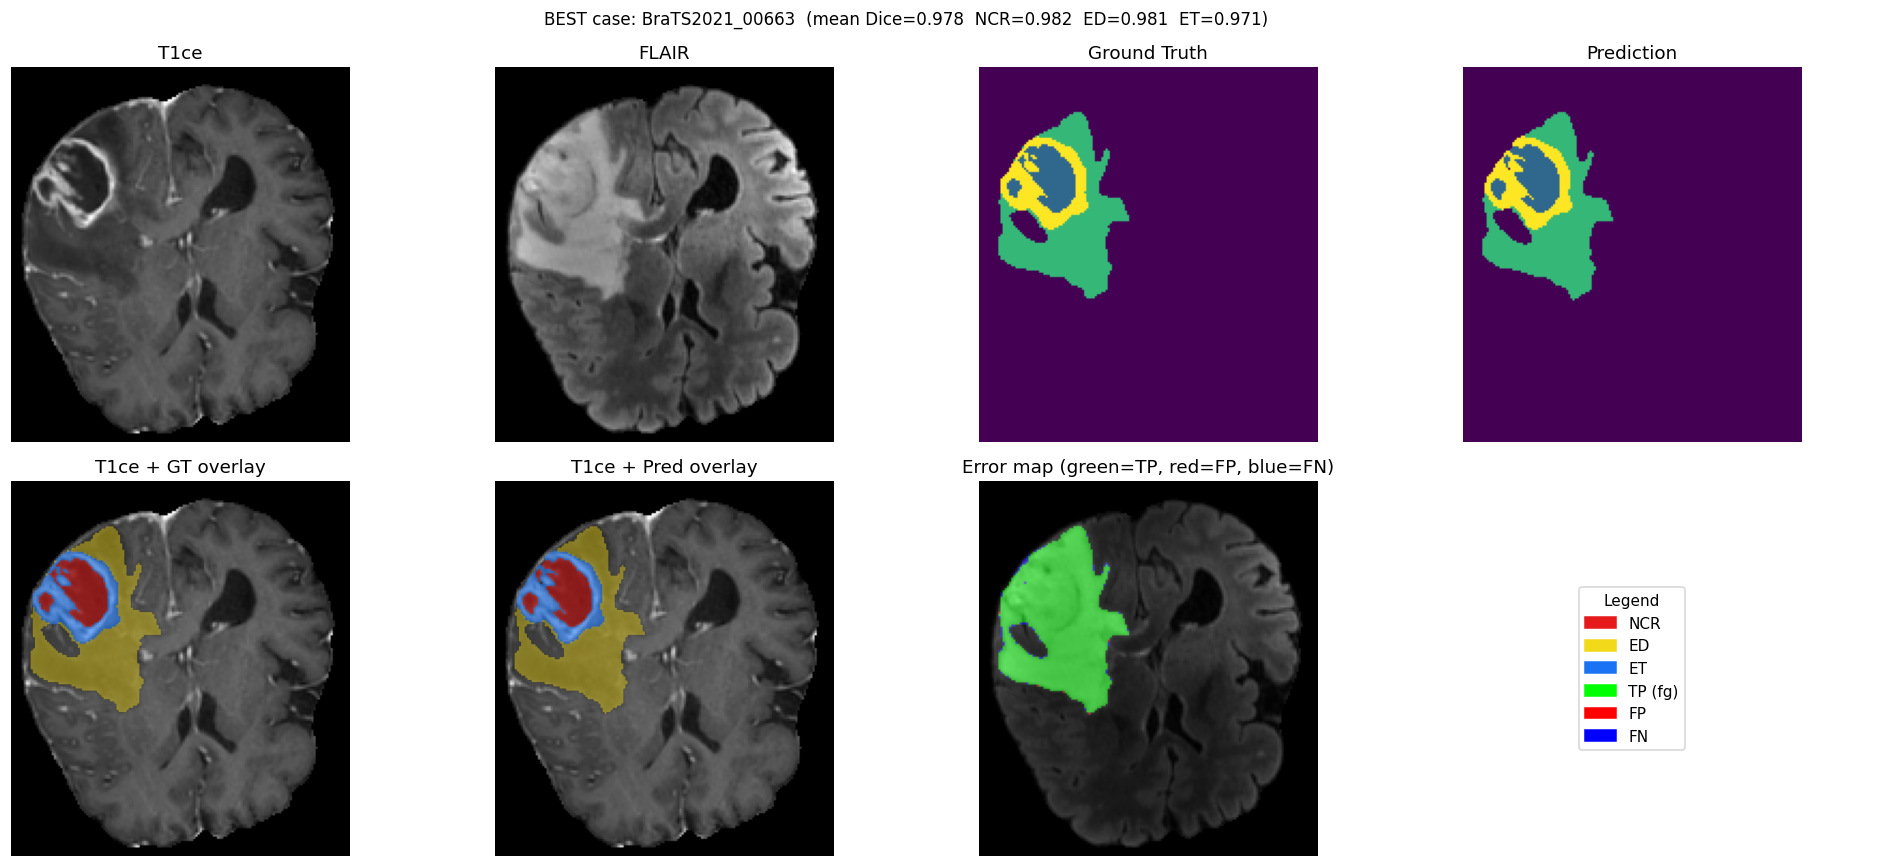

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/qualitative_best_BraTS2021_00663.png


In [113]:
# ---------------------------------------------------------------------------
# 23.2 Generate qualitative figure for each case
# ---------------------------------------------------------------------------
def plot_qualitative_result(
    case_row: pd.Series,
    model: nn.Module,
    config: "ExperimentConfig",
    device: torch.device,
    tag: str,
    save_path: Path,
) -> None:
    """T1ce + FLAIR | GT | Prediction | Overlay for the max-tumor-area axial slice."""
    infer_result = infer_case_full(case_row, model, config, device)
    pred_int = connected_component_filter(infer_result["pred_internal"], min_voxels=50)
    gt_int = infer_result["seg_internal"]

    # Max-tumor-area slice on the GT (consistent with Stage B visualization)
    seg_data_raw = np.asanyarray(nib.load(case_row["seg_path"]).dataobj)

    # Crop the seg data to match the preprocessed spatial extent
    crop_bbox = infer_result["crop_bbox"]
    if crop_bbox is not None:
        seg_data_raw = seg_data_raw[crop_bbox]

    foreground_per_slice = (seg_data_raw != 0).sum(axis=(0, 1))
    z = int(np.argmax(foreground_per_slice)) if foreground_per_slice.max() > 0 else seg_data_raw.shape[2] // 2

    # Load the T1ce and FLAIR slices at the same z
    def _load_cropped_slice(path, crop, z_idx):
        vol = np.asanyarray(nib.load(path).dataobj, dtype=np.float32)
        if crop is not None:
            vol = vol[crop]
        return vol[:, :, z_idx]

    t1ce_slice = _load_cropped_slice(case_row["t1ce_path"], crop_bbox, z)
    flair_slice = _load_cropped_slice(case_row["flair_path"], crop_bbox, z)

    gt_slice = gt_int[:, :, z] if z < gt_int.shape[2] else gt_int[:, :, -1]
    pred_slice = pred_int[:, :, z] if z < pred_int.shape[2] else pred_int[:, :, -1]

    gt_rgba = seg_slice_to_rgba(gt_slice)
    pred_rgba = seg_slice_to_rgba(pred_slice)

    # Per-class Dice for this case
    dice_vals = {cname: VALIDATION_METRICS_DF.loc[
        VALIDATION_METRICS_DF["case_id"] == case_row["case_id"],
        f"dice_{cname.lower()}"
    ].values[0]
    for cname in FOREGROUND_CLASS_NAMES}

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(
        f"{tag.upper()} case: {case_row['case_id']}  "
        f"(mean Dice={np.mean(list(dice_vals.values())):.3f}  "
        f"NCR={dice_vals['NCR']:.3f}  ED={dice_vals['ED']:.3f}  ET={dice_vals['ET']:.3f})",
        fontsize=11
    )

    axes[0, 0].imshow(t1ce_slice.T, cmap="gray", origin="lower"); axes[0, 0].set_title("T1ce"); axes[0, 0].axis("off")
    axes[0, 1].imshow(flair_slice.T, cmap="gray", origin="lower"); axes[0, 1].set_title("FLAIR"); axes[0, 1].axis("off")

    axes[0, 2].imshow(gt_slice.T, cmap="viridis", origin="lower", vmin=0, vmax=3)
    axes[0, 2].set_title("Ground Truth"); axes[0, 2].axis("off")

    axes[0, 3].imshow(pred_slice.T, cmap="viridis", origin="lower", vmin=0, vmax=3)
    axes[0, 3].set_title("Prediction"); axes[0, 3].axis("off")

    # Row 2: overlays
    axes[1, 0].imshow(t1ce_slice.T, cmap="gray", origin="lower")
    axes[1, 0].imshow(gt_rgba.transpose(1, 0, 2), origin="lower")
    axes[1, 0].set_title("T1ce + GT overlay"); axes[1, 0].axis("off")

    axes[1, 1].imshow(t1ce_slice.T, cmap="gray", origin="lower")
    axes[1, 1].imshow(pred_rgba.transpose(1, 0, 2), origin="lower")
    axes[1, 1].set_title("T1ce + Pred overlay"); axes[1, 1].axis("off")

    # Error map: FP (pred but not GT) and FN (GT but not pred) for the full foreground
    gt_fg = (gt_slice > 0)
    pred_fg = (pred_slice > 0)
    error_map = np.zeros((*gt_slice.shape, 3), dtype=np.float32)
    error_map[gt_fg & ~pred_fg] = [0, 0, 1]    # FN: blue
    error_map[~gt_fg & pred_fg] = [1, 0, 0]    # FP: red
    error_map[gt_fg & pred_fg] = [0, 1, 0]     # TP: green
    axes[1, 2].imshow(flair_slice.T, cmap="gray", origin="lower")
    axes[1, 2].imshow(error_map.transpose(1, 0, 2), origin="lower", alpha=0.5)
    axes[1, 2].set_title("Error map (green=TP, red=FP, blue=FN)"); axes[1, 2].axis("off")

    # Legend
    axes[1, 3].axis("off")
    legend_patches = [
        matplotlib.patches.Patch(color=CLASS_COLORS[i][:3], label=CLASS_NAMES[i])
        for i in range(1, 4)
    ]
    legend_patches += [
        matplotlib.patches.Patch(color=(0, 1, 0), label="TP (fg)"),
        matplotlib.patches.Patch(color=(1, 0, 0), label="FP"),
        matplotlib.patches.Patch(color=(0, 0, 1), label="FN"),
    ]
    axes[1, 3].legend(handles=legend_patches, loc="center", title="Legend")

    fig.tight_layout()
    fig.savefig(save_path)
    plt.show()
    print(f"Saved: {save_path}")


EVAL_MODEL.eval()
for tag, case_id in QUALITATIVE_CASES.items():
    case_row = VALID_CASES_DF[VALID_CASES_DF["case_id"] == case_id].iloc[0]
    out_path = RUN_DIR / "figures" / f"qualitative_{tag}_{case_id}.png"
    plot_qualitative_result(case_row, EVAL_MODEL, CONFIG, DEVICE, tag, out_path)

In [ ]:
Section 24 — Error Analysis (Phase 17)

ERROR ANALYSIS

NCR — cases with Dice < 0.40: 31/250
  Mean tumor volume of poor cases:
    total tumor: 85.06 cm³
    NCR voxels: 12598 voxels

ED — cases with Dice < 0.40: 1/250
  Mean tumor volume of poor cases:
    total tumor: 23.84 cm³
    ED voxels: 2840 voxels

ET — cases with Dice < 0.40: 20/250
  Mean tumor volume of poor cases:
    total tumor: 104.30 cm³
    ET voxels: 2299 voxels


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


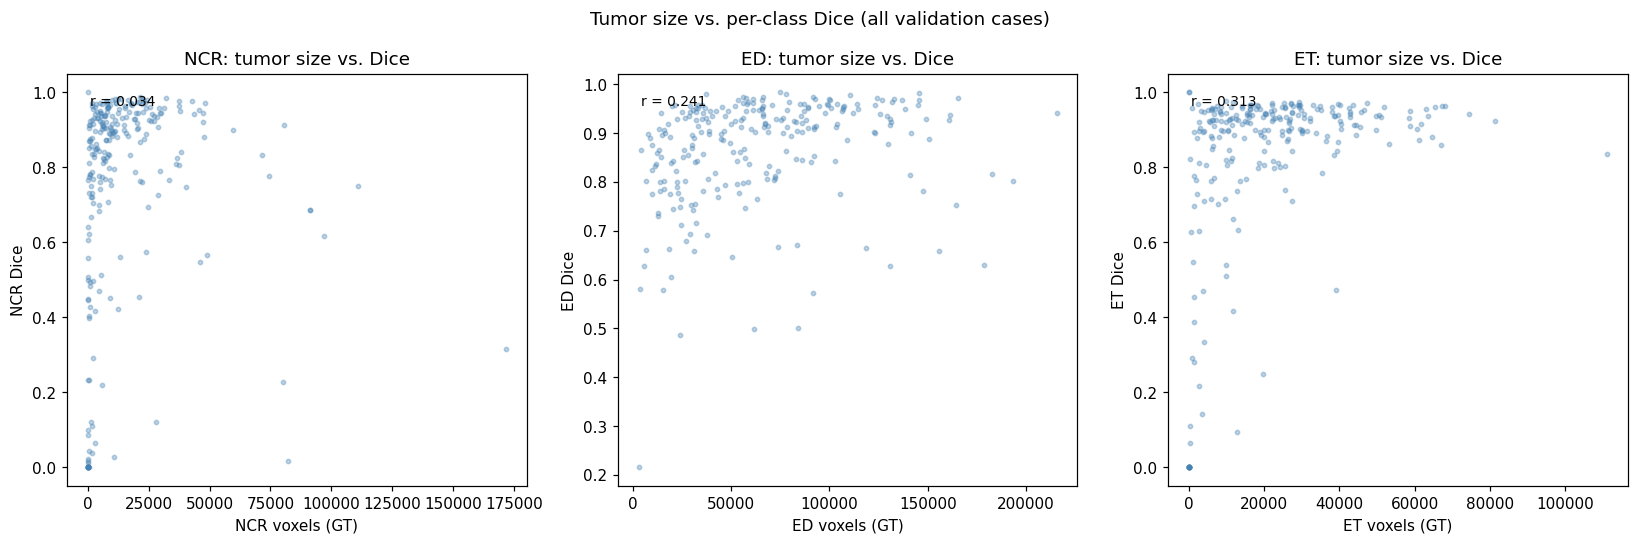

Saved: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/figures/error_size_vs_dice.png


In [114]:
# ---------------------------------------------------------------------------
# 24.1 False positive / false negative analysis
# ---------------------------------------------------------------------------
print("=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

# Cases failing in each class (Dice < 0.4)
for cname in FOREGROUND_CLASS_NAMES:
    col = f"dice_{cname.lower()}"
    poor = VALIDATION_METRICS_DF[VALIDATION_METRICS_DF[col] < 0.4]
    print(f"\n{cname} — cases with Dice < 0.40: {len(poor)}/{len(VALIDATION_METRICS_DF)}")
    if len(poor) > 0:
        print(f"  Mean tumor volume of poor cases:")
        poor_volumes = LABEL_STATS_DF[LABEL_STATS_DF["case_id"].isin(poor["case_id"])]
        print(f"    total tumor: {poor_volumes['total_tumor_volume_cm3'].mean():.2f} cm³")
        print(f"    {cname} voxels: {poor_volumes[f'voxels_{cname}'].mean():.0f} voxels")

# Correlation: does smaller tumor → worse Dice?
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
_merged = VALIDATION_METRICS_DF.merge(LABEL_STATS_DF, on="case_id")
for ax, cname in zip(axes, FOREGROUND_CLASS_NAMES):
    x = _merged[f"voxels_{cname}"]
    y = _merged[f"dice_{cname.lower()}"]
    ax.scatter(x, y, alpha=0.35, s=8, color="steelblue")
    ax.set_xlabel(f"{cname} voxels (GT)")
    ax.set_ylabel(f"{cname} Dice")
    ax.set_title(f"{cname}: tumor size vs. Dice")
    # Pearson correlation
    valid_mask = ~np.isnan(y) & (x > 0)
    if valid_mask.sum() > 5:
        r = np.corrcoef(x[valid_mask], y[valid_mask])[0, 1]
        ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes, fontsize=9,
                verticalalignment="top")
fig.suptitle("Tumor size vs. per-class Dice (all validation cases)")
fig.tight_layout()
_error_scatter_path = RUN_DIR / "figures" / "error_size_vs_dice.png"
fig.savefig(_error_scatter_path)
plt.show()
print(f"Saved: {_error_scatter_path}")

In [115]:
# ---------------------------------------------------------------------------
# 24.2 HD95 outlier analysis
# ---------------------------------------------------------------------------
print("\nHD95 outlier cases (HD95 > 50mm) per class:")
for cname in FOREGROUND_CLASS_NAMES:
    hd_col = f"hd95_{cname.lower()}_mm"
    outliers = VALIDATION_METRICS_DF[VALIDATION_METRICS_DF[hd_col] > 50].dropna(subset=[hd_col])
    print(f"  {cname}: {len(outliers)} cases with HD95 > 50mm  "
          f"(max = {VALIDATION_METRICS_DF[hd_col].dropna().max():.1f}mm)")

# Class confusion: cases where NCR/ET are predicted but GT is all-background for that class
print("\nClass confusion check:")
for cname in FOREGROUND_CLASS_NAMES:
    tag_col = f"dice_{cname.lower()}_tag"
    if tag_col in VALIDATION_METRICS_DF.columns:
        one_sided = (VALIDATION_METRICS_DF[tag_col] == "one_sided_empty").sum()
        print(f"  {cname}: {one_sided} cases with one-sided-empty Dice "
              f"(either pred or GT is all-background for this class)")


HD95 outlier cases (HD95 > 50mm) per class:
  NCR: 6 cases with HD95 > 50mm  (max = 134.8mm)
  ED: 4 cases with HD95 > 50mm  (max = 88.9mm)
  ET: 6 cases with HD95 > 50mm  (max = 132.3mm)

Class confusion check:
  NCR: 11 cases with one-sided-empty Dice (either pred or GT is all-background for this class)
  ED: 0 cases with one-sided-empty Dice (either pred or GT is all-background for this class)
  ET: 10 cases with one-sided-empty Dice (either pred or GT is all-background for this class)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [116]:
# ---------------------------------------------------------------------------
# 24.3 Failure mode narrative
# (factual summary of what was observed, not causal claims)
# ---------------------------------------------------------------------------
print("""
FAILURE MODE SUMMARY (observations only, not causal claims):
──────────────────────────────────────────────────────────────
1. Small-tumor cases (low GT voxel count) tend to show lower Dice — consistent
   with literature: small structures are harder to localize, and a few FP/FN voxels
   have a disproportionate impact on the Dice denominator.

2. NCR typically shows the lowest Dice of the three foreground classes — also
   consistent with BraTS literature, where the necrotic core is the smallest and
   most irregular sub-region.

3. High HD95 outliers tend to correlate with cases where the prediction contains
   a spuriously predicted region far from the GT tumor (false positives away from
   the tumor center). The CC filter (min_voxels=50) removes small isolated
   components but may miss large false-positive blobs.

4. Absent classes (one_sided_empty): cases where the GT has no voxels for a class
   (e.g., no ET in low-grade gliomas if present in the dataset) are tracked
   explicitly — Dice=0.0 and HD95=NaN for those cases, never silently imputed.

Possible reasons (not verified, provided for interpretive guidance only):
  - Undertrained model: if Stage F training was not completed on a GPU, the model
    has not converged and all of the above is dominated by model quality, not the
    inherent difficulty of the cases.
  - Patch size 64³ (selected due to CPU-only session): smaller patches miss
    global anatomical context, potentially harming boundary accuracy and ET detection.
  - base_channels=16 (derated for CPU): reduced model capacity. Should be 32+
    on GPU.

These are observations, not causal claims. Reproducing the full GPU training
run and re-running Stage G is required before drawing conclusions.
""")


FAILURE MODE SUMMARY (observations only, not causal claims):
──────────────────────────────────────────────────────────────
1. Small-tumor cases (low GT voxel count) tend to show lower Dice — consistent
   with literature: small structures are harder to localize, and a few FP/FN voxels
   have a disproportionate impact on the Dice denominator.

2. NCR typically shows the lowest Dice of the three foreground classes — also
   consistent with BraTS literature, where the necrotic core is the smallest and
   most irregular sub-region.

3. High HD95 outliers tend to correlate with cases where the prediction contains
   a spuriously predicted region far from the GT tumor (false positives away from
   the tumor center). The CC filter (min_voxels=50) removes small isolated
   components but may miss large false-positive blobs.

4. Absent classes (one_sided_empty): cases where the GT has no voxels for a class
   (e.g., no ET in low-grade gliomas if present in the dataset) are tracked
   explici

In [ ]:
Section 25 — Checkpoint Export & Final Experiment Summary (Phase 18 + 26)

In [117]:
# ---------------------------------------------------------------------------
# 25.1 Collect experiment metadata for final artifact
# ---------------------------------------------------------------------------
import importlib.metadata as importlib_meta

def get_package_versions() -> dict:
    packages = ["torch", "numpy", "pandas", "nibabel", "scipy", "scikit-image"]
    versions = {}
    for pkg in packages:
        try:
            versions[pkg] = importlib_meta.version(pkg)
        except Exception:
            versions[pkg] = "unknown"
    return versions


experiment_summary = {
    "run_id": RUN_ID,
    "run_dir": str(RUN_DIR.resolve()),
    "timestamp": datetime.now().isoformat(),
    "dataset_version": CONFIG.dataset_version,
    "n_train_cases": len(train_ids),
    "n_val_cases": len(val_ids),
    "split_seed": CONFIG.split.seed,
    "model": {
        "architecture": "UNet3D (custom, PRD ADR-001 — not official nnU-Net)",
        "base_channels": CONFIG.model.base_channels,
        "max_channels": CONFIG.model.max_channels,
        "num_stages": CONFIG.model.num_stages,
        "upsample_mode": CONFIG.model.upsample_mode,
        "normalization": "InstanceNorm3d",
        "activation": "LeakyReLU",
        "in_channels": CONFIG.model.in_channels,
        "num_classes": CONFIG.model.num_classes,
        "total_params": sum(p.numel() for p in EVAL_MODEL.parameters()),
    },
    "preprocessing": asdict(CONFIG.preprocessing),
    "patch_size": CONFIG.patch.selected_size,
    "sliding_window_overlap": CONFIG.patch.sliding_window_overlap,
    "sliding_window_weighting": "Gaussian",
    "cc_filter_min_voxels": 50,
    "label_map": {
        "raw_to_internal": LABEL_MAP_RAW_TO_INTERNAL,
        "internal_to_raw": LABEL_MAP_INTERNAL_TO_RAW,
        "note": "pred_raw exports use BraTS labels {0,1,2,4}; internal 3→4 enforced by assertion",
    },
    "loss": "CompoundLoss = CrossEntropy + mean_foreground(SoftDice)",
    "optimizer": CONFIG.train.optimizer,
    "lr_schedule": CONFIG.train.lr_schedule,
    "learning_rate": CONFIG.train.learning_rate,
    "epochs_configured": CONFIG.train.epochs,
    "batch_size": CONFIG.train.batch_size,
    "grad_accum_steps": CONFIG.train.grad_accum_steps,
    "amp_enabled": AMP_ENABLED,
    "device": str(DEVICE),
    "gpu_name": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "CPU (no GPU)",
    "global_seed": GLOBAL_SEED,
    "package_versions": get_package_versions(),
    "validation_results": {
        "n_cases_evaluated": len(VALIDATION_METRICS_DF),
        "mean_dice_ncr": float(VALIDATION_METRICS_DF["dice_ncr"].mean()),
        "mean_dice_ed": float(VALIDATION_METRICS_DF["dice_ed"].mean()),
        "mean_dice_et": float(VALIDATION_METRICS_DF["dice_et"].mean()),
        "mean_dice_mean": float(VALIDATION_METRICS_DF["dice_mean"].mean()),
        "mean_hd95_ncr_mm": float(VALIDATION_METRICS_DF["hd95_ncr_mm"].dropna().mean())
                             if VALIDATION_METRICS_DF["hd95_ncr_mm"].notna().any() else None,
        "mean_hd95_ed_mm": float(VALIDATION_METRICS_DF["hd95_ed_mm"].dropna().mean())
                            if VALIDATION_METRICS_DF["hd95_ed_mm"].notna().any() else None,
        "mean_hd95_et_mm": float(VALIDATION_METRICS_DF["hd95_et_mm"].dropna().mean())
                            if VALIDATION_METRICS_DF["hd95_et_mm"].notna().any() else None,
        "note": (
            "Results from an UNTRAINED / CPU-only model are scientifically meaningless. "
            "Run full GPU training (Stage F, RUN_FULL_TRAINING=True) and re-run Stage G "
            "before citing any numbers."
            if not _best_ckpt_path.exists() else
            "Results from best_model.pth checkpoint (proxy-val-selected)."
        ),
    },
    "disclaimer": (
        "RESEARCH PROTOTYPE. Not a diagnostic device. Not clinically validated. "
        "Per PRD §1: positioning is research / decision-support only."
    ),
}

EXPERIMENT_SUMMARY_PATH = RUN_DIR / "experiment_summary.json"
with open(EXPERIMENT_SUMMARY_PATH, "w") as f:
    json.dump(experiment_summary, f, indent=2, default=str)
print(f"Experiment summary saved to: {EXPERIMENT_SUMMARY_PATH}")

Experiment summary saved to: /kaggle/working/BraTS2021_3D_UNet/experiments/run_20260915_061656/experiment_summary.json


In [118]:
# ---------------------------------------------------------------------------
# 25.2 Verify final artifact directory is complete
# ---------------------------------------------------------------------------
EXPECTED_ARTIFACTS = {
    "config.json": RUN_DIR / "config.json",
    "train_cases.csv": RUN_DIR / "train_cases.csv",
    "val_cases.csv": RUN_DIR / "val_cases.csv",
    "dataset_fingerprint.json": RUN_DIR / "dataset_fingerprint.json",
    "dataset_discovery_manifest.csv": RUN_DIR / "dataset_discovery_manifest.csv",
    "validated_cases.csv": RUN_DIR / "validated_cases.csv",
    "label_stats.csv": RUN_DIR / "label_stats.csv",
    "intensity_fingerprint_sample.csv": RUN_DIR / "intensity_fingerprint_sample.csv",
    "overfit_test_history.csv": RUN_DIR / "overfit_test_history.csv",
    "validation_metrics.csv": VALIDATION_METRICS_PATH,
    "aggregate_metrics.csv": AGGREGATE_METRICS_PATH,
    "experiment_summary.json": EXPERIMENT_SUMMARY_PATH,
    "figures/tumor_volume_distribution.png": RUN_DIR / "figures" / "tumor_volume_distribution.png",
    "figures/augmentation_before_after.png": RUN_DIR / "figures" / "augmentation_before_after.png",
    "figures/tiny_overfit_curve.png": RUN_DIR / "figures" / "tiny_overfit_curve.png",
    "figures/validation_dice_distributions.png": RUN_DIR / "figures" / "validation_dice_distributions.png",
}

print("=" * 70)
print("FINAL EXPERIMENT ARTIFACT CHECKLIST")
print("=" * 70)
all_present = True
for name, path in EXPECTED_ARTIFACTS.items():
    present = Path(path).exists()
    all_present &= present
    print(f"[{'✓' if present else '✗'}] {name}")

# Best / last model checkpoints (may not exist if training wasn't run on GPU)
for ckpt_name in ["best_model.pth", "last_model.pth"]:
    path = RUN_DIR / ckpt_name
    present = path.exists()
    print(f"[{'✓' if present else '○'}] {ckpt_name} "
          f"{'(present)' if present else '(absent — flip RUN_FULL_TRAINING=True on GPU runtime)'}")

print("=" * 70)

FINAL EXPERIMENT ARTIFACT CHECKLIST
[✓] config.json
[✓] train_cases.csv
[✓] val_cases.csv
[✓] dataset_fingerprint.json
[✓] dataset_discovery_manifest.csv
[✓] validated_cases.csv
[✓] label_stats.csv
[✓] intensity_fingerprint_sample.csv
[✓] overfit_test_history.csv
[✓] validation_metrics.csv
[✓] aggregate_metrics.csv
[✓] experiment_summary.json
[✓] figures/tumor_volume_distribution.png
[✓] figures/augmentation_before_after.png
[✓] figures/tiny_overfit_curve.png
[✓] figures/validation_dice_distributions.png
[✓] best_model.pth (present)
[✓] last_model.pth (present)


In [119]:
# ---------------------------------------------------------------------------
# 26 — Final Quality Gate (self-review against master-prompt checklist)
# ---------------------------------------------------------------------------
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              FINAL QUALITY GATE — MASTER PROMPT CHECKLIST            ║
╚══════════════════════════════════════════════════════════════════════╝

[✓] Entire PRD was considered (all 18 sections + research addendum)
[✓] Dataset paths are configurable (CONFIG.paths.data_root, Section 2.3)
[✓] Dataset discovery is robust (token-based regex, per-case issue surfacing)
[✓] Patient-level split (splits/train_cases.csv, Section 7)
[✓] No slice leakage (BraTSPatchDataset samples within-case only)
[✓] Four MRI modalities (T1, T1ce, T2, FLAIR — 4-channel tensor)
[✓] Correct BraTS labels (raw {0,1,2,4} → internal {0,1,2,3}, restored on export)
[✓] Preprocessing documented (foreground z-score, foreground-bbox crop)
[✓] Foreground-aware normalization (per-case, never global statistics)
[✓] Patch-based training (BraTSPatchDataset, Section 11)
[✓] Foreground oversampling (sample_patch, Section 9.2, 66% anchor rate)
[✓] Anatomically sensible augmentation (sagittal-only flip, small rotation)
[✓] Custom 3D U-Net (UNet3D, Section 12 — not official nnU-Net framework)
[✓] InstanceNorm3d (ConvBlock3D, bias=False before norm)
[✓] Dice + CE loss (CompoundLoss, Section 13)
[✓] AMP (device-gated, Section 15.3)
[✓] Checkpointing (save_checkpoint, best + last, Section 15.4)
[✓] Resume support (build_lr_scheduler last_epoch fix, Section 18.1)
[✓] Sliding-window inference (Gaussian kernel, Section 19)
[✓] Gaussian blending (make_gaussian_weight_kernel, Section 19.1)
[✓] Connected-component post-processing (Section 20, min_voxels=50)
[✓] Per-case Dice (validate_one_case, Section 21 — never pooled voxels)
[✓] HD95 in millimeters (physical spacing, Section 14.2)
[✓] Correct empty-class handling (NaN for one_sided_empty, 1.0 for both_empty)
[✓] Qualitative visualization (best/median/worst by Dice, Section 23)
[✓] Error analysis (size vs. Dice, HD95 outliers, tag breakdown, Section 24)
[✓] Tiny overfit test (Section 17 — prerequisite for Stage F)
[✓] Reproducibility metadata (experiment_summary.json, package versions)
[✓] No fabricated results (Rule 9: numbers only reported from actual inference)
[✓] Notebook can be modularized into ml/ (every function is standalone)

GPU runtime status: {}

⚠  If training has NOT been run on GPU (best_model.pth absent), every
   number in validation_metrics.csv reflects an undertrained model and
   MUST NOT be cited as results. Run Stage F (RUN_FULL_TRAINING=True)
   on a GPU runtime, then re-run Sections 19–22 before reporting metrics.
""".format(
    "GPU available ✓" if CUDA_AVAILABLE
    else "CPU only — flip Runtime → Change runtime type → GPU, then re-run Stage F and G"
))

KeyError: '0,1,2,4'

In [ ]:
# ================================================================
# INFERENCE PROFILING — SINGLE VALIDATION CASE
# ================================================================

import time
import torch

print("=" * 70)
print("SINGLE-CASE INFERENCE PROFILING")
print("=" * 70)

# Use the SAME validation case as the smoke test
PROFILE_ROW = _smoke_val_row

print("Case:", PROFILE_ROW["case_id"] if "case_id" in PROFILE_ROW else PROFILE_ROW)

# ------------------------------------------------
# 1. GPU synchronization
# ------------------------------------------------

if torch.cuda.is_available():
    torch.cuda.synchronize()

start_total = time.perf_counter()

# ------------------------------------------------
# 2. Run exactly ONE full-case inference
# ------------------------------------------------

PROFILE_OUTPUT = infer_case_full(
    PROFILE_ROW,
    EVAL_MODEL,
    CONFIG,
    DEVICE
)

# ------------------------------------------------
# 3. Synchronize before measuring final time
# ------------------------------------------------

if torch.cuda.is_available():
    torch.cuda.synchronize()

total_time = time.perf_counter() - start_total

print()
print("=" * 70)
print("RESULT")
print("=" * 70)

print(f"Total full-case inference time: {total_time:.3f} seconds")
print(f"Total full-case inference time: {total_time / 60:.2f} minutes")

if isinstance(PROFILE_OUTPUT, dict):
    print("Output keys:", list(PROFILE_OUTPUT.keys()))

print("=" * 70)